In [1]:
import time
from sklearn.neighbors import NearestNeighbors
import tools
from scipy import stats
from scipy.optimize import differential_evolution
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lightgbm as lgbm

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

%load_ext autoreload
%autoreload 2

from tools import utils as u, config as cfg, plotting as up, preprocessing as pp

In [2]:
# CONSTANTS

DATA_BASE_PATH = f"../../Data/"
DATA_TESTING_PATH = f"{DATA_BASE_PATH}/PHM2025_test_data/"
DATA_TRAINING_PATH = f"{DATA_BASE_PATH}/PHM2025_training_data/"
DATA_VALIDATION_PATH = f"{DATA_BASE_PATH}/PHM2025_validation_data/"
DATA_TRAINING_DATA = f"{DATA_TESTING_PATH}/training_data.csv"
PLOT_PATH = f"./img/"

OPERATING_VARS = [
    "Sensed_Altitude",
    "Sensed_Mach",
    "Sensed_Pamb",
    "Sensed_TAT",
    "Sensed_VAFN",
    "Sensed_VBV",
    "Sensed_Fan_Speed",
    "Sensed_Pt2",
]

SENSORS = tools.types.enums.SENSORS

# considera solo le variabili presenti anche in test e val
DEGRAD_VARS = [
    s
    for s in SENSORS
    if s not in OPERATING_VARS and s != "Sensed_P25" and s != "Sensed_T5"
]
# scommentare se si vuole considerare anche i sensori non in test o valiation
# DEGRAD_VARS = [s for s in u.SENSORS if s not in operating_vars]
ALL_VARS = OPERATING_VARS + DEGRAD_VARS


def DATA_TEST_DATA(num):
    return f"{DATA_TESTING_PATH}/test_{num}.csv"


def DATA_VALIDATION_DATA(num):
    return f"{DATA_TESTING_PATH}/val_{num}.csv"

In [3]:
# FUNZIONI


def train_models(
    df, operating_vars, degradation_vars
) -> dict[int, dict[str, LinearRegression]]:
    X_train = df[operating_vars]
    Y_train = df[degradation_vars]
    models = {}
    for i in range(0, 8):
        X_temp = pd.DataFrame(np.roll(X_train, i, axis=1))
        models[i] = {}
        models[i]["model"] = train_model(X_temp, Y_train)
    return models


def train_model(X_train, Y_train):
    model = LinearRegression()
    model.fit(X_train, Y_train)
    return model


# Health Index


def s_pred(s_o, model):
    return model.predict(s_o)


def residual(s_d, s_o, model):
    return s_d - s_pred(s_o, model)


def HI(T3_res, T45_res, alpha):
    return -alpha * T3_res - T45_res


def minmax(df, column):
    col_min = df[column].min()
    col_max = df[column].max()
    return (df[column] - col_min) / (col_max - col_min)


def minmax_all(df):
    newdf = pd.DataFrame()
    for column in df.columns:
        col_min = df[column].min()
        col_max = df[column].max()
        newdf[column] = (df[column] - col_min) / (col_max - col_min)
    return newdf


def median_norm(df):
    for i in range(0, 7):
        m = df.iloc[:, i].median()
        df.iloc[:, i] -= m
    return df


def objective(alpha, T3, T45, RUL):
    hi = -alpha * T3 - T45
    RUL = RUL.dropna()
    hi = hi.dropna()
    corr = stats.pearsonr(RUL, hi)
    # return np.sqrt(np.mean((hi - RUL)**2)) + 1
    return -corr[0]


def objective_beta(params, T3, T45, RUL):
    alpha, beta = params
    hi = -alpha * T3 - beta * T45
    RUL = RUL.dropna()
    hi = hi.dropna()
    corr = stats.pearsonr(RUL, hi)
    # return np.sqrt(np.mean((hi - RUL)**2)) + 1
    return -corr[0]


def HIE(params, vars):
    # return np.sum([-params[i]*vars.iloc[:,i] for i in range(0, 8)])
    return vars.dot(-np.array(params))


# TWE


def wind(y_p, y, a):
    diff = y - y_p
    num = np.where(diff >= 0, 2.0, 1.0)
    if isinstance(y_p, pd.DataFrame) or isinstance(y_p, pd.Series):
        y_p = y_p.values
    return num / (1 + a * y_p)


def time_weighted_error(y_true, y_pred, alpha=0.02, beta=1):
    """Returns the weighted squared error for an array of predictions."""

    error = y_pred - y_true

    weight = np.where(error >= 0, 2 / (1 + alpha * y_true), 1 / (1 + alpha * y_true))
    return weight * (error**2) * beta


def TWE(y_p, y, a=0.02, b=1):
    # if isinstance(y_p, pd.DataFrame): y_p = y_p.values
    # weight = wind(y_p, y, a)
    # squared_error = (y - y_p) ** 2
    # return weight * squared_error * b
    return time_weighted_error(y_p, y, a, b)


# TARGET FUNCTIONS


def normalize(col):
    col_min, col_max = col.min(), col.max()
    col = (col - col_min) / (col_max - col_min)
    col = col.to_frame()
    return col


def get_slope(y):
    """Calcola la pendenza della retta di regressione per una finestra y"""
    x = np.arange(len(y))
    # Polyfit di grado 1 restituisce [pendenza, intercetta]
    slope = np.polyfit(x, y, 1)[0]
    return slope

# CONFIGURAZIONE

## Caricamento dati

In [169]:
# TRAINING
df = u.load_training()
df = pp.remove_outliers(df, SENSORS)
df = pp.missingfill(df).dropna()

# VALIDATION
no_concat = True
dfv = u.load_validation(range(0, 48), no_concat=no_concat)
if no_concat:
    for i, f in enumerate(dfv):
        dfv[i] = pp.remove_outliers(f, SENSORS)
        dfv[i] = pp.missingfill(f, align_cols=["Snapshot", "Cycles"]).dropna()
else:
    dfv = pp.remove_outliers(dfv, SENSORS)
    dfv = pp.missingfill(dfv, align_cols=["Snapshot", "Cycles"]).dropna()

# TESTING
no_concat = True
dft = u.load_testing(range(0, 52), no_concat=no_concat)
if no_concat:
    for i, f in enumerate(dft):
        dft[i] = pp.remove_outliers(f, SENSORS)
        dft[i] = pp.missingfill(f, align_cols=["Snapshot", "Cycles"]).dropna()
else:
    dft = pp.remove_outliers(dft, SENSORS)
    dft = pp.missingfill(dft, align_cols=["Snapshot", "Cycles"]).dropna()

Esecuzione missingfill su 16 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...
Esecuzione missingfill su 14 sensori...


# Regressione Lineare 1 - modello andamento nominale

In [170]:

# Quale motore nel training set verrà utilizzato come
# validation (si usa tecnica Leave-One-Out)
TESTING_ESN = 102

# Si vuole comunque utilizzare questo motore training?
INCLUDE_TEST = True

# REGRESSORE LINEARE ANDAMENTO NOMINALE
# indica quanti cicli devono essere considerati healthy nel training
cycles_healthy = 7
# se utilizzare il metodo di data augmentation oppure no
augmented_data = False
# se si, quanti dati aggiungere per ogni motore
augmented_count = 100
# se utilizzare SMOTE oppure no
SMOTE = False

# si vuole utilizzare la tecnica Ensamble?
# questa tecnica effettuerà il training per ogni motore
# e poi quando si utilizzarà il regressore verà fatta
# una media dei valori di output di ogni regressore
ENSAMBLE = True

# se ENSAMBLE è attivo, questo permette di far utilizzare
# il regressore dedicato al motore, se esiste, altrimenti
# esegue ensamble
SEPARATE_MODELS = True


# Preparazione dati training
if INCLUDE_TEST:
    train_data = df.copy()
else:
    train_data = df[df["ESN"] != TESTING_ESN].copy()

test_data = df[df["ESN"] == TESTING_ESN].copy()

if cycles_healthy > 0:
    train_data = (
        train_data.groupby("ESN").head(cycles_healthy * 8).reset_index(drop=True).copy()
    )
else:
    train_data = train_data.sort_values(["ESN", "Cycles_Since_New", "Snapshot"])

if SMOTE:
    newdf = []
    for esn in train_data["ESN"].unique():
        cur = train_data[train_data["ESN"] == esn]
        nbrs = NearestNeighbors(n_neighbors=min(5, len(cur))).fit(cur[ALL_VARS])
        dist, idx = nbrs.kneighbors(cur[ALL_VARS])
        for i in range(augmented_count):
            neighbor_offsets = np.random.randint(1, idx.shape[1], size=len(cur))
            neighbor_indices = idx[np.arange(len(cur)), neighbor_offsets]
            # SMOTE
            diff = (
                train_data.iloc[neighbor_indices][ALL_VARS].values
                - cur[ALL_VARS].values
            )
            new_vals = cur[ALL_VARS].values + diff * np.random.rand(len(cur), 1)

            aug_df = cur.copy()
            aug_df[ALL_VARS] = new_vals
            aug_df["ESN"] = f"aug_{i}_{esn}"

            newdf.append(aug_df)
    print("total data", len(newdf))

    train_data = pd.concat([train_data] + newdf, ignore_index=True)
    del newdf, aug_df, nbrs, idx, diff, new_vals

if ENSAMBLE:
    # con ESNAMBLE creiamo un modello per ogni ESN
    # e poi, con la funziona residual, otterremo la media
    # di tutti i valori predetti
    models = {}
    for esn in train_data["ESN"].unique():
        start = time.time()
        print(f"esn {esn}: ", end="")
        mask = train_data["ESN"] == esn
        X_train = train_data.loc[mask, OPERATING_VARS]
        Y_train = train_data.loc[mask, DEGRAD_VARS]
        model = train_model(X_train, Y_train)
        end = time.time()
        print(end - start)
        models[str(esn)] = model
    del model

else:
    # senza, invece, trainiamo un unico modello su tutti
    # i valori del dataset
    models = {}
    if not INCLUDE_TEST:
        mask = train_data["ESN"] != TESTING_ESN
        X_train = train_data.loc[mask, OPERATING_VARS]
        Y_train = train_data.loc[mask, DEGRAD_VARS]
    else:
        X_train = train_data[OPERATING_VARS]
        Y_train = train_data[DEGRAD_VARS]
    model = train_model(X_train, Y_train)
    models["all"] = model


def ensamble(data):
    predictions = []
    for model in models.values():
      predictions.append(model.predict(data))
    return np.mean(predictions, axis=0) # mean lo applichiamo indistintamente, nel secondo caso la media è pari al valore stesso

def residual_regressor(data, esn=None):
  if not SEPARATE_MODELS:
    return ensamble(data)
  else:
    if esn:
      try:
        return models[str(esn)].predict(data)
      except KeyError:
        print("Non ci sono modelli addestrati per questo motore, usiamo ensamble generico")
        return ensamble(data)
    else:
      print("Dagli un ESN porcone")

esn 101: 0.002473115921020508
esn 102: 0.0014185905456542969
esn 103: 0.002198934555053711
esn 104: 0.0014057159423828125


### calcolo residui
crea funzione `residuals(df)` per ottenere i residui utilizzando il regressore

In [163]:
def _residuals(df):
    res_list = []
    for esn in df["ESN"].unique():
        mask = df["ESN"] == esn
        X_train = df.loc[mask, OPERATING_VARS]
        Y_train = df.loc[mask, DEGRAD_VARS]
        if SEPARATE_MODELS:
            Y_pred = residual_regressor(X_train, esn)
        else:
            Y_pred = residual_regressor(X_train)
        if Y_pred is None:
            return
        twe = np.mean(TWE(Y_pred, Y_train))
        res_temp = Y_train - Y_pred
        res_temp = pp.remove_outliers(res_temp, threshold=3)
        res_temp.rolling(window=10, min_periods=1).median()
        res_temp = res_temp.ffill()
        res_temp = res_temp.bfill()
        res_temp["ESN"] = esn
        try:
            res_temp["Cycles"] = df.loc[mask, "Cycles_Since_New"]
        except:
            res_temp["Cycles"] = df.loc[mask, "Cycles"]
        res_list.append(res_temp)
        print(f"TWE for {esn}: {twe}")
    return pd.concat(res_list)

def residuals(df):
    if isinstance(df, list):
        res_list = []
        for i, d in enumerate(df):
            res_list.append(_residuals(d))
    else:
        res_list = [_residuals(df)]
    return pd.concat(res_list)

print("training dataset")
res_train = residuals(train_data)
print("leave-one-out testing esn")
res_test = residuals(test_data)

print("DFT - testing dataframe")
res_dft = residuals(dft)
print("DFV - validation dataset")
res_dfv = residuals(dfv)

training dataset
TWE for 101: 0.2732632674046644
TWE for 102: 0.1933389742950471
TWE for 103: 170.15815634767597
TWE for 104: 0.5361934740127806
leave-one-out testing esn
TWE for 102: 127.99076194723683
DFT - testing dataframe
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 106: 38159.67807655921
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 111: 249.38294777716538
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 111: 304.9613056611713
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 105: 1068558.5198768636
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 112: 74.44780686563784
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 105: 523706.0731444594
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 111: 286.9977770020422
Non ci sono modelli addestrat

# PLOTTING TRAINING

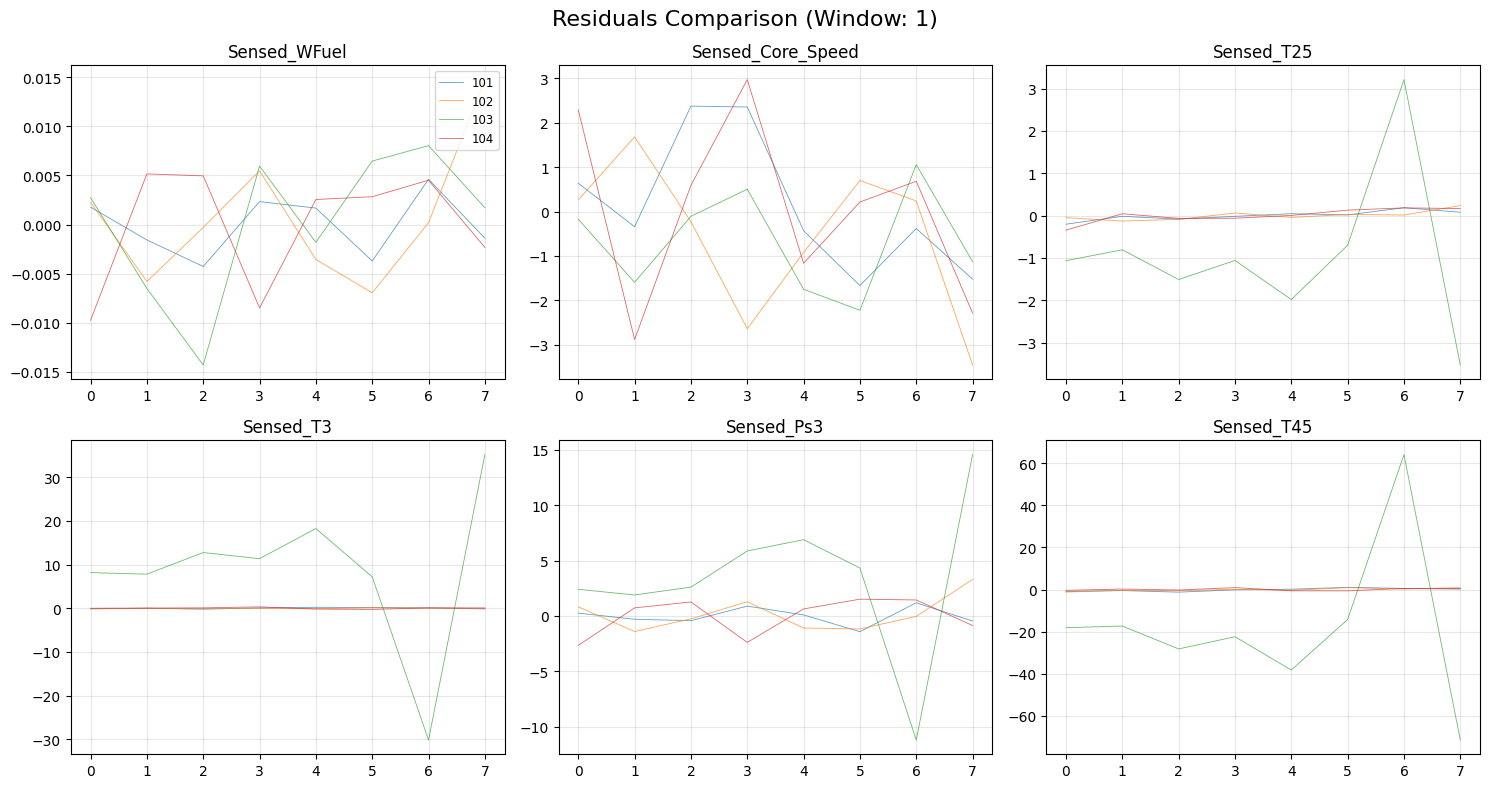

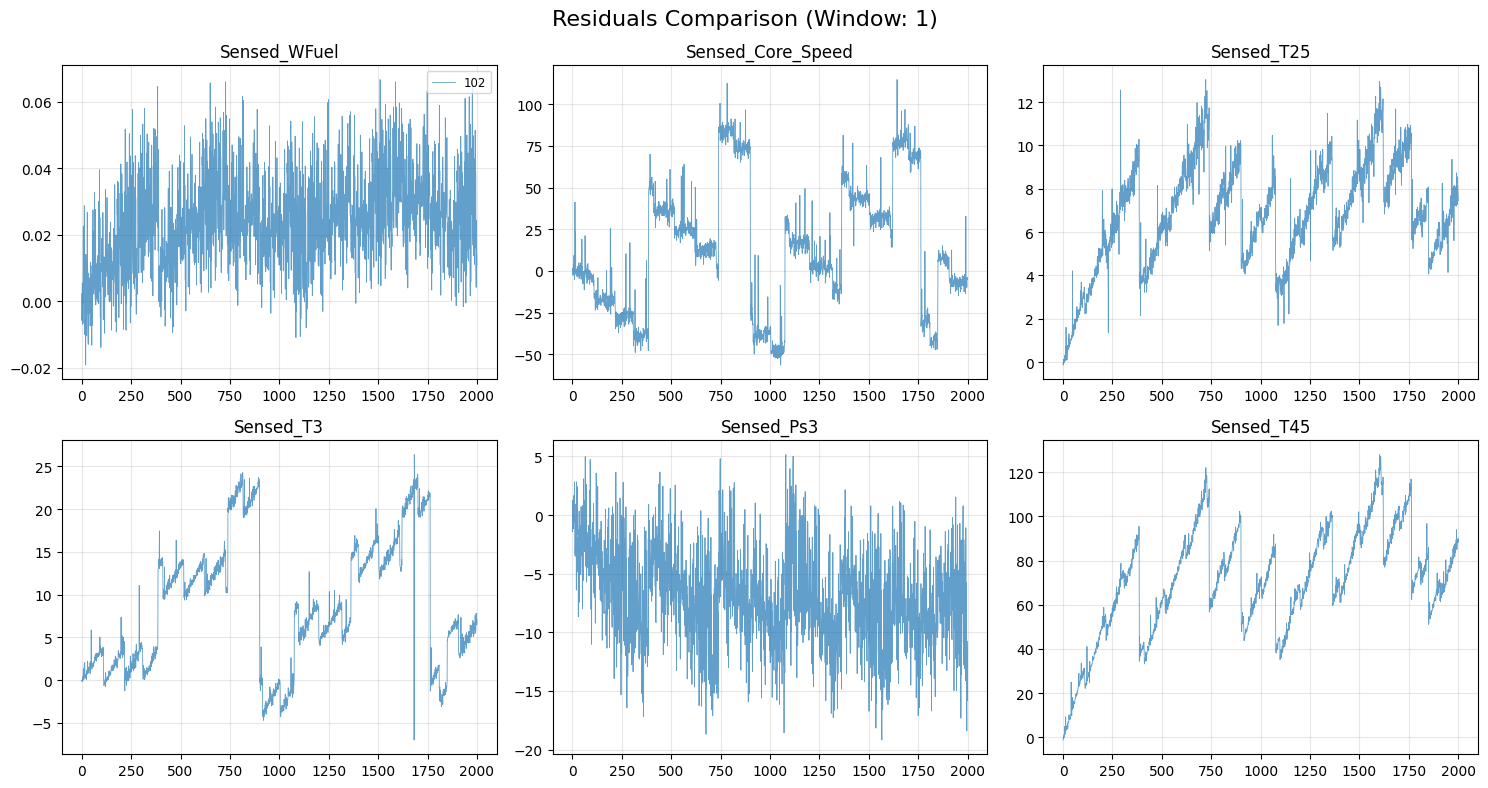

In [171]:

# nella visualizzazione, raggruppare i cicli per gruppi?
GROUP_CYCLES = True
# rimuovere outliers durante il plot?
REMOVE_OUTLIERS = True
# il metodo usato è "z-score"
OUTLIERS_THRESHOLD = 3


def plot(data, window, min):
    fig, axs = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"Residuals Comparison (Window: {window})", fontsize=16)
    axs = axs.flatten()
    for esn in data["ESN"].unique():
        if "aug" in str(esn):
            continue
        res_temp = data[data["ESN"] == esn]
        if GROUP_CYCLES:
            res_temp = res_temp.groupby("Cycles").mean()
        if REMOVE_OUTLIERS:
            res_temp = pp.remove_outliers(res_temp, threshold=OUTLIERS_THRESHOLD)
            res_temp = res_temp.ffill()
            res_temp = res_temp.bfill()
        for i, ax in enumerate(axs):
            if i < len(DEGRAD_VARS):  # Safety check
                d_var = DEGRAD_VARS[i]
                t = res_temp[d_var]
                degrad = (
                    t.rolling(window=window, min_periods=min)
                    .mean()
                    .reset_index(drop=True)
                )
                ax.plot(degrad, linewidth=0.6, alpha=0.7, label=str(esn))
                ax.set_title(d_var)
                ax.grid(True, alpha=0.3)

    axs[0].legend(fontsize="small", loc="upper right")
    plt.tight_layout()
    plt.show()


plot(res_train, 1, 1)
plot(res_test, 1, 1)
# plot(residuals(dfv), 10, 1)
# plot(residuals(dft), 10, 1)

# HPT e HPC
Ricerca del valore del coefficiente $\alpha$ in base alla correlazione
Se USE_ALL_VARS è attivo, i coefficienti sono $\alpha$ e $\beta$, altrimenti solo $\alpha$.
$\alpha$ è applicato a $\text{Sensed\_T3}$, mentre, se esiste, $\beta$ verrà applicato a $\text{Sensed\_T45}$

In [172]:

# se si vuole evitare la ricerca e usare parametri default
DO_NOT_TRAIN_COEFS = True

USE_ALL_VARS = False

# Parametri di configurazione di differential_evolution()
# quante volte deve iterare il processo di ricerca (ovvero dopo MAXITER spostamenti dei puntini,
# il valore che più basso tra tutti i puntini sarà quello selezionato)
MAXITER = 100
# population size (l'algoritmo spawna questo numero di punti in giro
# per la funzione e cerca il valore che minimizza la funzione obiettivo)
POPSIZE = 500
# Tolleranza
TOL = 0.001

# True: usa solo i motori indicati come train, False prende anche TESTING_ESN
USE_ONLY_TRAIN = False

# Preprocessare i dati?
USE_CLEAN_DATA = True
OUTLIERS_THRESHOLD = 3

# Ogni motore avrà i proprio coefficienti?
# se True, allora ogni ESN avrà la sua coppia $$\alpha_{\text{hpt}}$$ e $$\alpha_{\text{hpc}}
SEPARATE_COEFS = True

if USE_ONLY_TRAIN:
    esn_data = df.copy().loc[df["ESN"] != TESTING_ESN]
else:
    esn_data = df.copy()

res = residuals(esn_data)
esn_data[DEGRAD_VARS] = res[DEGRAD_VARS]
X_train = esn_data.copy()

if USE_CLEAN_DATA:
    X_train = X_train.groupby(["ESN", "Cycles_Since_New"], as_index=False).median()
    X_train = pp.remove_outliers(X_train, threshold=OUTLIERS_THRESHOLD)
    X_train = X_train.ffill()
    X_train = X_train.bfill().dropna()

coef_data = X_train.copy()

# ESECUZIONE
if not DO_NOT_TRAIN_COEFS:
    target = None
    target_vars = []
    if not USE_ALL_VARS:
        def _target_1(a, vars, RUL):
            vars.dropna()
            hi = HI(vars["Sensed_T3"], vars["Sensed_T45"], a)
            if max(hi) == min(hi):
                return 1.0
            RUL = RUL.dropna()
            corr = stats.pearsonr(RUL, hi)
            return -corr[0]

        target = _target_1
        target_vars = ["Sensed_T45", "Sensed_T3"]
        bounds = [(-1000, 1000)]
    else:
        def _target_2(params, vars, RUL):
            hi = HIE(params, vars)
            hi_min, hi_max = hi.min(), hi.max()
            if hi_max == hi_min:
                return 1.0
            hi_norm = (hi - hi_min) / (hi_max - hi_min)
            mse = np.mean((hi_norm - RUL) ** 2)
            return mse

        target = _target_2
        target_vars = DEGRAD_VARS
        bounds = [(-1000, 1000)] * 6

    chpt = {}
    chpc = {}

    for esn in X_train["ESN"].unique():
        print(esn)
        tv = X_train.loc[X_train["ESN"] == esn, target_vars]
        rul = X_train.loc[X_train["ESN"] == esn, "Cycles_to_HPT_SV"]
        result_hpt = differential_evolution(
            target,
            bounds=bounds,
            args=(tv, rul),
            strategy="best1bin",
            maxiter=MAXITER,  # generazioni
            popsize=POPSIZE,
            workers=-1,
            tol=TOL,  # Tolleranza
        )

        chpt[str(esn)] = result_hpt.x

        rul = X_train.loc[X_train["ESN"] == esn, "Cycles_to_HPC_SV"]
        result_hpc = differential_evolution(
            target,
            bounds=bounds,
            args=(tv, rul),
            strategy="best1bin",
            maxiter=MAXITER,  # generazioni
            popsize=POPSIZE,
            workers=-1,
            tol=TOL,  # Tolleranza
        )
        chpc[str(esn)] = result_hpc.x

    if not SEPARATE_COEFS:
        chpt = np.median(np.array(chpt.values()))
        chpc = np.median(np.array(chpc.values()))

    print("\nCOEFFICIENTI MEDI FINALI (Training Set):")
    print(f"HPT: {chpt.values}")
    print(f"HPC: {chpc.values}")

else:
    chpt = {
        "101": -2.23102809,
        "102": -2.23102809,
        "103": -2.23102809,
        "104": -2.23102809,
    }
    chpc = {"101": 4.25050266, "102": 4.25050266, "103": 4.25050266, "104": 4.25050266}

TWE for 101: 76.80338287777158
TWE for 102: 127.99076194723683
TWE for 103: 9836.155063413084
TWE for 104: 1008.8433270791471


/tmp/ipykernel_9965/1371743263.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


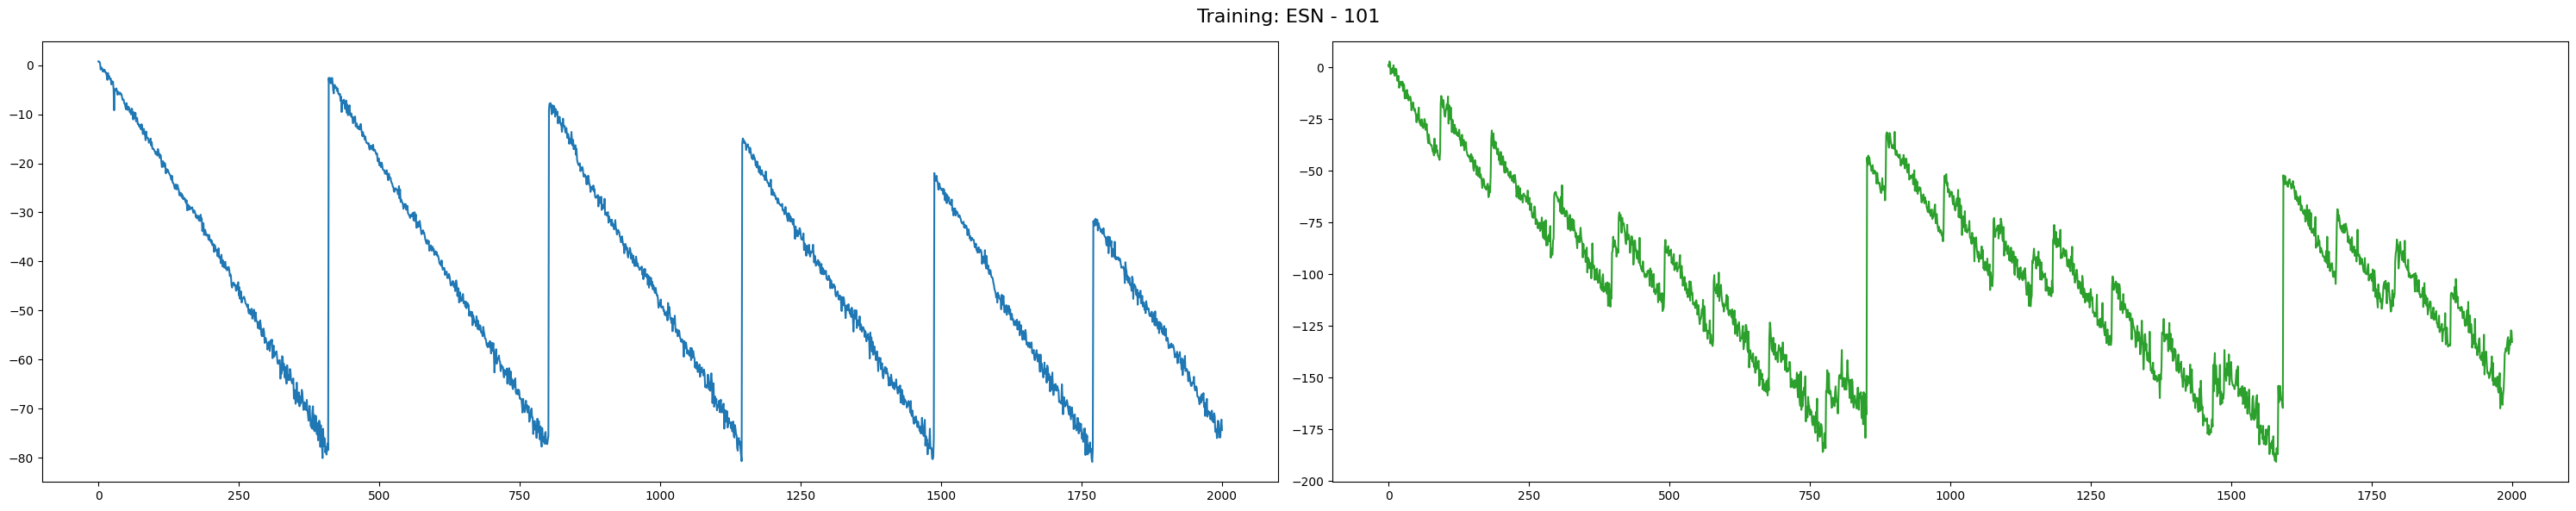

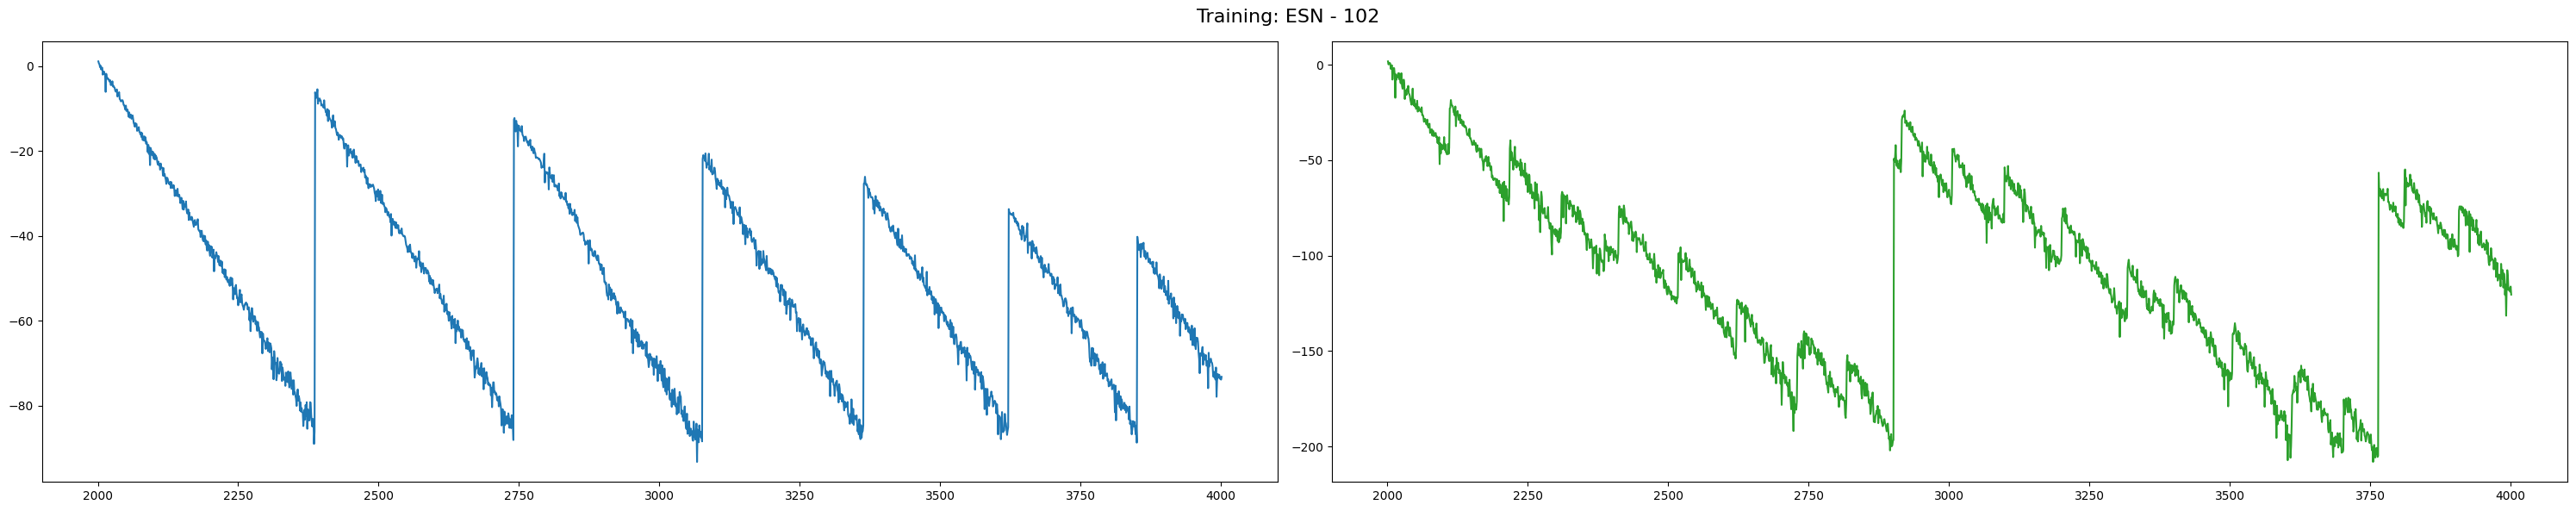

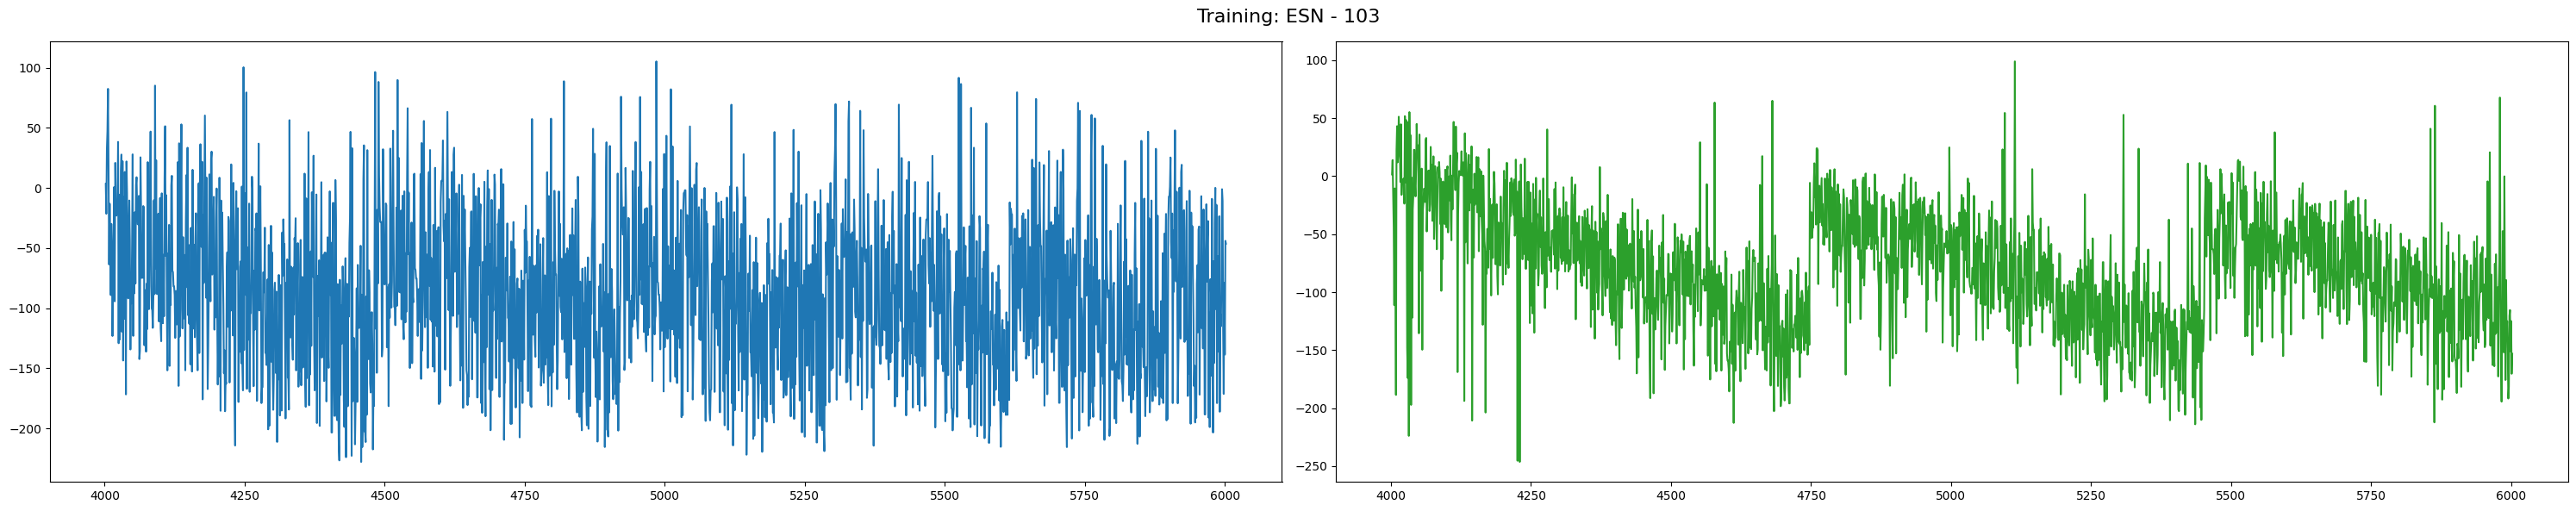

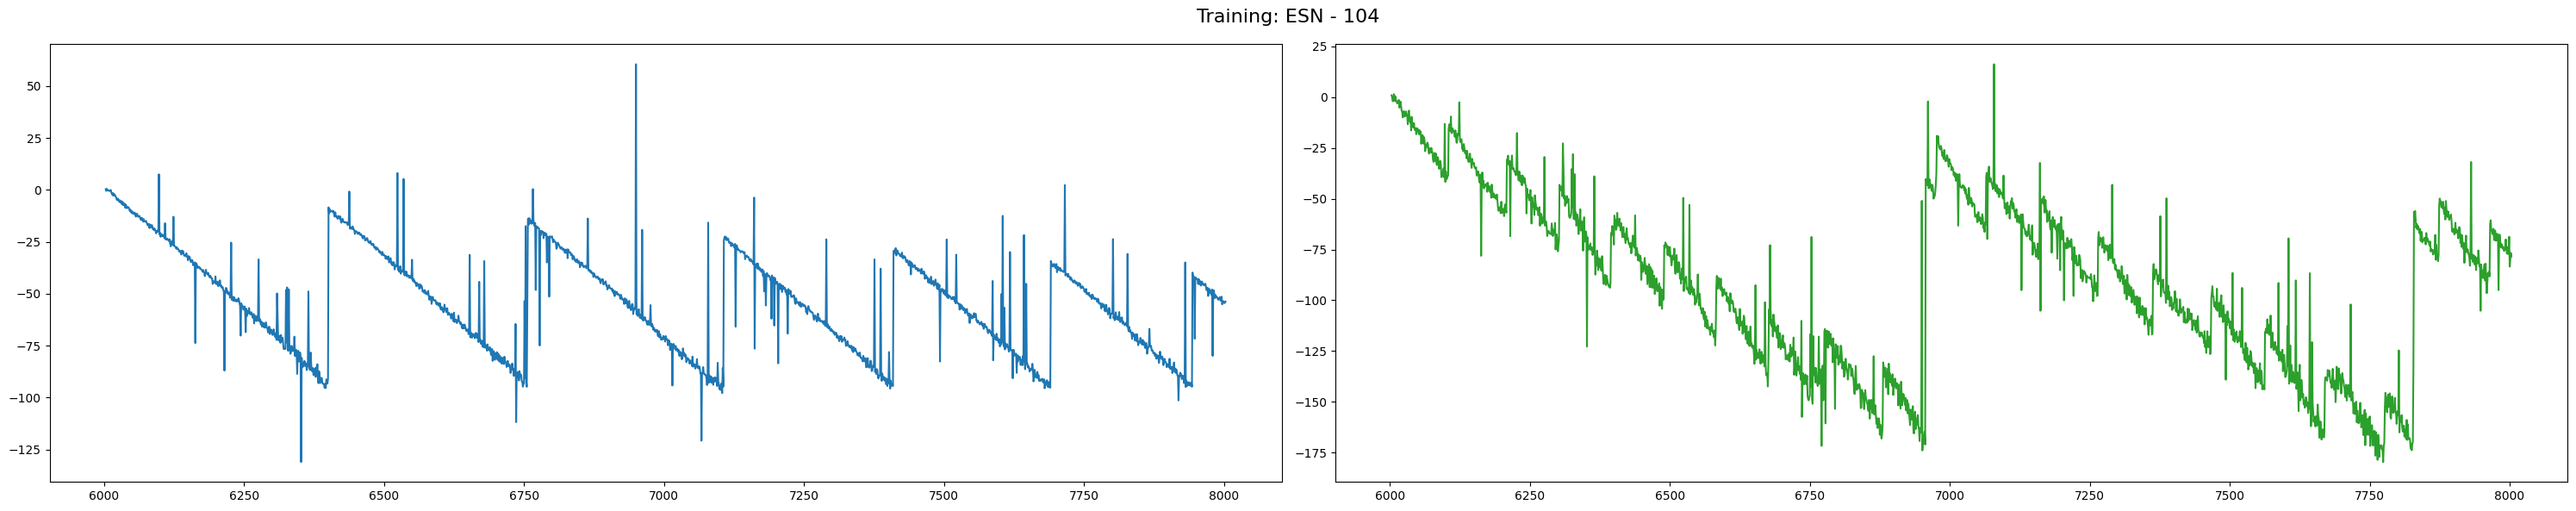

In [173]:
# PLOTTING SU DATI DI TRAINING

# alias per cambiare facilmente dataset
DATA = coef_data.copy()

hpt_limits, hpc_limits, ww_limits = [], [], []


def calc_hi(sd):
    if USE_ALL_VARS:
        hi_hpt = HIE(ahpt, sd[target_vars])
        hi_hpc = HIE(ahpc, sd[target_vars])
    else:
        hi_hpt = HI(sd["Sensed_T3"], sd["Sensed_T45"], ahpt)
        hi_hpc = HI(sd["Sensed_T3"], sd["Sensed_T45"], ahpc)
    return hi_hpt, hi_hpc


for esn in DATA["ESN"].unique():
    sd = DATA[DATA["ESN"] == esn].copy()

    if SEPARATE_COEFS:
        if isinstance(chpt, dict) and isinstance(chpc, dict):
            ahpt = chpt[str(esn)]
            ahpc = chpc[str(esn)]
        else:
            print("Zi che combini?")
    else:
        ahpt = chpt
        ahpc = chpc

    hi_hpt, hi_hpc = calc_hi(sd)

    fig, axs = plt.subplots(1, 2, figsize=(30, 6))
    fig.suptitle(f"Training: ESN - {esn}", fontsize=16)
    axs[0].plot(hi_hpt, color="tab:blue", label="Health Index (HPT)")
    axs[1].plot(hi_hpc, color="tab:green", label="Health Index (HPC)")
    fig.tight_layout()
    fig.show()

### Applicazione del LightGBM per HPT per terzo ciclo di manutenzione + correzione il gap

In [ ]:
# training lightgbm
SLOPE_WINDOW = 10

X_hpc_list, y_hpc_list = [], []

def rolling_slope_intercept(series, window):
    slopes = []
    intercepts = []
    series = np.asarray(series).flatten()
    for i in range(len(series)):
        if i < window:
            slopes.append(0)
            intercepts.append(0)
        else:
            y = series[i - window : i]
            x = np.arange(window)
            # Fit polinomiale di grado 1 (retta) -> ritorna [slope, intercept]
            poly = np.polyfit(x, y, 1)
            slopes.append(float(poly[0]))
            intercepts.append(float(poly[1]))
    return np.array(slopes), np.array(intercepts)

for esn in DATA["ESN"].unique():

    if not INCLUDE_TEST and esn == TESTING_ESN:
        continue

    esn_data = DATA[DATA["ESN"] == esn].copy()

    hi_hpt, hi_hpc = calc_hi(esn_data)

    feat_slope_hpc, feat_intercept_hpc = rolling_slope_intercept(
        hi_hpc, SLOPE_WINDOW
    )

    t = (esn_data["Cumulative_HPC_SVs"] == 2).astype(int)

    df_features = pd.DataFrame(
        {
            "HI": hi_hpc,
            "Slope": feat_slope_hpc,
            "Cycles_Accumulated": np.arange(len(hi_hpc)),  # Cicli passati
            "HI_Rolling_Mean": pd.Series(hi_hpc).rolling(50).mean().bfill(),
        }
    )

    valid_idx = df_features.dropna().index
    X_hpc_list.append(df_features.loc[valid_idx])
    y_hpc_list.append(t.loc[valid_idx])

X_train_hpc = pd.concat(X_hpc_list, ignore_index=True)
y_train_hpc = np.concatenate(y_hpc_list)

print("Training LGBM Classifier per identificazione Terzo Ciclo...")
lgbm_classifier_hpc = lgbm.LGBMClassifier(
    n_estimators=2000, learning_rate=0.03, objective="binary", importance_type="gain"
)

lgbm_classifier_hpc.fit(X_train_hpc, y_train_hpc)

Training LGBM Classifier per identificazione Terzo Ciclo...
[LightGBM] [Info] Number of positive: 1370, number of negative: 6634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000850 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 8004, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.171164 -> initscore=-1.577397
[LightGBM] [Info] Start training from score -1.577397
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,2000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [11]:
# TRAINING DEL REGRESSORE LINEARE PER LA CORREZIONE DEL GAP

X_hpc_list, y_hpc_list = [], []

# Preprocessing per TRAINING del modello
if not INCLUDE_TEST:
    esn_excluded = TESTING_ESN
for esn in DATA["ESN"].unique():
    if esn == esn_excluded:
        continue
    esn_data = DATA[DATA["ESN"] == esn].reset_index().copy()

    mask = esn_data["Cumulative_HPC_SVs"] == 2

    # Calcolo degli health index
    hi_hpt, hi_hpc = calc_hi(esn_data)

    # Calcolo errore gap
    gap_true_hpc = esn_data["Cycles_to_HPC_SV"] - hi_hpc

    window_size = 10

    feat_slope_hpc, feat_intercept_hpc = get_rolling_slope_intercept(
        hi_hpc, window_size
    )

    indices = np.where(mask)[0]

    # Accumulo dati HPC
    X_hpc_list.append(
        pd.DataFrame(
            {
                "HI": np.asarray(hi_hpc).flatten(),
                "Slope": feat_slope_hpc,
                "Cycles_Accumulated": np.arange(len(hi_hpc)),
                "Intercept": feat_intercept_hpc,
            }
        )
        .iloc[indices]
        .dropna()
    )
    y_hpc_list.append(gap_true_hpc[indices])

X_train_hpc = pd.concat(X_hpc_list, ignore_index=True)
y_train_hpc = np.concatenate(y_hpc_list)

gap_regr_hpc = LinearRegression()

# TRAINING del regressore lineare
gap_regr_hpc.fit(X_train_hpc, y_train_hpc)




NameError: name 'esn_excluded' is not defined

In [ ]:
# TEST DI CLASSIFICATORE E REGRESSORE SUI DATI DI TRAINING

if not INCLUDE_TEST:
    esn_excluded = TESTING_ESN
for esn in DATA["ESN"].unique():
    if esn == esn_excluded:
        continue
    esn_data = DATA[DATA["ESN"] == esn].reset_index().copy()

    # Calcolo degli health index
    hi_hpt, hi_hpc = calc_hi(esn_data)

    final_output_hpc = hi_hpc.copy()

    feat_slope_hpc, feat_intercept_hpc = rolling_slope_intercept(
        hi_hpc, window_size
    )

    X_test_esn = pd.DataFrame(
        {
            "HI": hi_hpc,
            "Slope": feat_slope_hpc,
            "Cycles_Accumulated": np.arange(len(hi_hpc)),  # Cicli passati
            "HI_Rolling_Mean": pd.Series(hi_hpc).rolling(50).mean().bfill(),
        }
    )

    X_test_esn = X_test_esn.ffill().bfill().fillna(0)

    # PREDIZIONE
    pred_class = lgbm_classifier_hpc.predict(X_test_esn)

    mask_real = esn_data["Cumulative_HPC_SVs"] == 2
    mask_pred = pred_class == 1

    if mask_pred.any():
        X_reg_input = pd.DataFrame(
            {
                "HI": hi_hpc,
                "Slope": feat_slope_hpc,
                "Cycles_Accumulated": np.arange(len(hi_hpc)),
                "Intercept": feat_intercept_hpc,
            }
        ).loc[mask_pred]
        pred_gap = gap_regr_hpc.predict(X_reg_input)
        final_output_hpc[mask_pred] = hi_hpc[mask_pred] + pred_gap.flatten()
        final_output_hpc = (
            pd.Series(final_output_hpc).rolling(window=50, min_periods=1).mean()
        )

    # Plot
    fig, ax1 = plt.subplots(figsize=(20, 6))
    ax1.plot(
        esn_data["Cycles_to_HPC_SV"],
        color="tab:orange",
        linestyle="--",
        label="HPC RUL",
        alpha=0.8,
    )
    ax2 = ax1.twinx()
    ax2.plot(final_output_hpc, color="tab:red", label="HI corrertto", linewidth=2)
    ax2.fill_between(
        range(len(pred_class)),
        0,
        1,
        where=mask_pred,
        color="red",
        alpha=0.05,
        label="Predizione: Terzo Ciclo",
    )
    ax2.fill_between(
        range(len(mask_real)),
        0,
        0.05,
        where=mask_real,
        color="green",
        alpha=0.5,
        label="Ground Truth (SV=2)",
    )
    ax1.set_ylabel("Value")
    ax1.set_xlabel("Cycles")
    plt.title(f"Training ESN {esn} - LightGBM + gap correction")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.2)
    plt.show()

NameError: name 'esn_excluded' is not defined

# WW
per il ww bisogna fare una cosa diversa. Intanto bisogna "normalizzare" la salita, ovvero eliminare gli effetti delle manutenzioni hpc e hpt sui residui di T45_res

TWE for 101: 76.80338287777158
21
21
TWE for 102: 127.99076194723683
20
20


/tmp/ipykernel_9965/1978185678.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wwdf[DEGRAD_VARS] = res[DEGRAD_VARS]
/tmp/ipykernel_9965/1978185678.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wwdf[DEGRAD_VARS] = res[DEGRAD_VARS]


TWE for 103: 9836.155063413084
20
21
TWE for 104: 1008.8433270791471
20
21


/tmp/ipykernel_9965/1978185678.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wwdf[DEGRAD_VARS] = res[DEGRAD_VARS]
/tmp/ipykernel_9965/1978185678.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wwdf[DEGRAD_VARS] = res[DEGRAD_VARS]


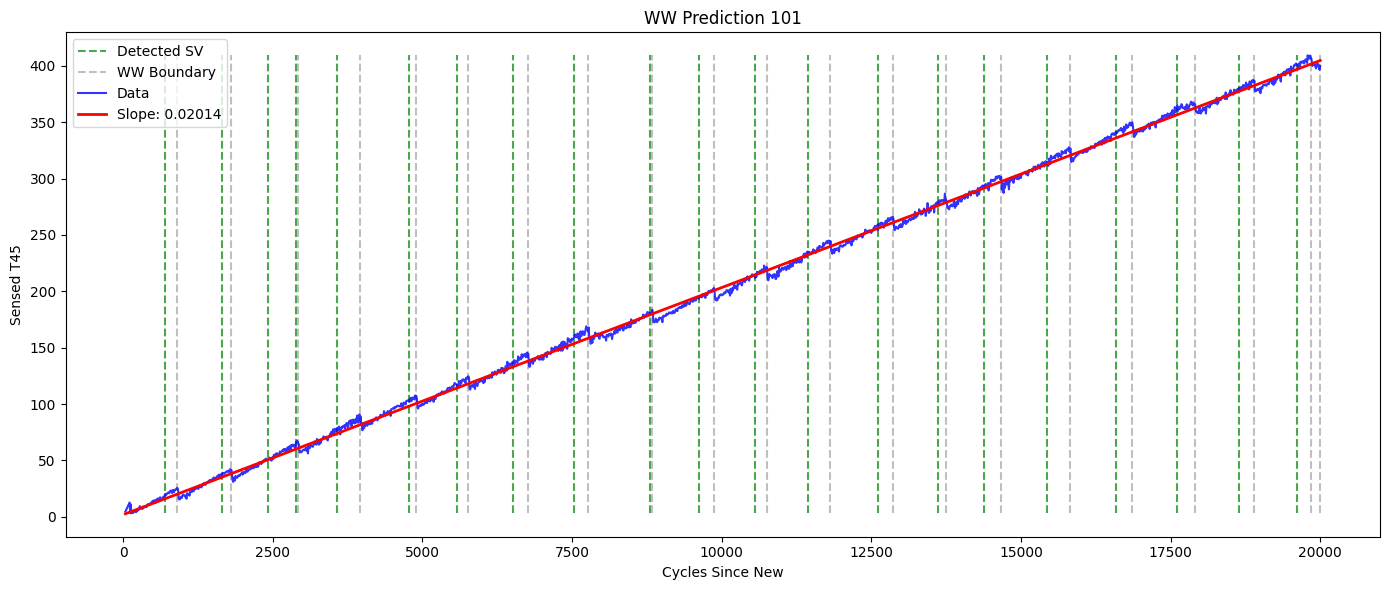

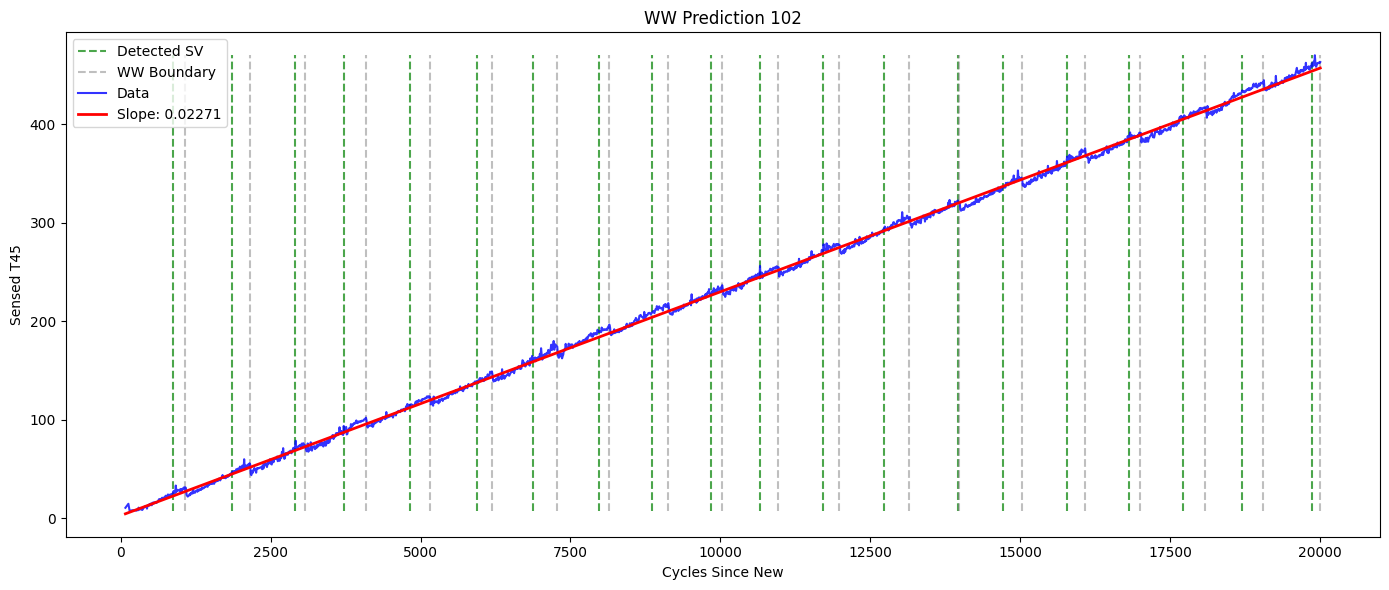

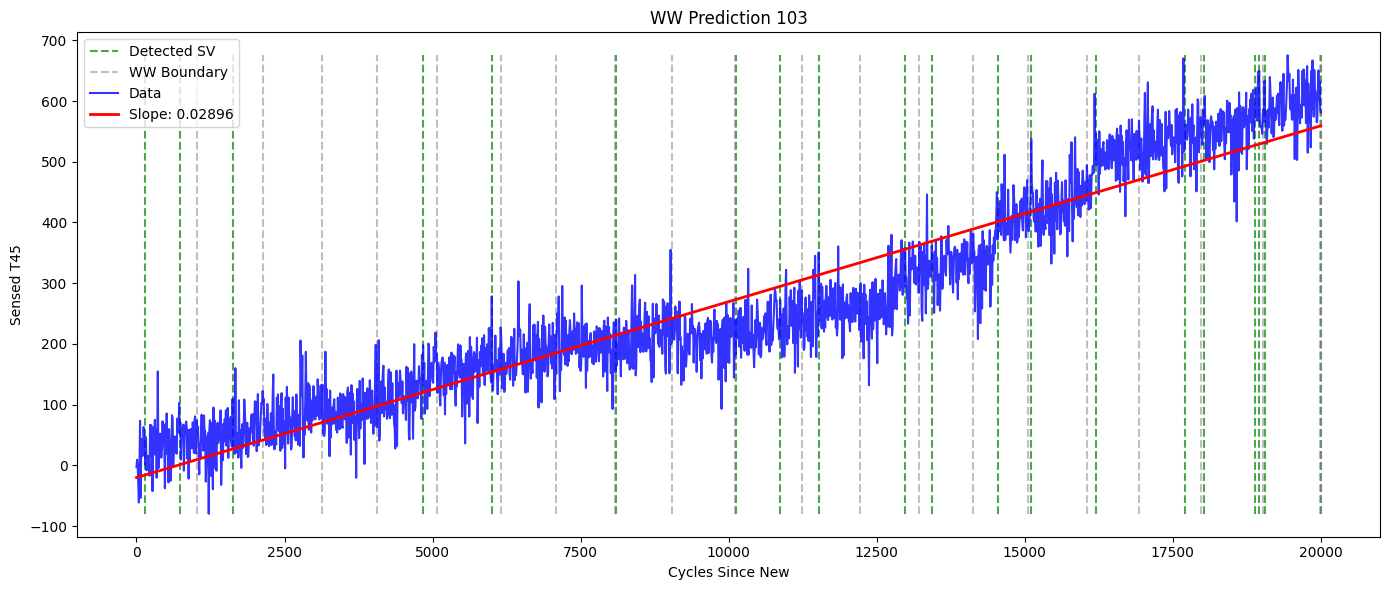

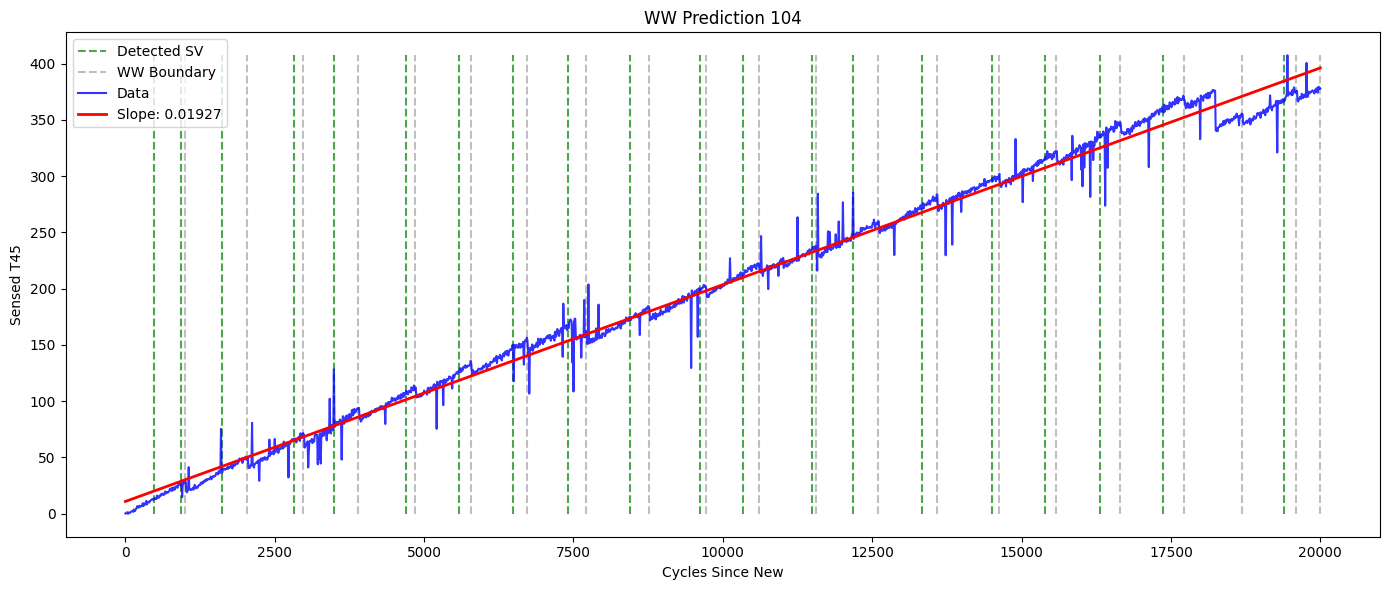

In [189]:
# fancy, sofitsticato
from math import e


def remove_effect(df, col):
    df = df.sort_values([col, "Cycles_Since_New", "Snapshot"])
    df = pp.remove_outliers(df, threshold=2.6, sensor_cols=["Sensed_T45"])
    df = df.groupby(["Cycles_Since_New"], as_index=False).median()
    grp_stats = df.groupby(col)["Sensed_T45"].agg(["first", "last"])
    grp_stats = grp_stats.sort_index()
    grp_stats["prev_last"] = grp_stats["last"].shift(1)
    grp_stats["jump"] = grp_stats["first"] - grp_stats["prev_last"]
    grp_stats["jump"] = grp_stats["jump"].fillna(0)
    grp_stats["cumulative_offset"] = grp_stats["jump"].cumsum()
    offset_map = grp_stats["cumulative_offset"].to_dict()
    df["Sensed_T45"] = df["Sensed_T45"] - df[col].map(offset_map)
    return df

def get_events(df, soglia=10):
    hi_hpt, hi_hpc = calc_hi(df)
    cond_1 = hi_hpt.diff(1) > soglia  # Differenza col punto i-1
    cond_2 = hi_hpt.diff(2) > soglia  # Differenza col punto i-2
    cond_3 = hi_hpt.diff(3) > soglia  # Differenza col punto i-3
    eventi_hpt = hi_hpt[cond_1 & cond_2 & cond_3]
    
    cond_1_c = hi_hpc.diff(1) > soglia
    cond_2_c = hi_hpc.diff(2) > soglia
    cond_3_c = hi_hpc.diff(3) > soglia
    eventi_hpc = hi_hpc[cond_1_c & cond_2_c & cond_3_c]

    return eventi_hpt, eventi_hpc



# nudo e crudo
def remove_effect_hard_core(df):
    df = df.sort_values(["Cycles_Since_New", "Snapshot"]).copy()
    df = pp.remove_outliers(df, threshold=2.6, sensor_cols=["Sensed_T45"])
    df = df.rolling(window=5, min_periods=1).median().reset_index(drop=True)
    ehpt, ehpc = get_events(df)
    df["Event_Group"] = 0
    df.loc[ehpt.index, "Event_Group"] = 1
    df["Event_Group"] = df["Event_Group"].cumsum()
    grp_stats = df.groupby("Event_Group")["Sensed_T45"].agg(["first", "last"])
    grp_stats["prev_last"] = grp_stats["last"].shift(1)
    grp_stats["jump"] = grp_stats["first"] - grp_stats["prev_last"]
    grp_stats["jump"] = grp_stats["jump"].fillna(0)
    grp_stats["cumulative_offset"] = grp_stats["jump"].cumsum()
    offset_map = grp_stats["cumulative_offset"].to_dict()
    df["Sensed_T45"] = df["Sensed_T45"] - df["Event_Group"].map(offset_map)
    df = df.drop(columns=["Event_Group"])
    return df

def plot_ww_slope(wwdf, res):
    if all(wwdf.ESN.unique() != [101,102,103,104]):
        not_training = True
    else:
        not_training = False

    wwdf[DEGRAD_VARS] = res[DEGRAD_VARS]
    wwdf = wwdf.rename(columns={"Cycles": "Cycles_Since_New"})

    if not_training:
        wwdf = remove_effect_hard_core(wwdf)
    if not not_training:
        wwdf = remove_effect(wwdf, "Cumulative_HPT_SVs")
        wwdf = remove_effect(wwdf, "Cumulative_HPC_SVs")

    wwdf = wwdf.dropna()

    X = wwdf["Cycles_Since_New"].values.reshape(-1, 1)
    Y = wwdf["Sensed_T45"].values  # Target

    reg = LinearRegression().fit(X, Y)
    slope = reg.coef_[0]

    sv = {}
    counter = []
    reference_r = None 
    floor = None
    last_cum = 0
    window = 11

    # ho scelto 542 perchè è il numero di nepero moltiplicato per 200. Si a caso e funziona anche
    factor = (e**2)*80 # poi sto provando altri valori

    if not_training:
        for i, (idx, val_t45)in enumerate(wwdf["Sensed_T45"].items()):

            if reference_r is None:
                reference_r = val_t45
                floor = val_t45
                counter.append(val_t45)
                continue

            counter.append(val_t45)
            if len(counter) < window:
                continue

            mc = np.mean(counter[-window:]) - floor
            msp = reference_r - floor
                
            if (mc - msp) > slope * factor:
                sv[idx] = val_t45               
                reference_r = val_t45           
                floor = val_t45
    else:
        for i, (idx, row) in enumerate(wwdf[["Sensed_T45", "Cumulative_WWs"]].iterrows()):
            val_t45 = row["Sensed_T45"]
            val_cum = row["Cumulative_WWs"]

            if reference_r is None:
                reference_r = val_t45
                floor = val_t45
                counter.append(val_t45)
                continue

            counter.append(val_t45)
            if len(counter) < window:
                continue

            mc = np.mean(counter[-window:]) - floor
            msp = reference_r - floor

            if val_cum > last_cum:
                last_cum = val_cum
                reference_r = val_t45
                floor = val_t45 
                
            if (mc - msp) > slope * factor: 
                sv[idx] = val_t45               
                reference_r = val_t45           
                floor = val_t45

    print(len(sv))
    if not not_training:
        print(len(wwdf["Cumulative_WWs"].unique()))

    plt.figure(figsize=(14, 6))

    sv_cycles = wwdf.loc[list(sv.keys()), "Cycles_Since_New"]

    plt.vlines(x=sv_cycles, ymin=wwdf["Sensed_T45"].min(), ymax=wwdf["Sensed_T45"].max(), colors='green', linestyles='dashed', alpha=0.7, label="Detected SV", zorder=1)

    if not not_training:
        ww_boundaries = wwdf["Cycles_Since_New"].groupby(wwdf["Cumulative_WWs"]).last()
        plt.vlines(x=ww_boundaries, ymin=wwdf["Sensed_T45"].min(), ymax=wwdf["Sensed_T45"].max(), colors='gray', linestyles='dashed', alpha=0.5, label="WW Boundary", zorder=1)

    plt.plot(wwdf["Cycles_Since_New"], wwdf["Sensed_T45"], color="blue", alpha=0.8, label="Data", zorder=2)
    plt.plot(wwdf["Cycles_Since_New"], reg.predict(X), color="red", linewidth=2, label=f"Slope: {slope:.5f}", zorder=2)

    plt.title(f"WW Prediction {esn}")
    plt.xlabel("Cycles Since New")
    plt.ylabel("Sensed T45")
    plt.legend()
    plt.tight_layout()

for esn in df["ESN"].unique():
    plot_ww_slope(df[df["ESN"] == esn], residuals(df[df["ESN"] == esn]))


Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 107: -11307.825257786653
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 108: 1512274.6599206456
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 107: -11316.87240861529
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 113: 1694829.467745824
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 114: 1225665.3704165653
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 107: 6079.777270052851
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 108: -1095.8154652000267
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 113: 2978845.829751106
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 113: 2031449.418762575
2
Non ci sono modelli a

/tmp/ipykernel_9965/1978185678.py:139: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(14, 6))


Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 113: 1478750.9746181509
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 113: 2301947.5930559975
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 107: 8077.200773075422
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 107: -11297.335015958173
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 108: 1544030.8505353206
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 114: 1267120.1453108923
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 113: 3363775.830659983
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 107: 1803.2458550187955
2
Non ci sono modelli addestrati per questo motore, usiamo ensamble generico
TWE for 113: 1862275.9908142274
2
Non ci sono modelli 

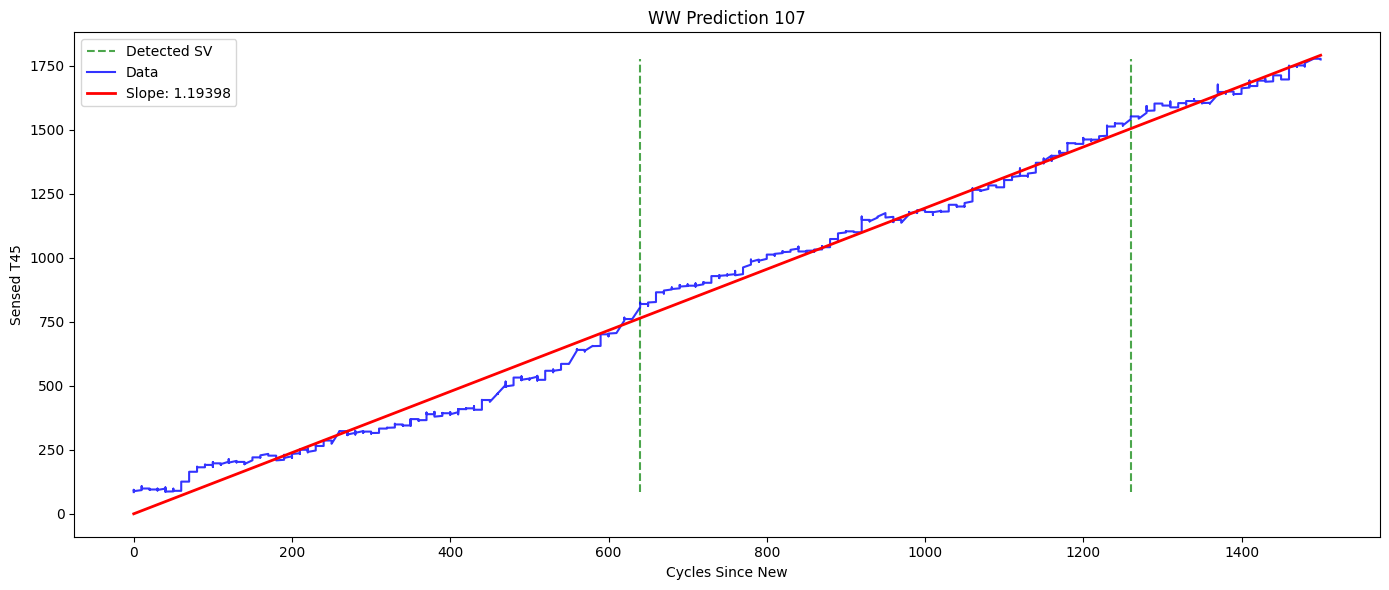

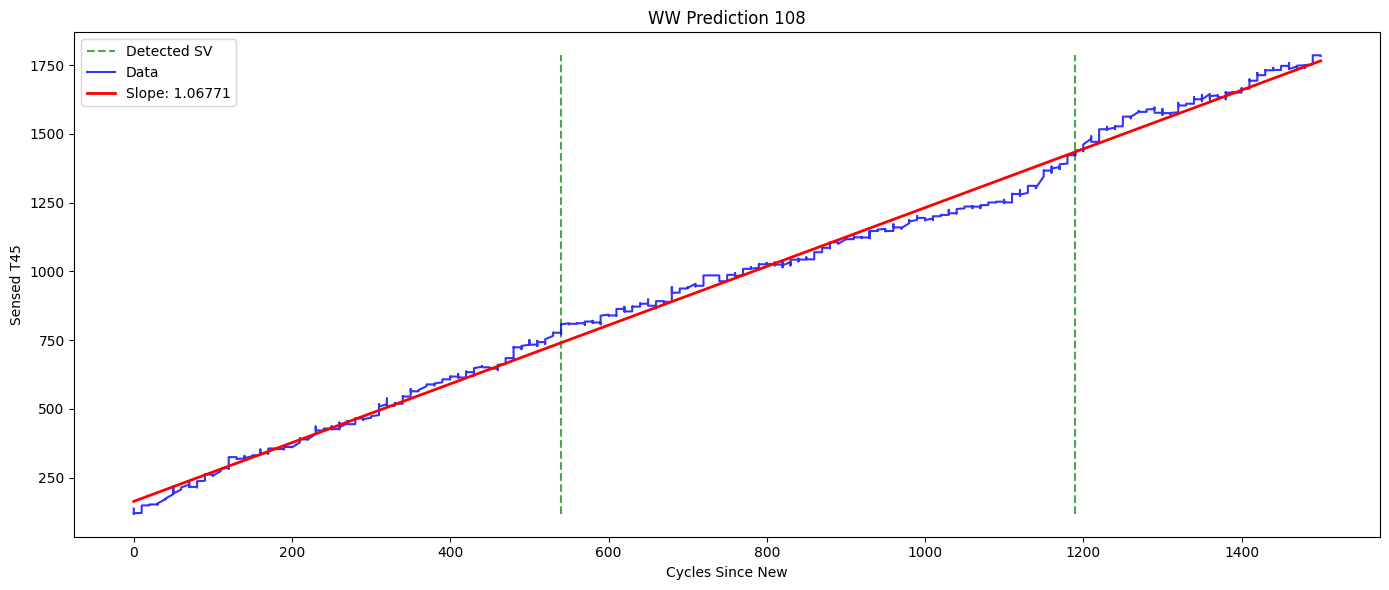

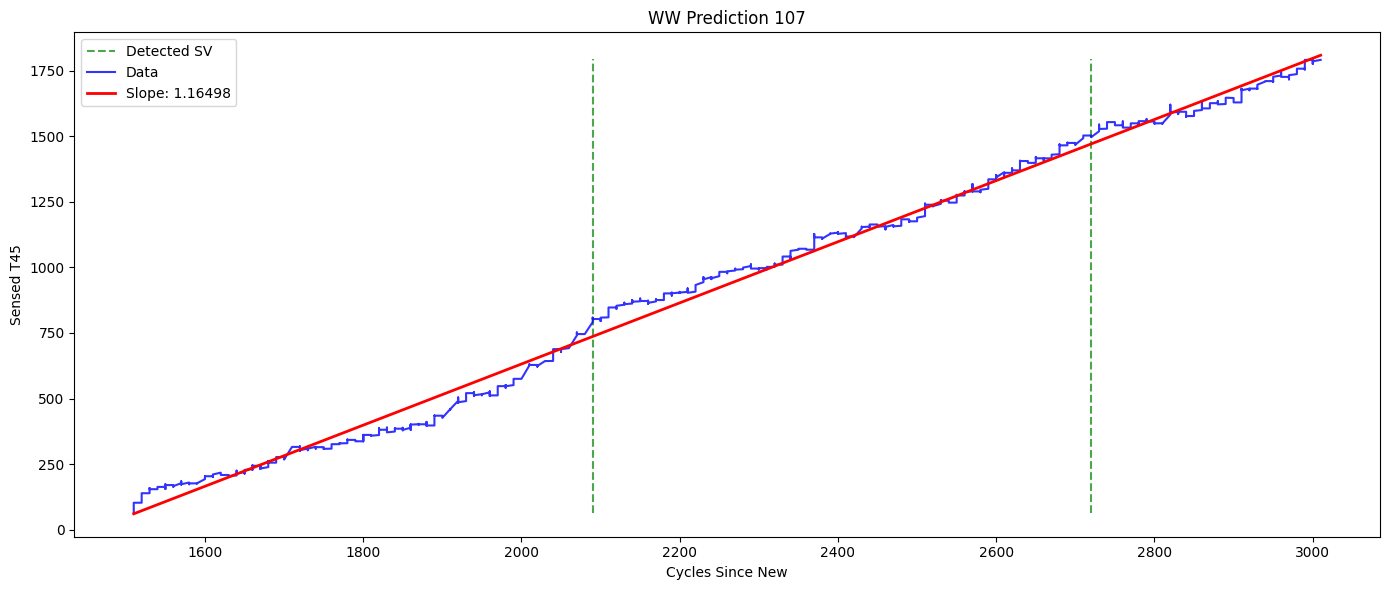

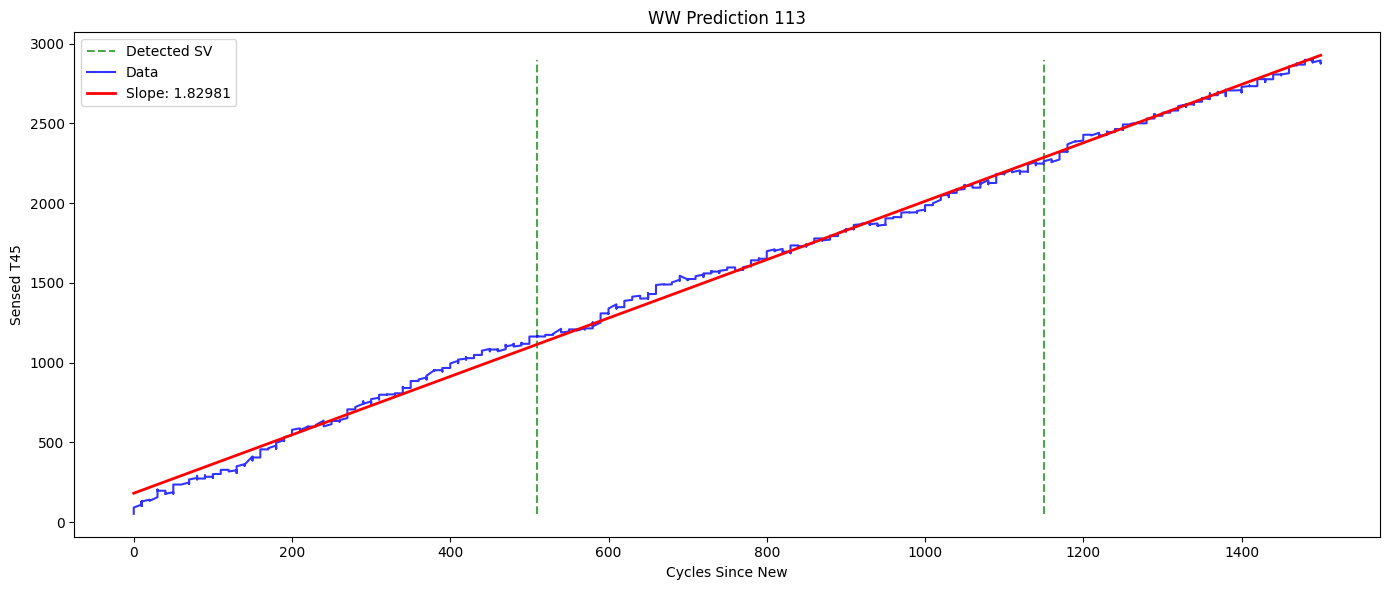

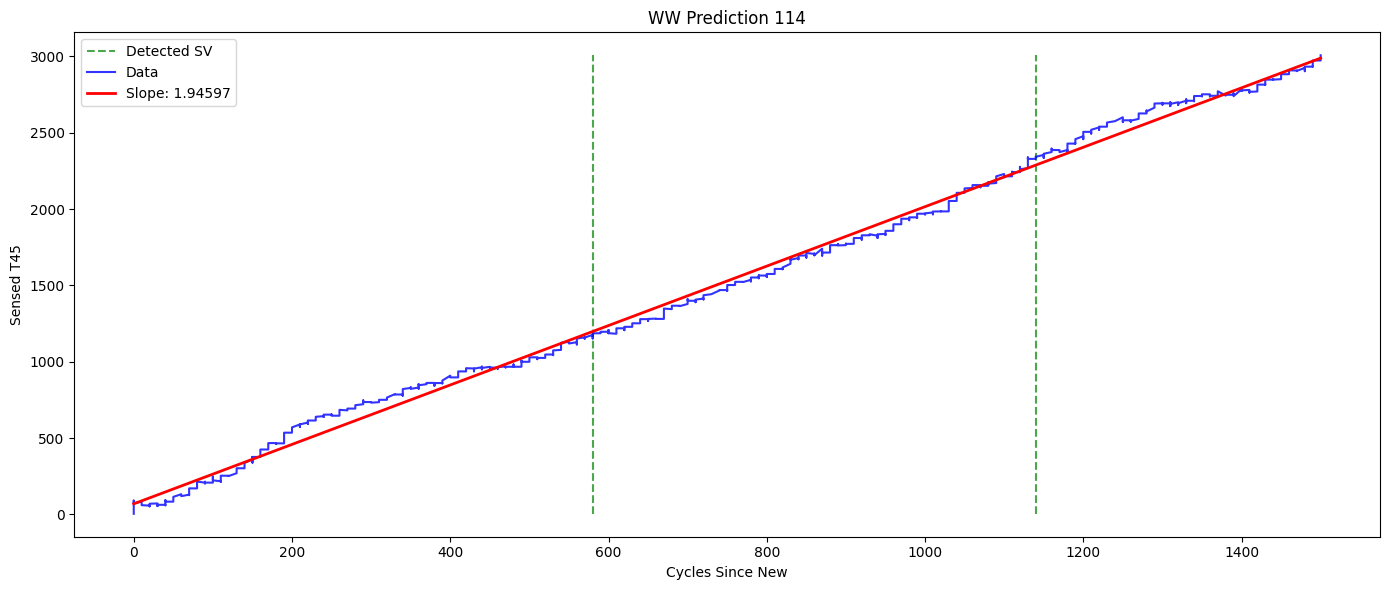

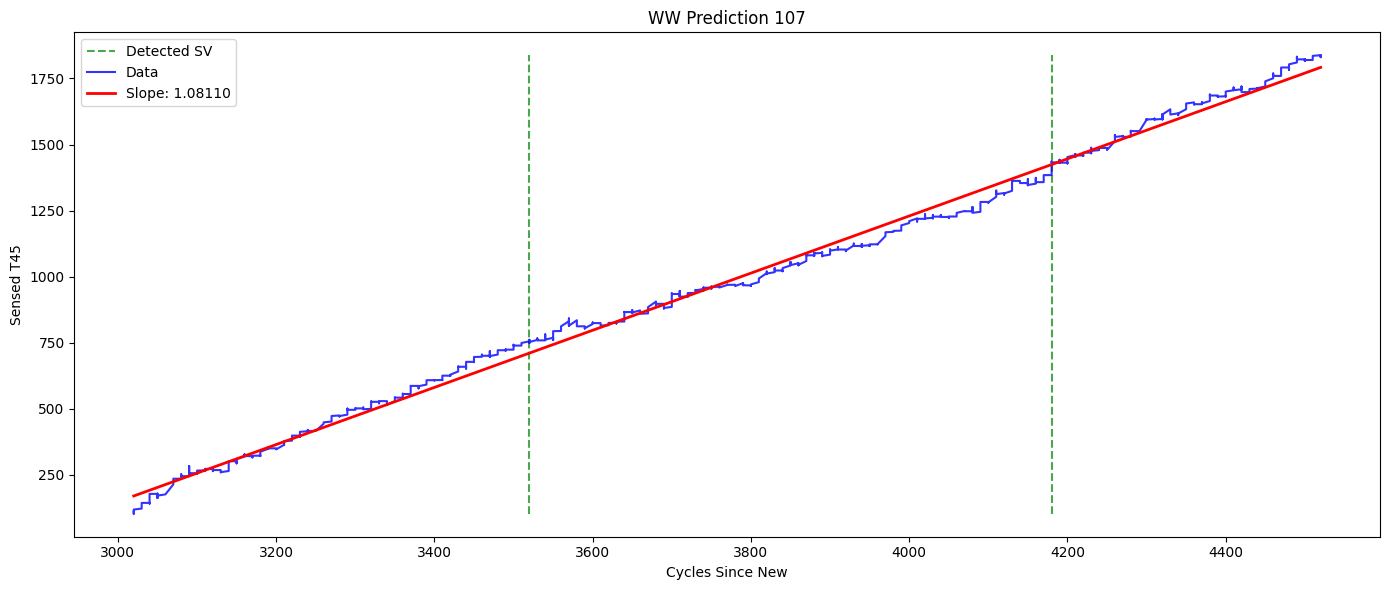

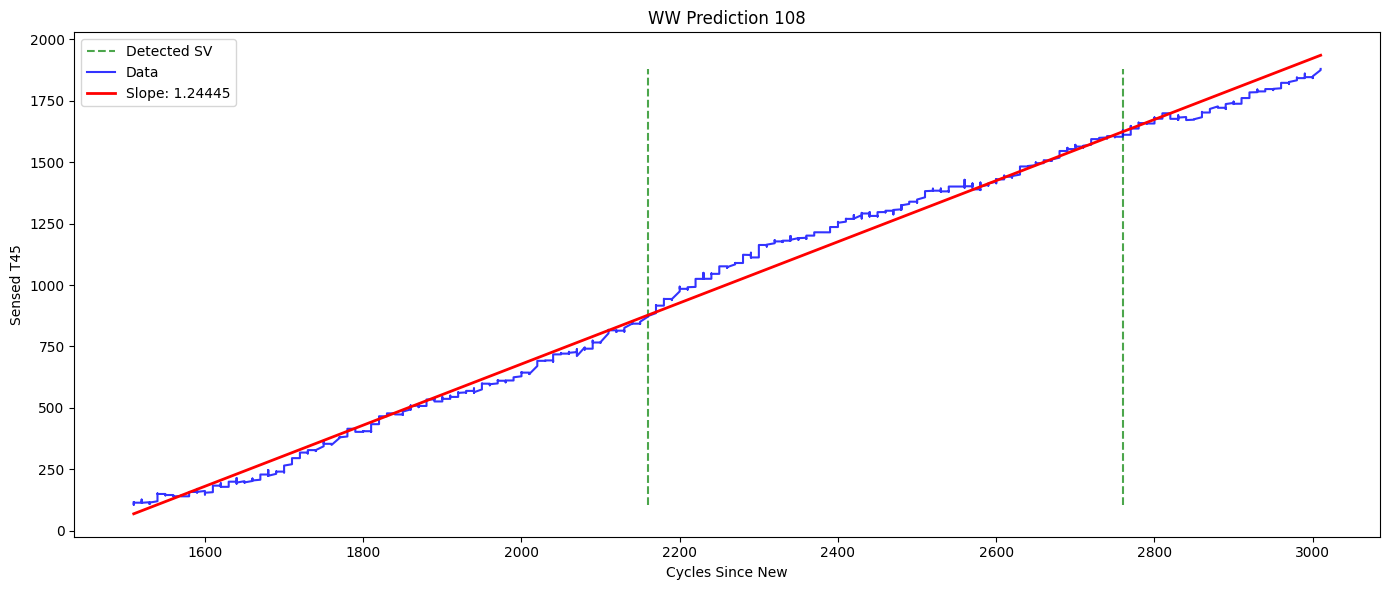

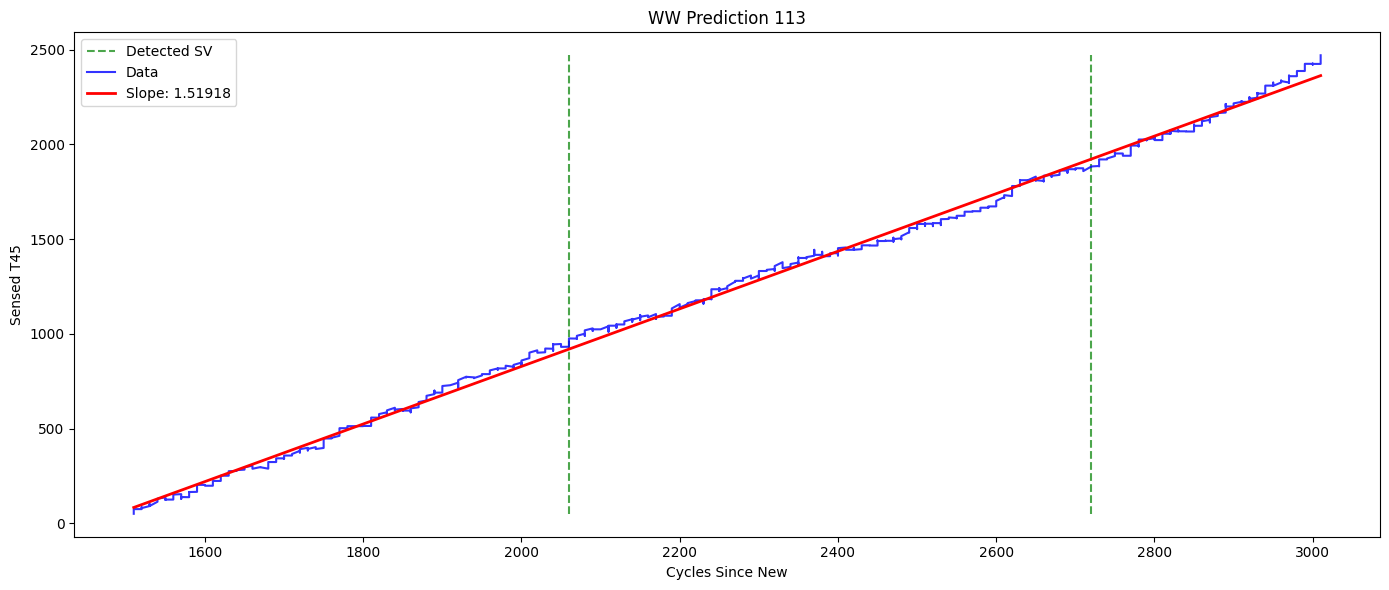

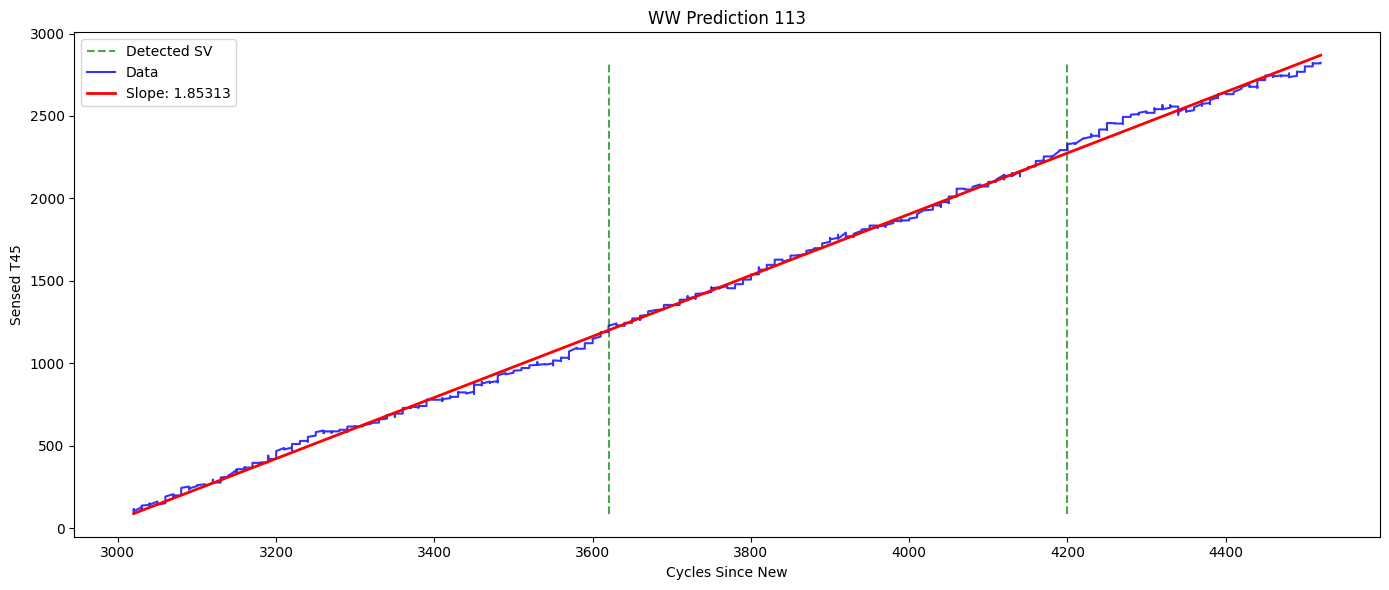

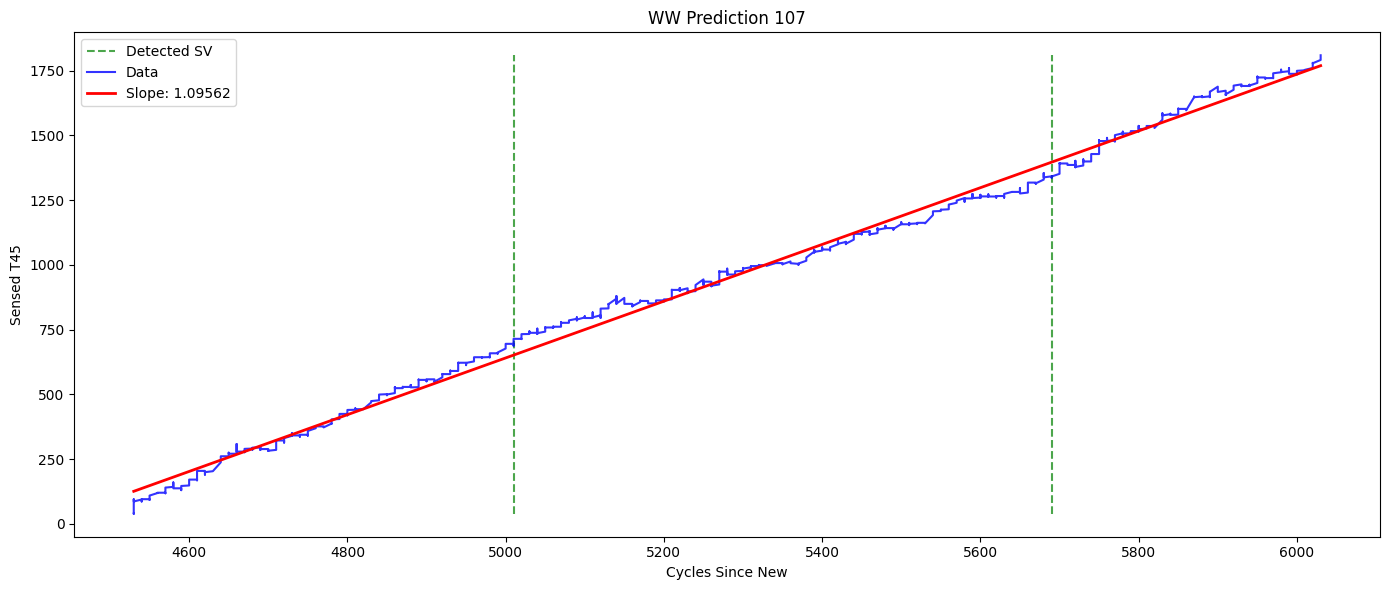

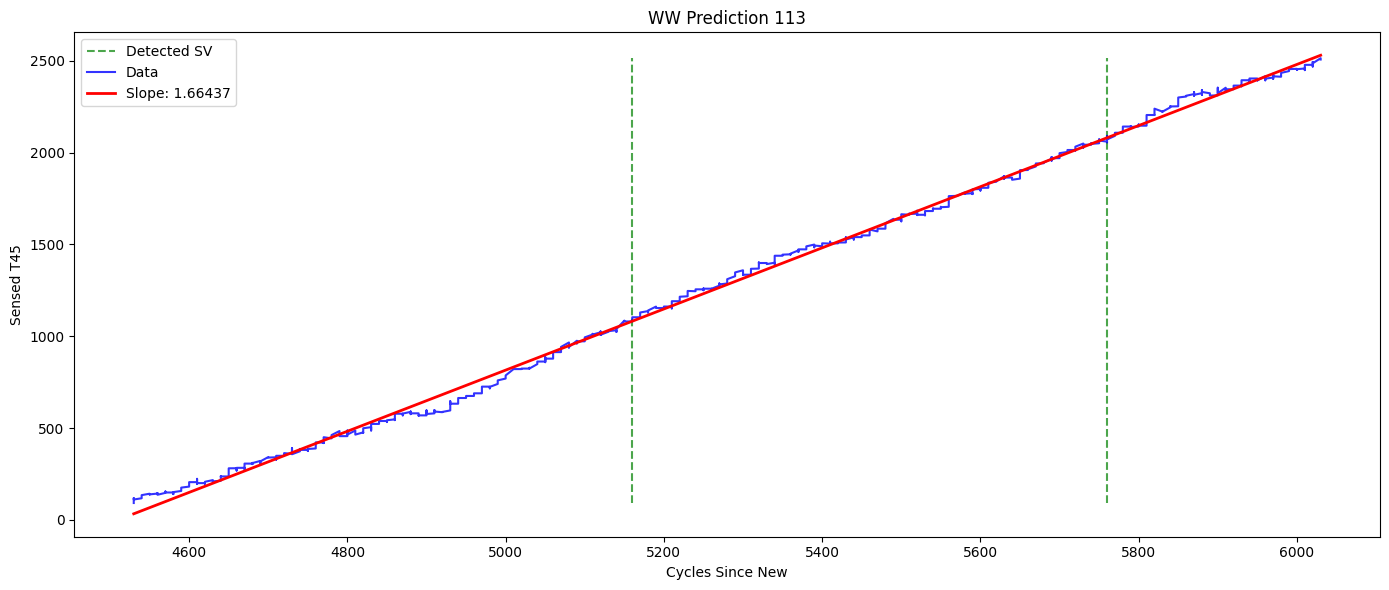

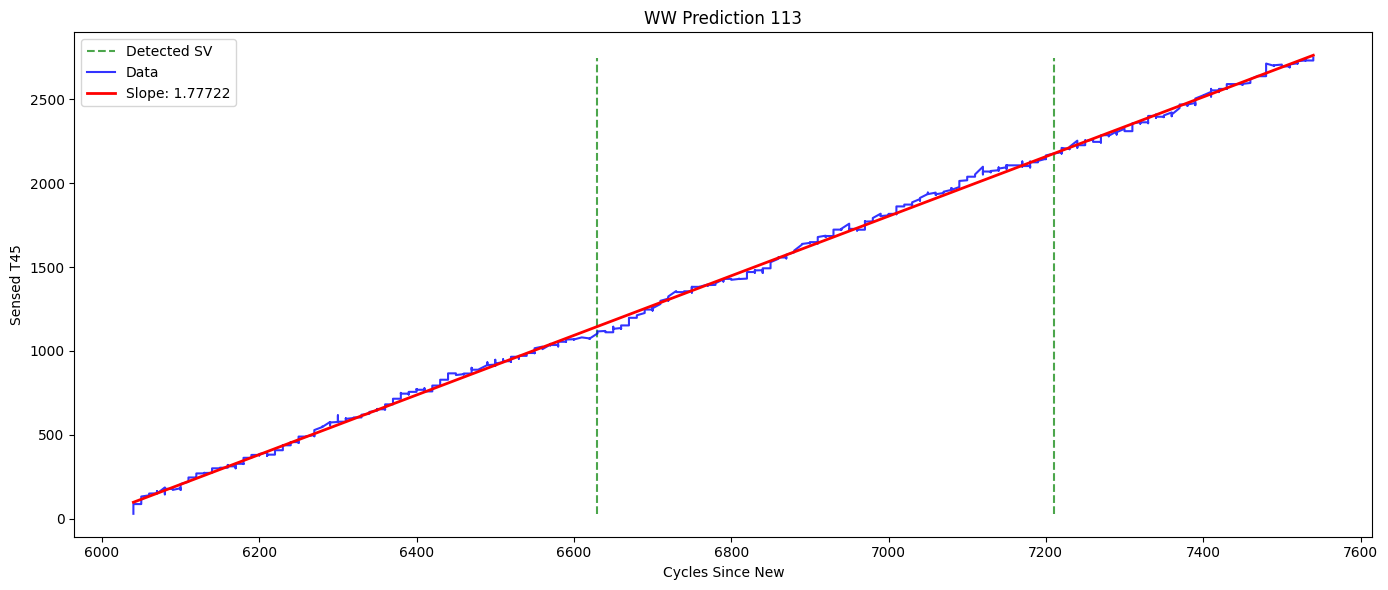

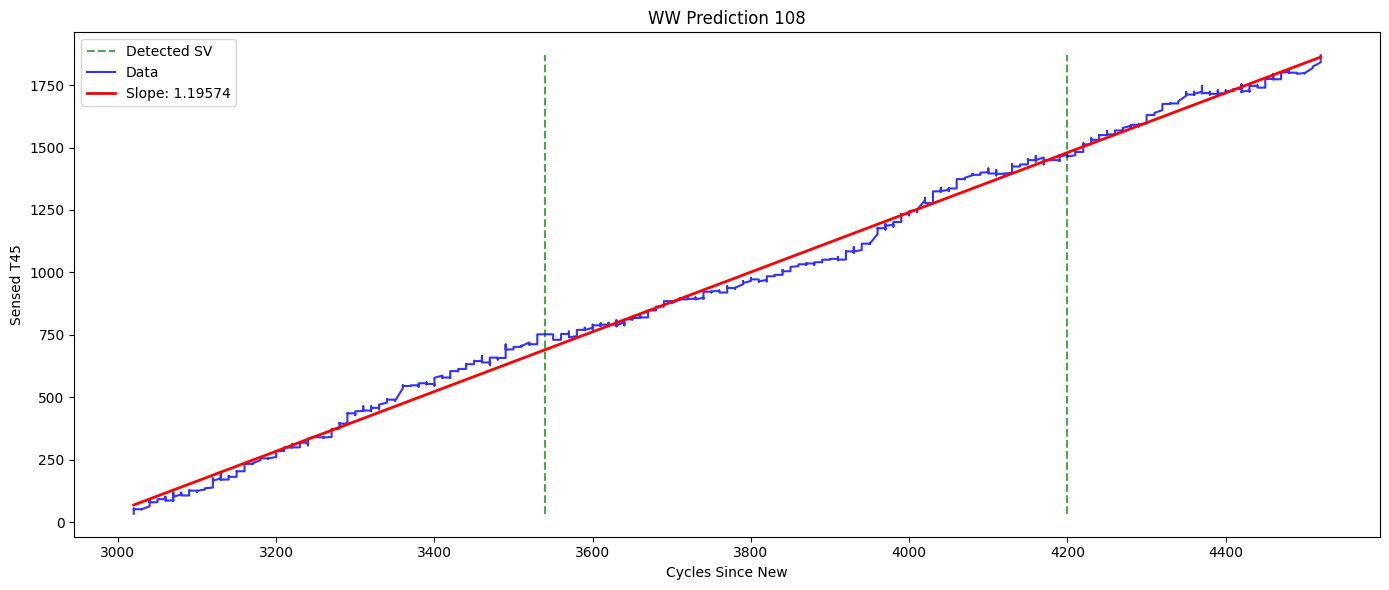

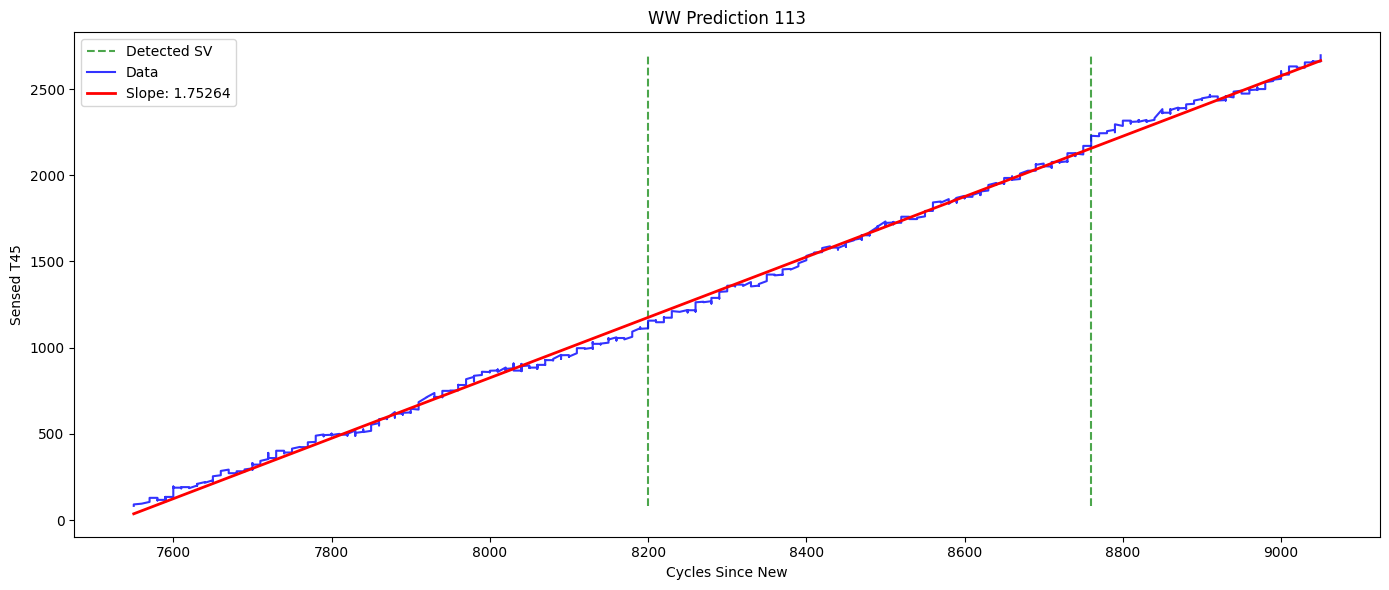

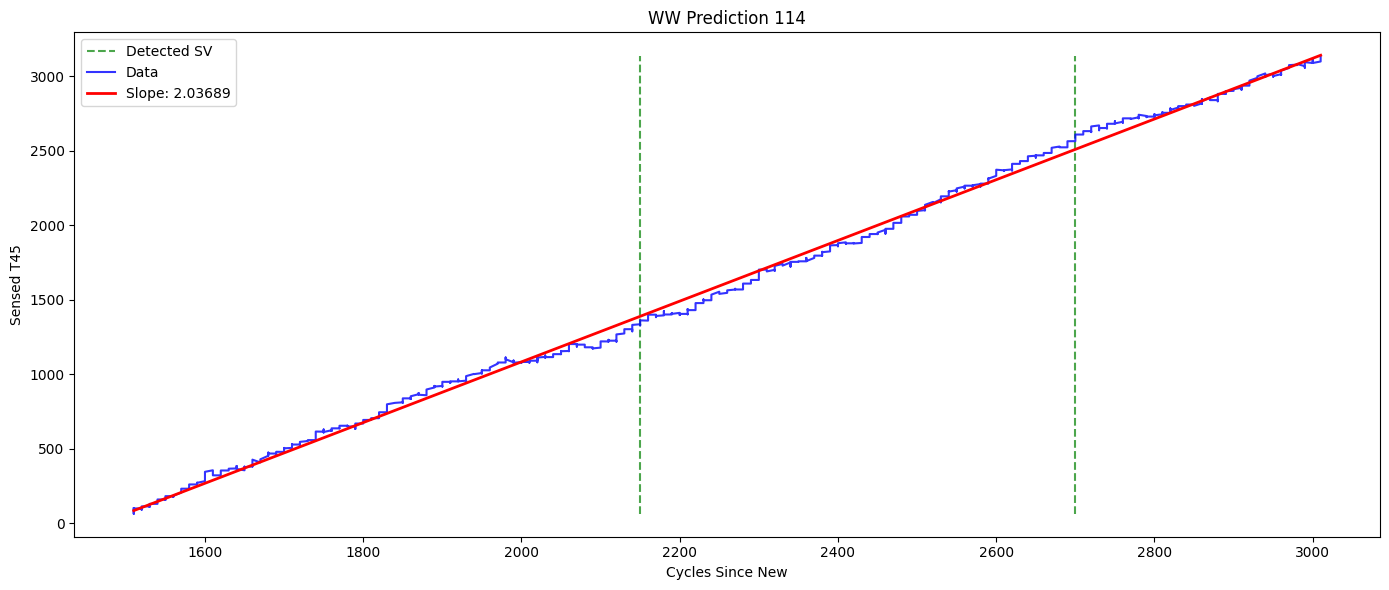

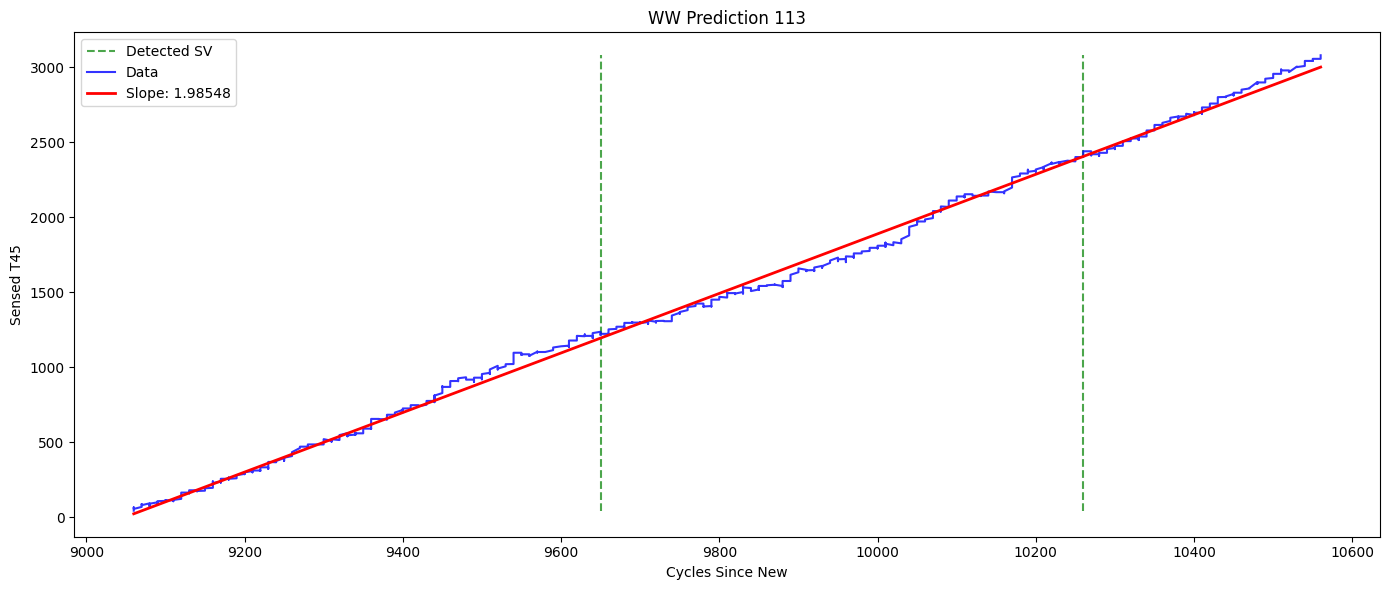

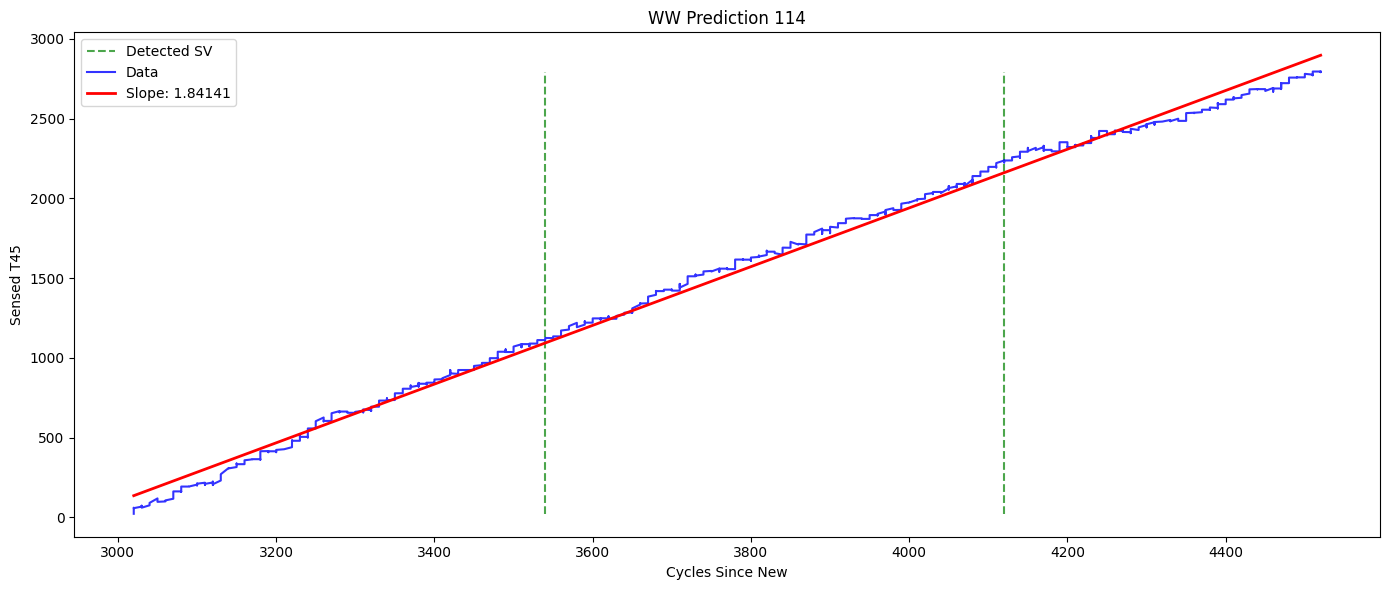

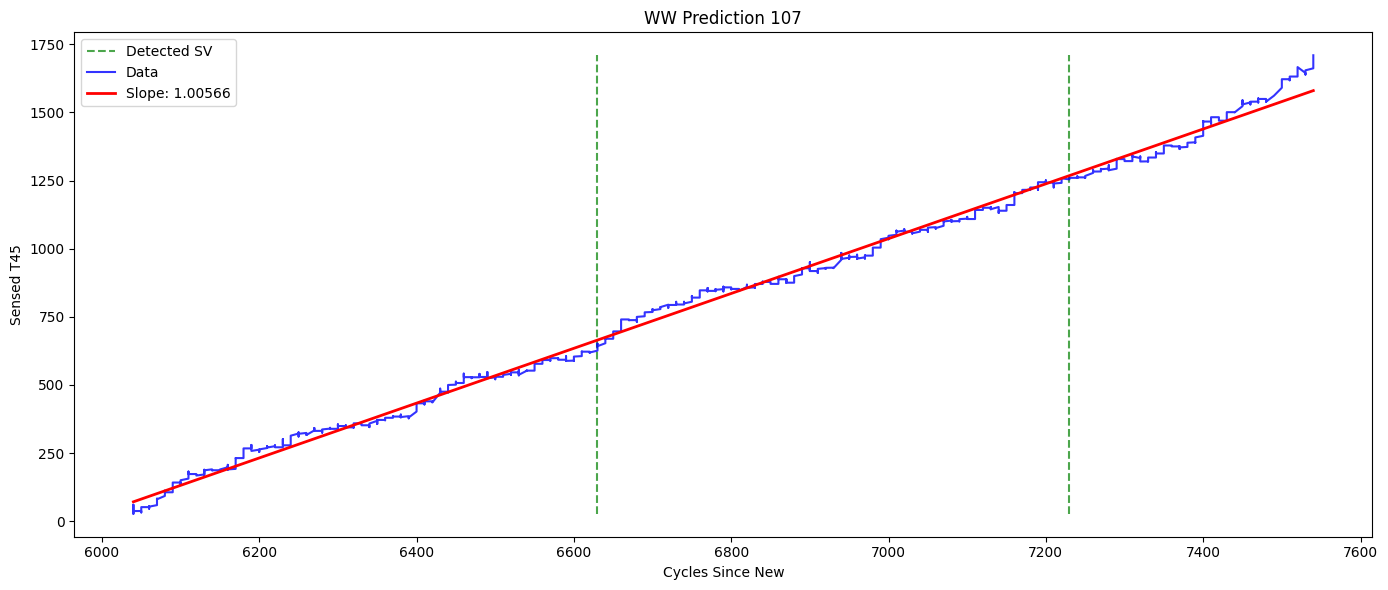

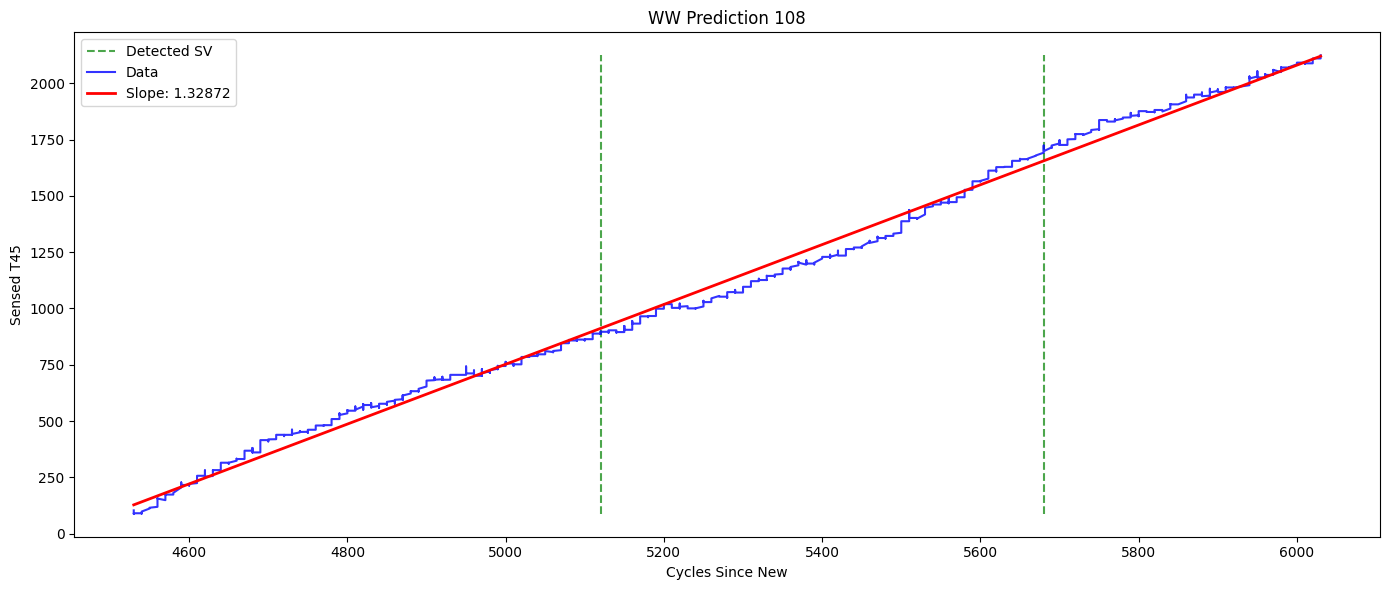

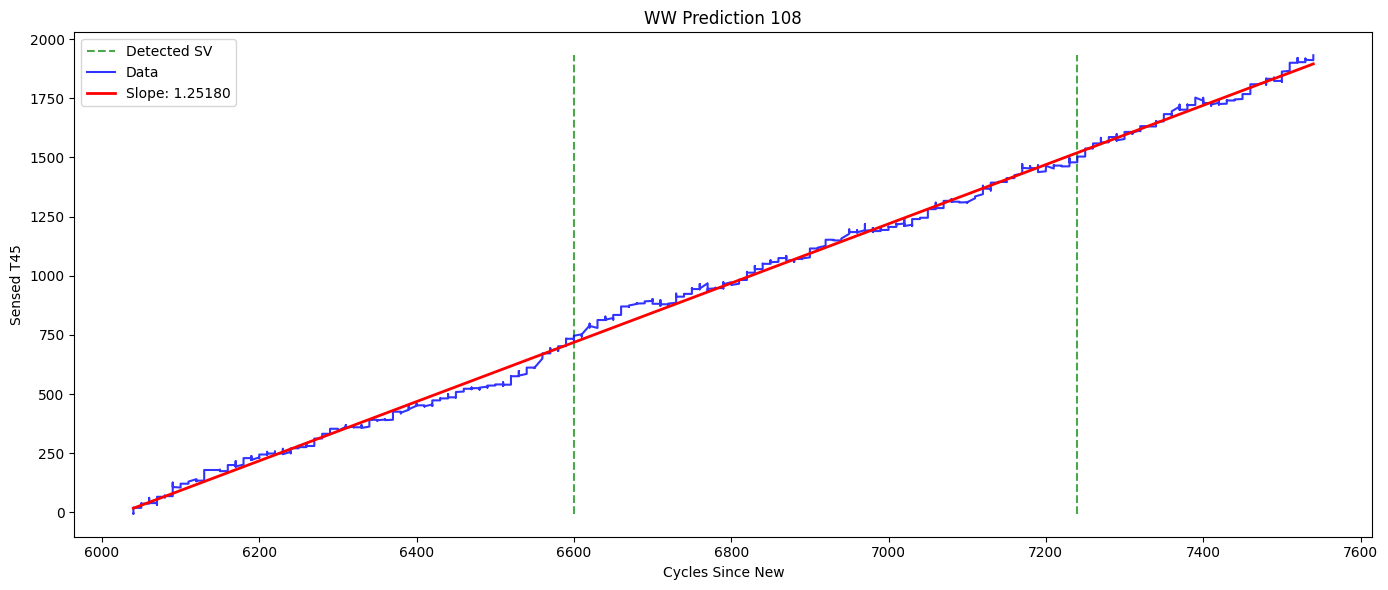

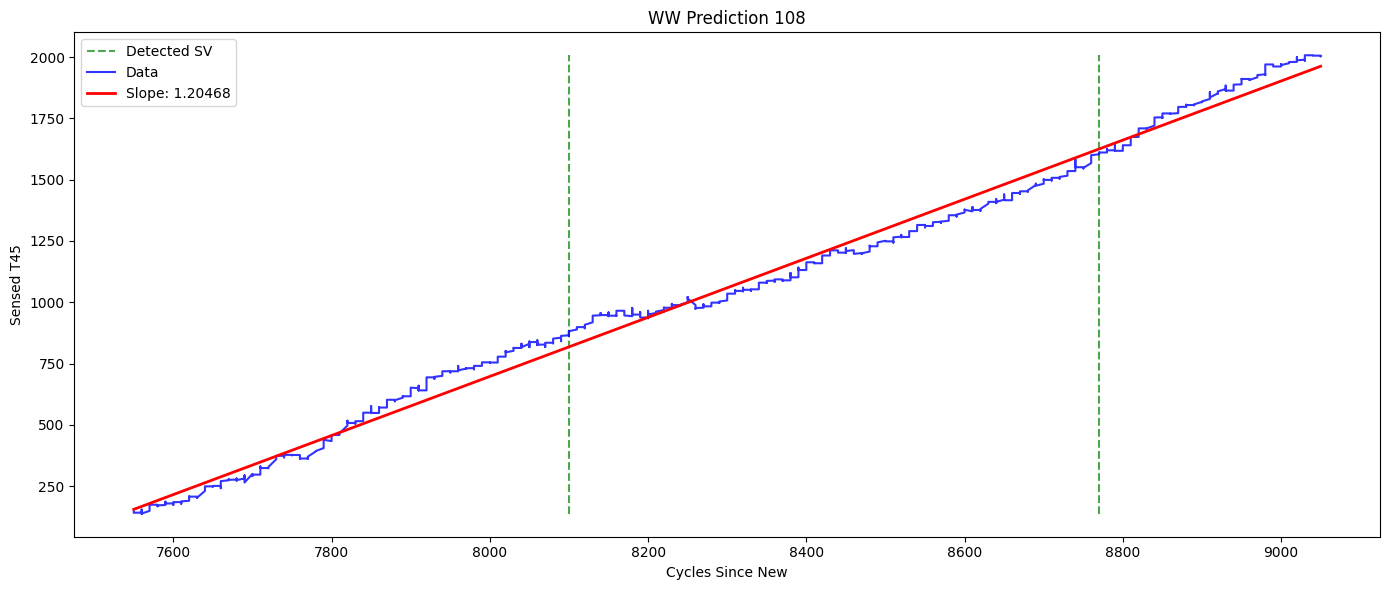

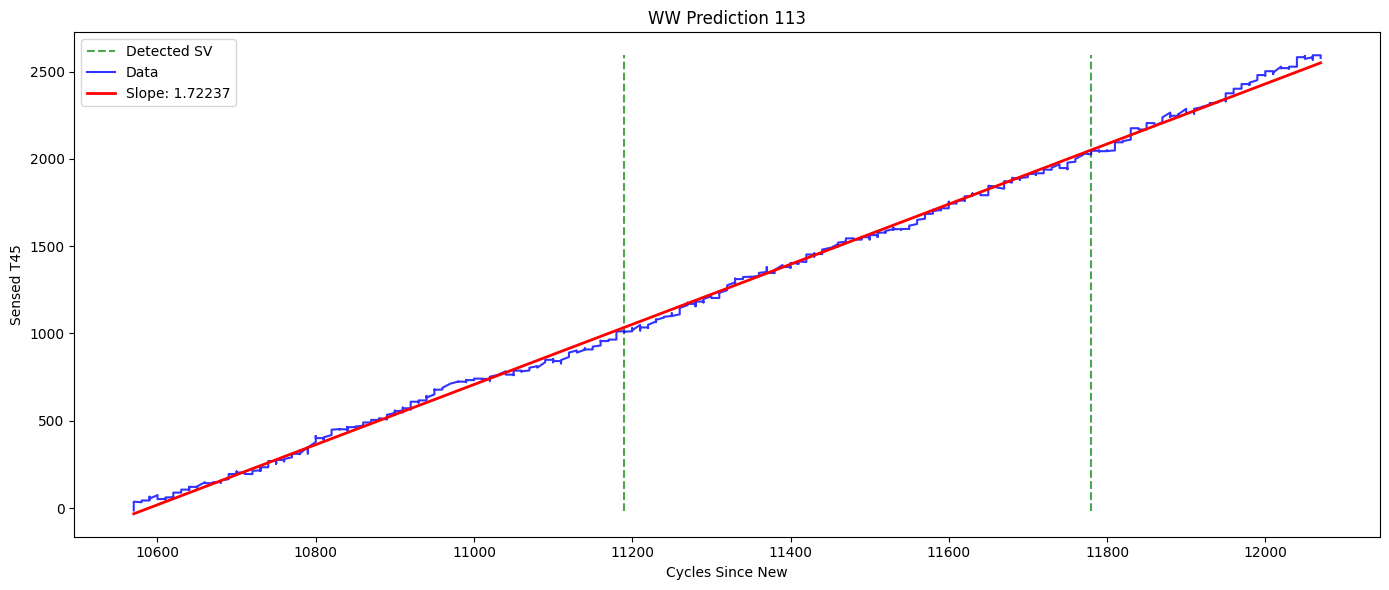

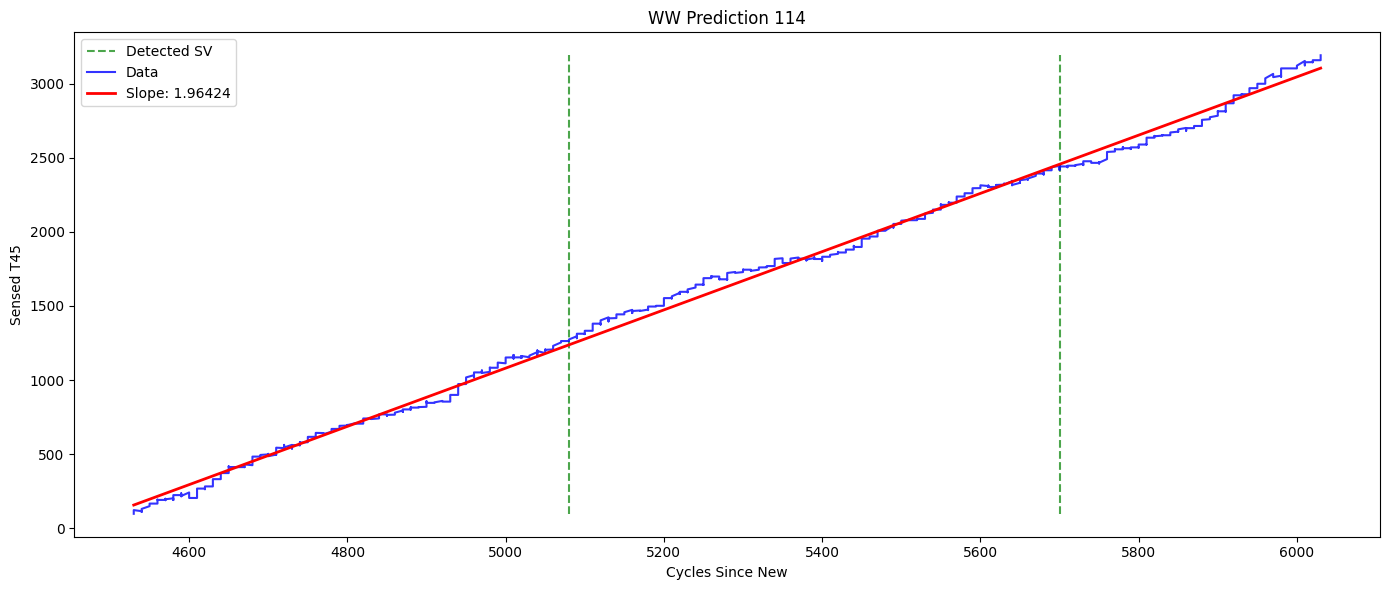

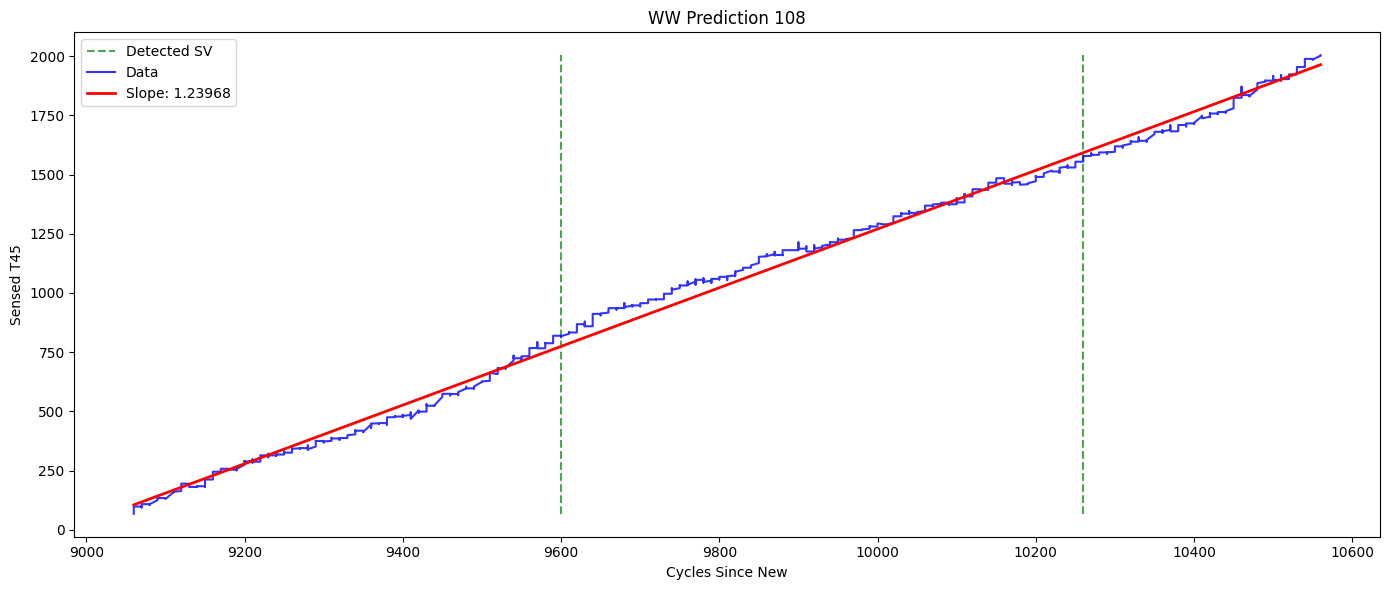

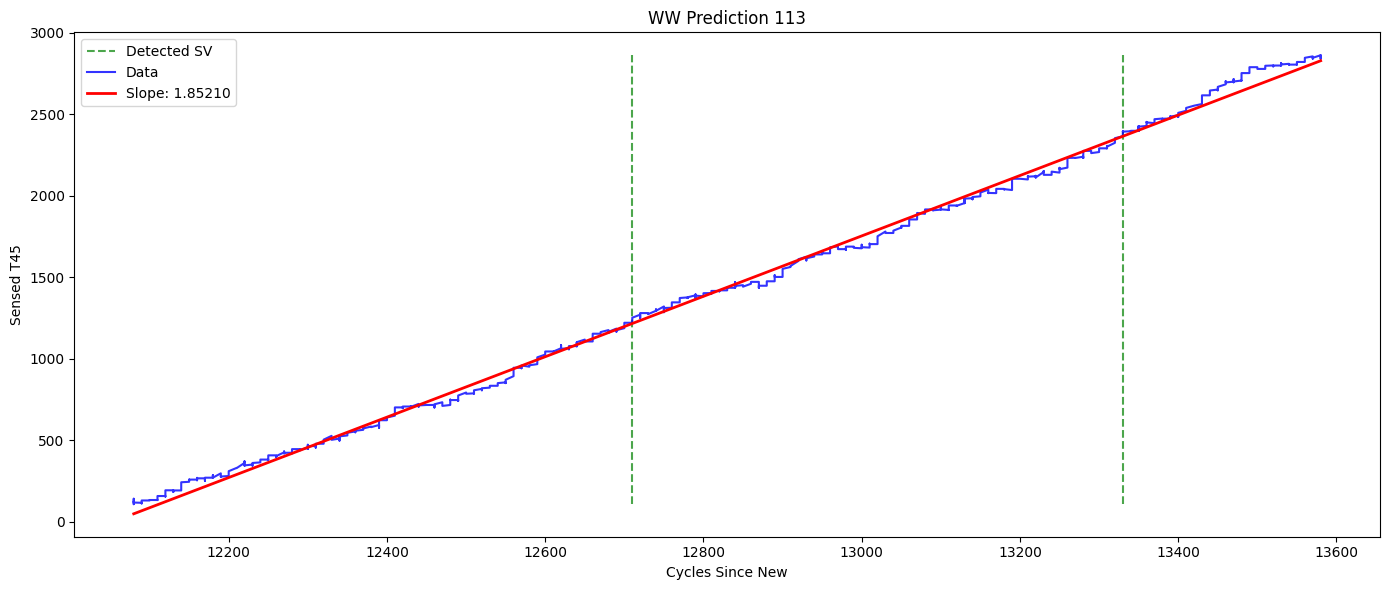

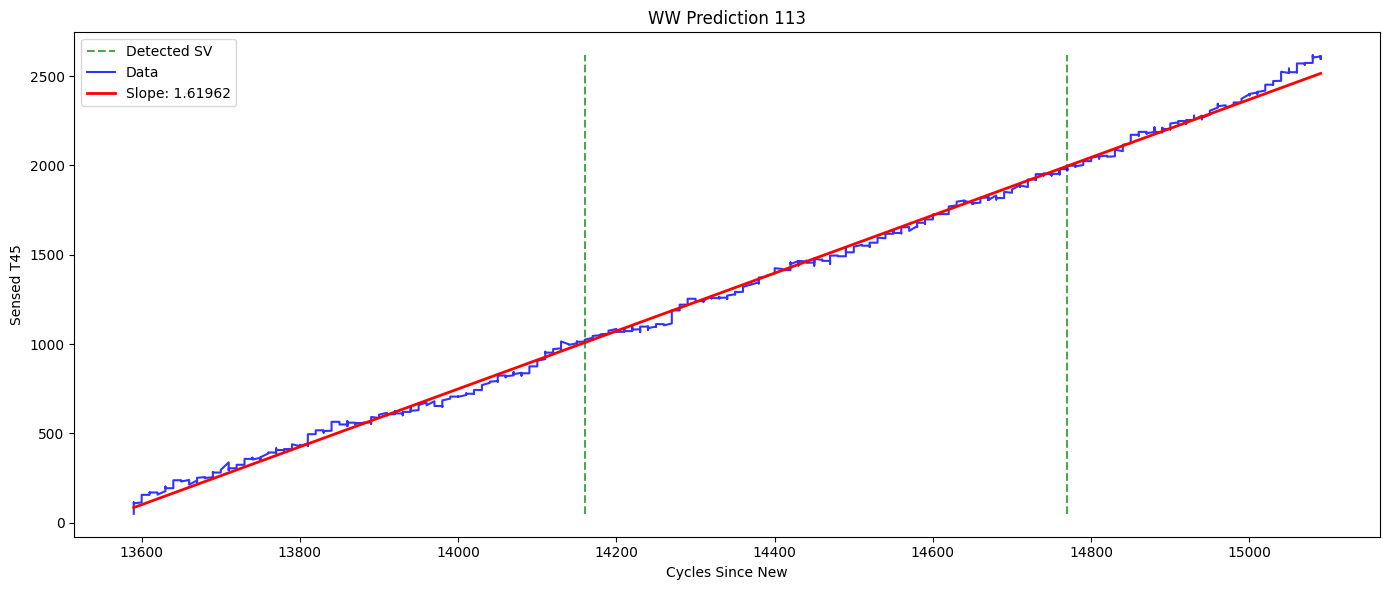

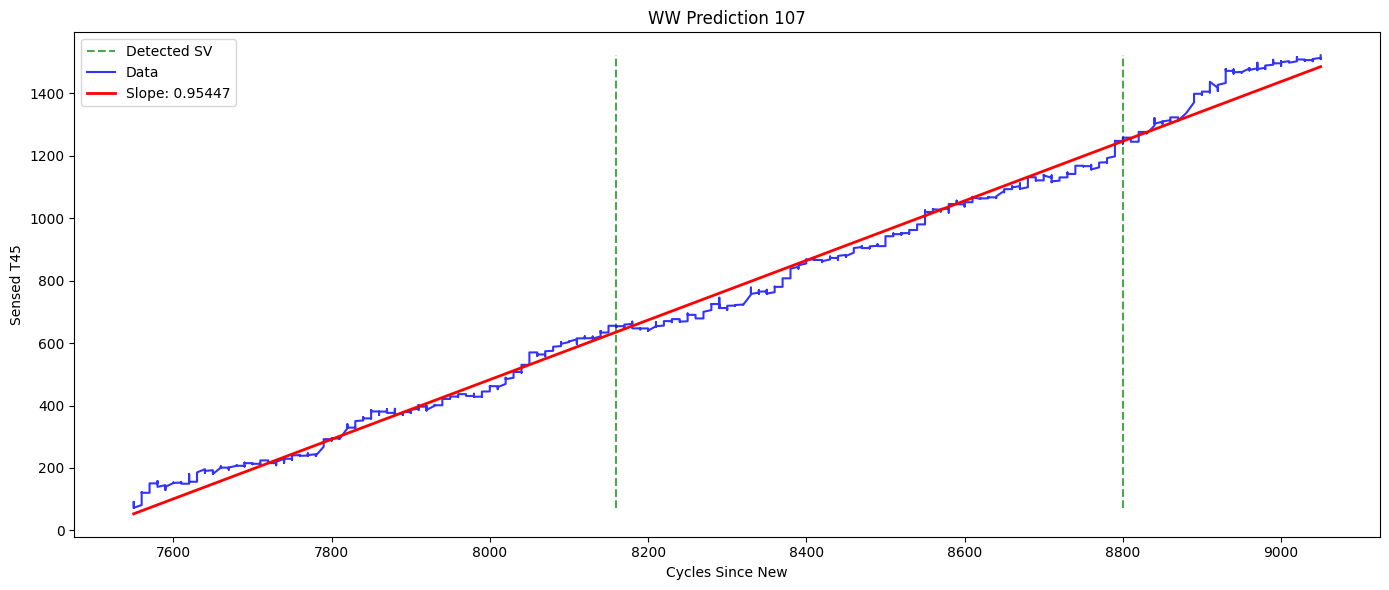

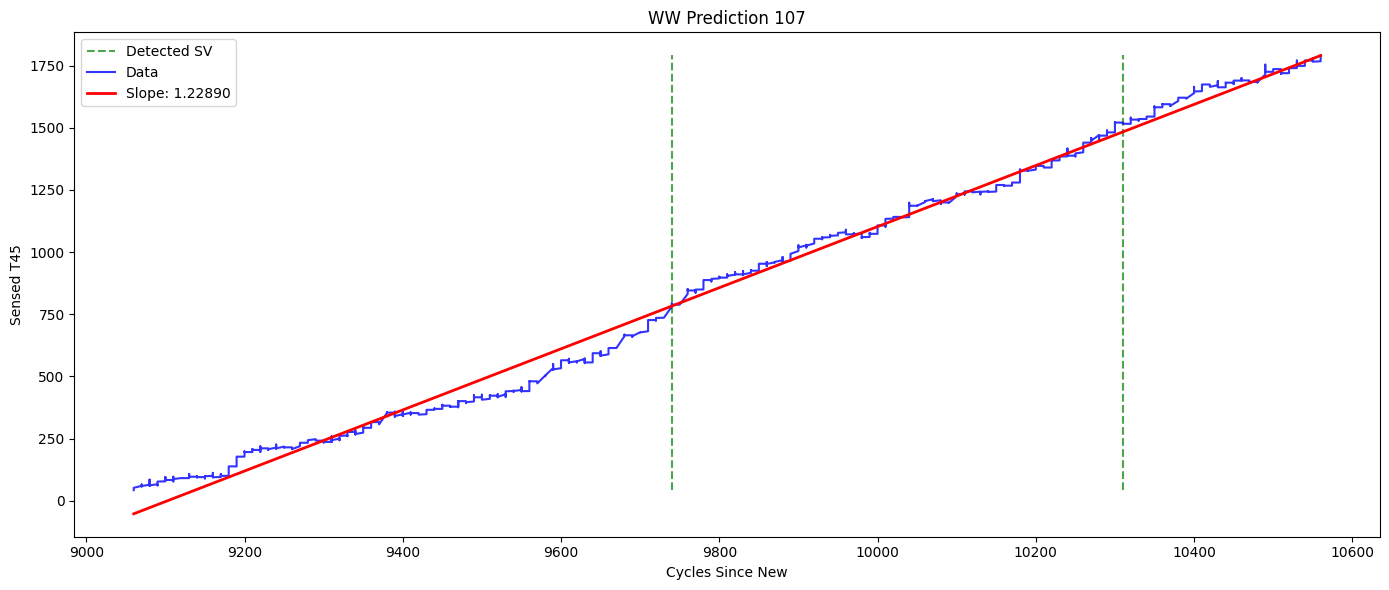

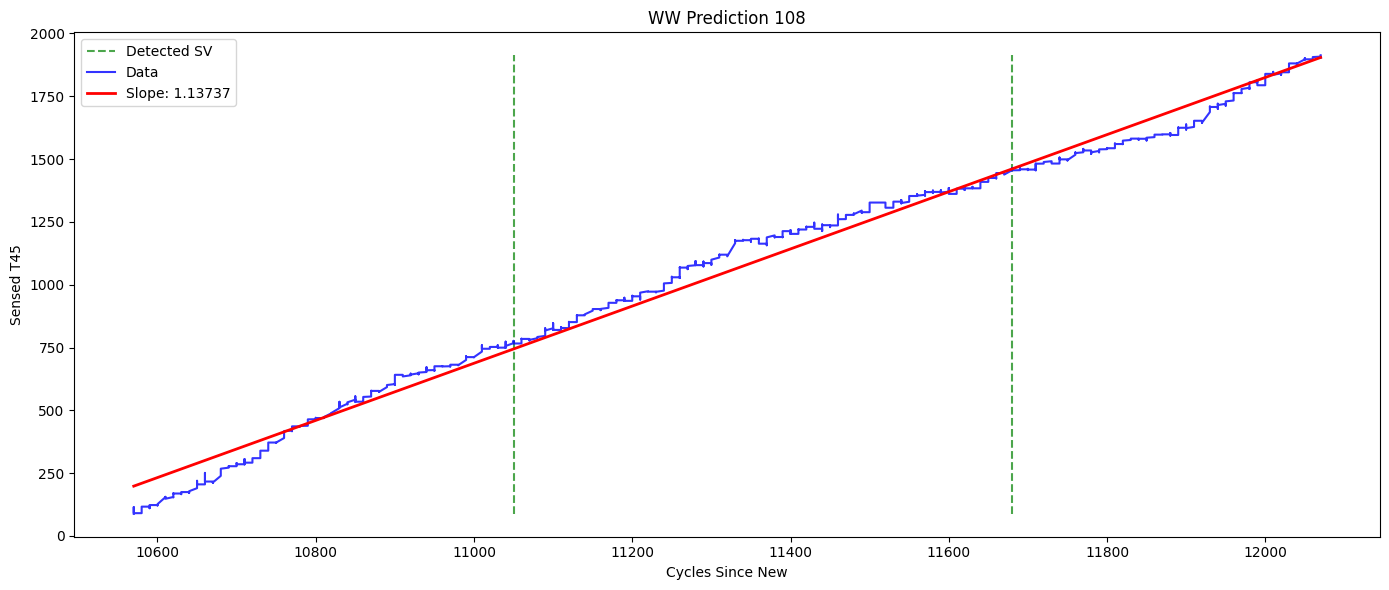

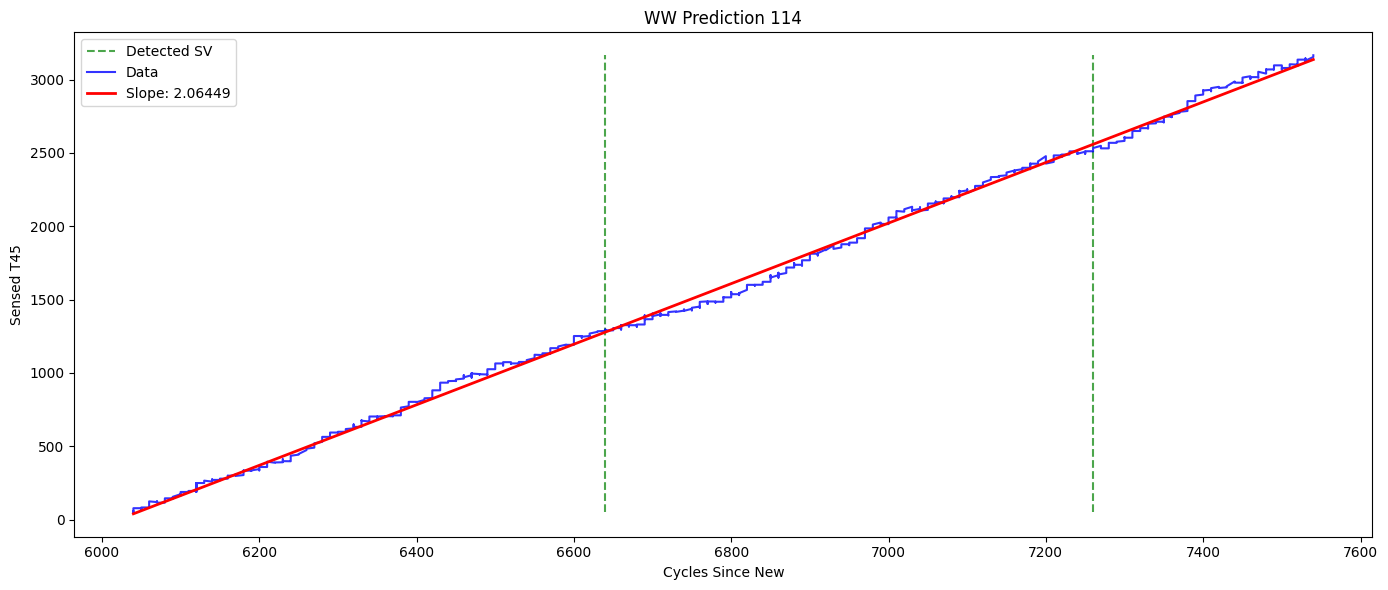

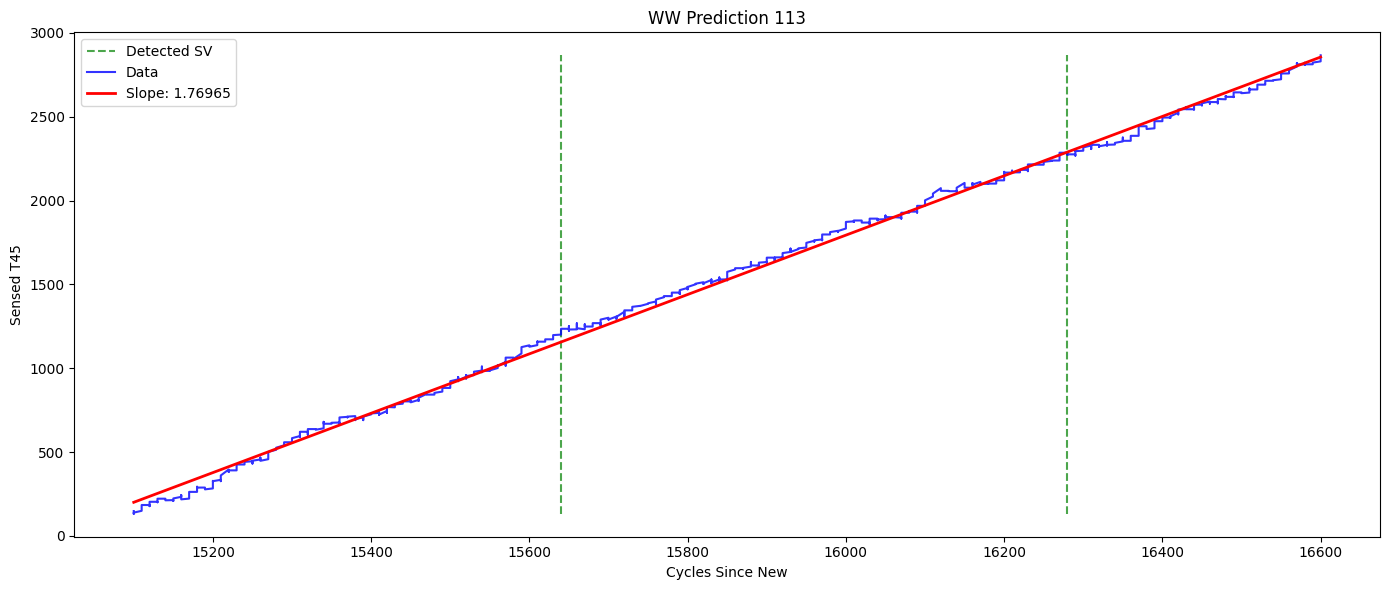

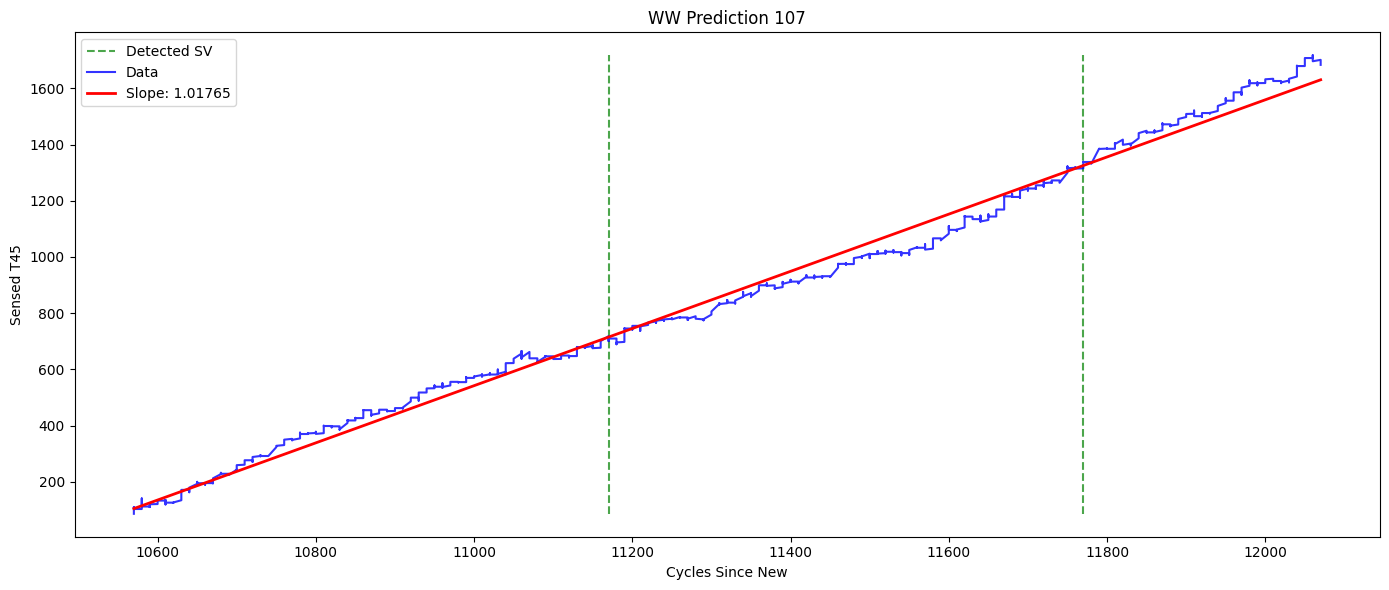

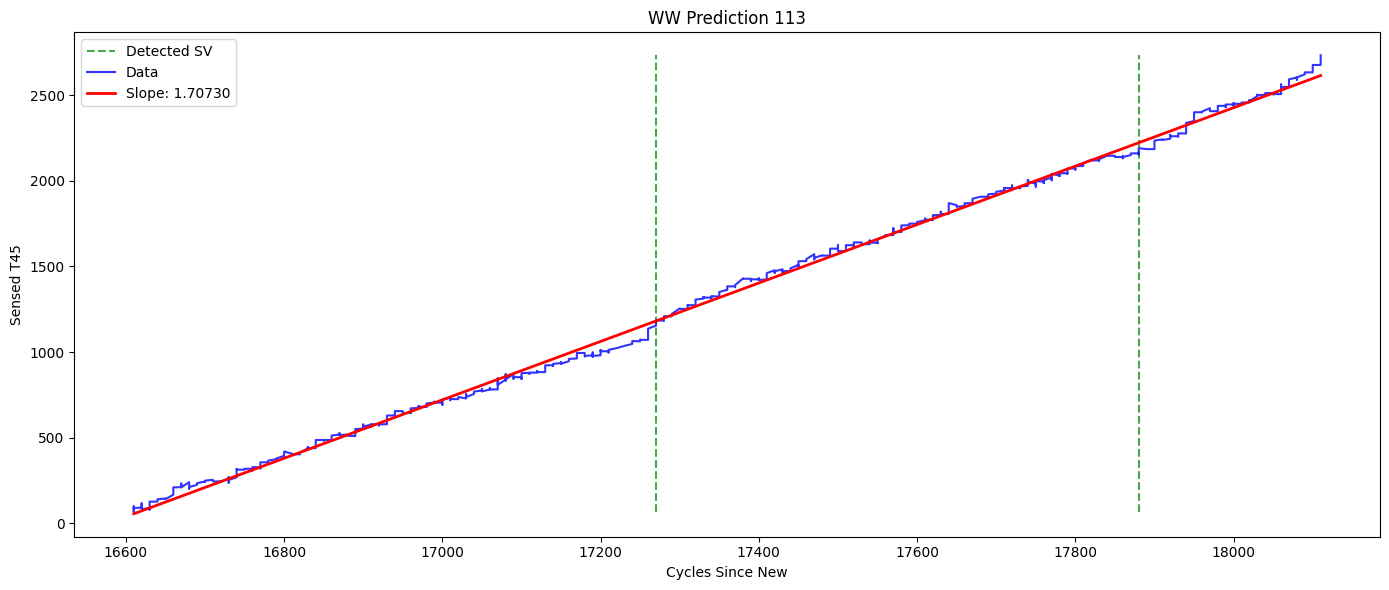

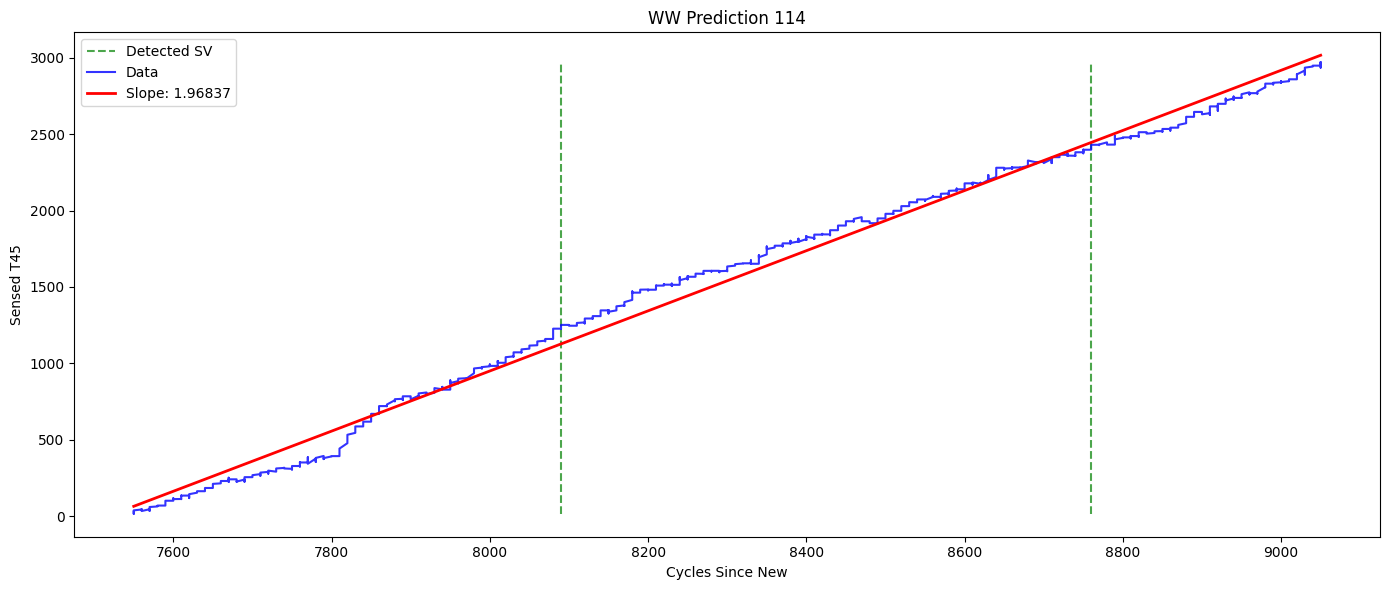

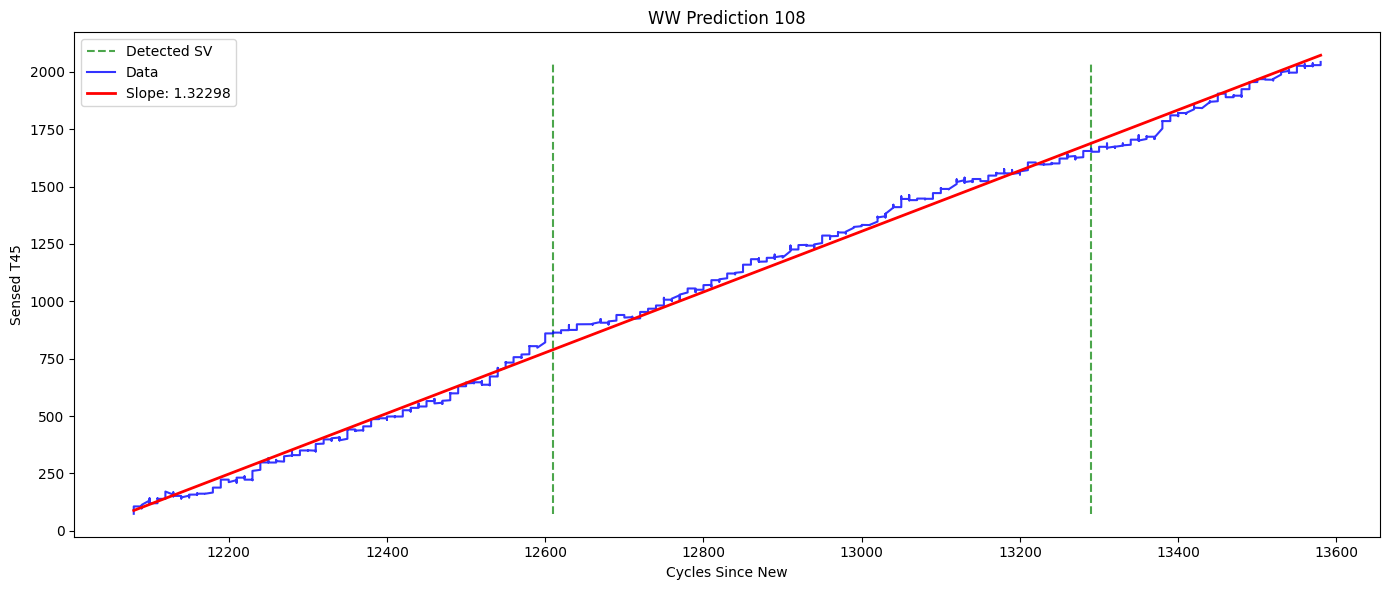

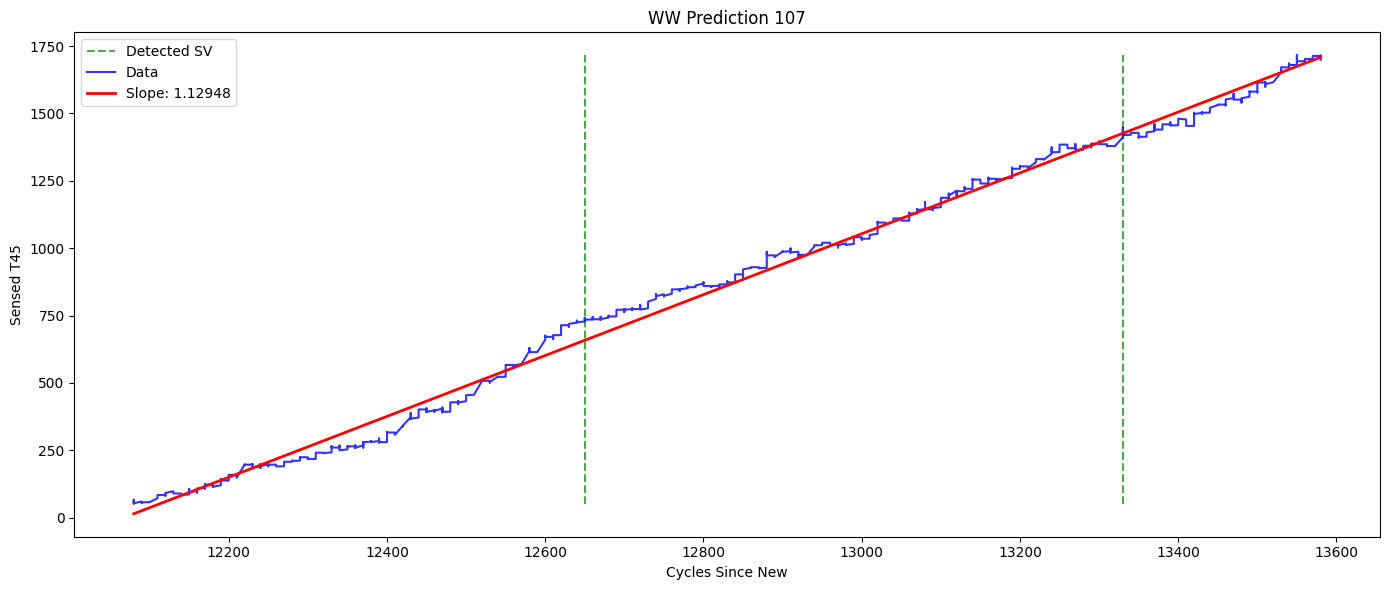

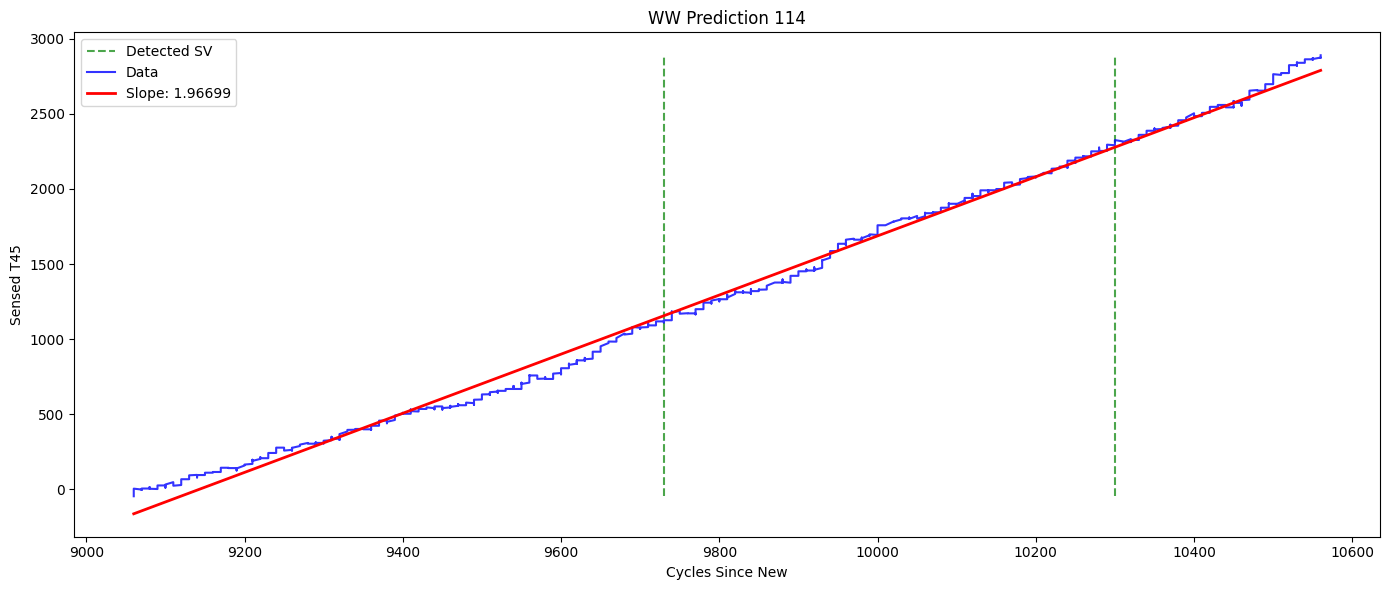

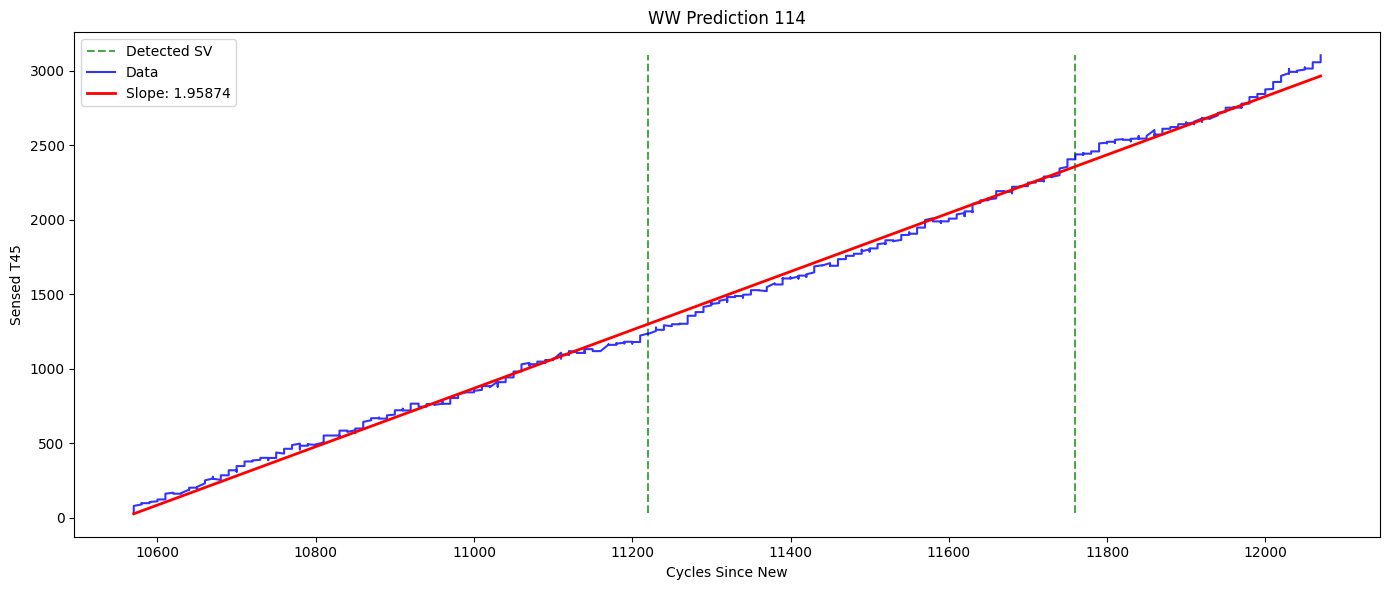

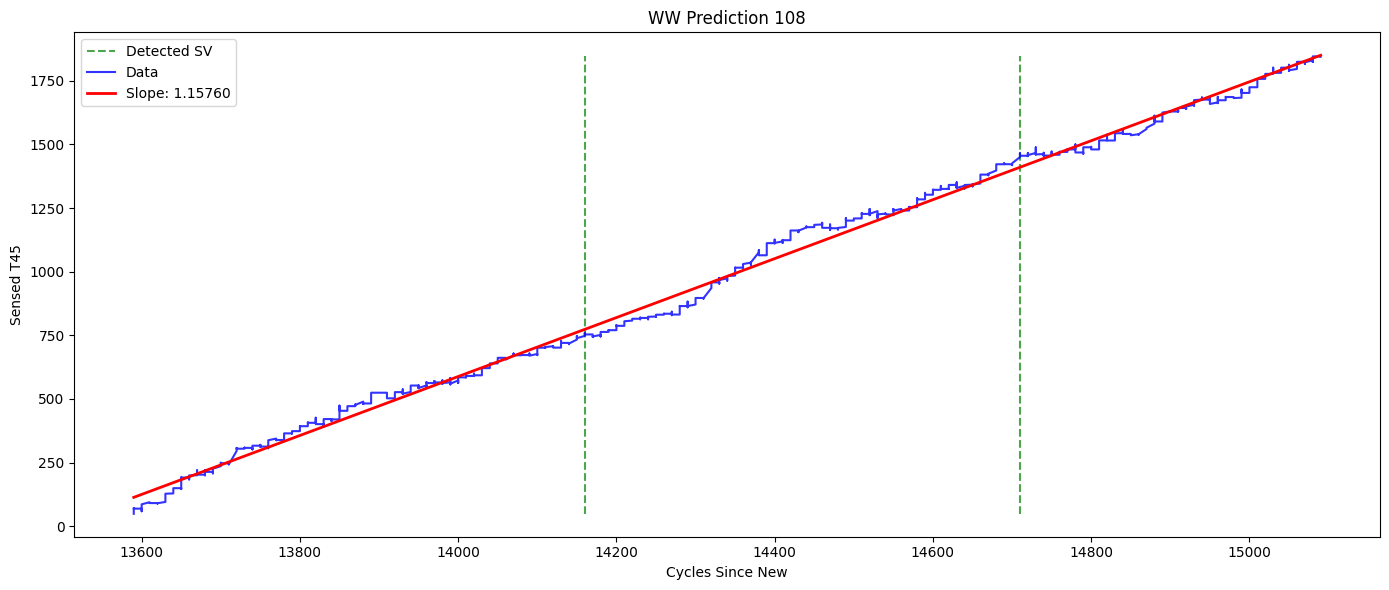

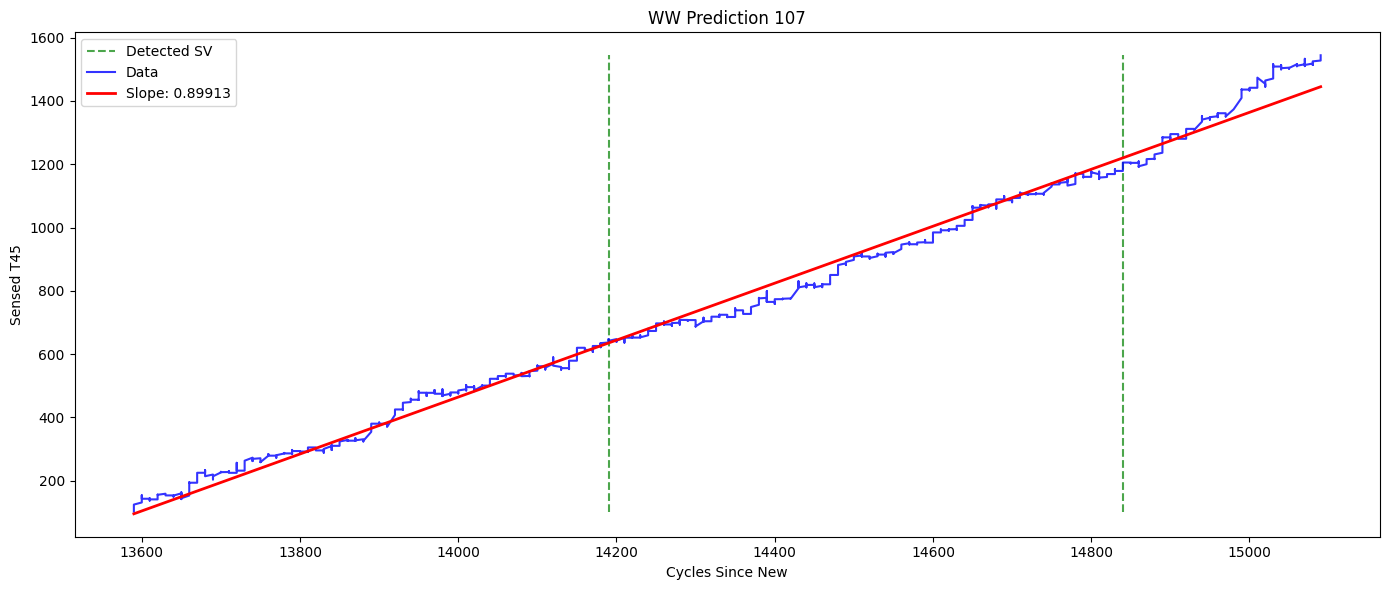

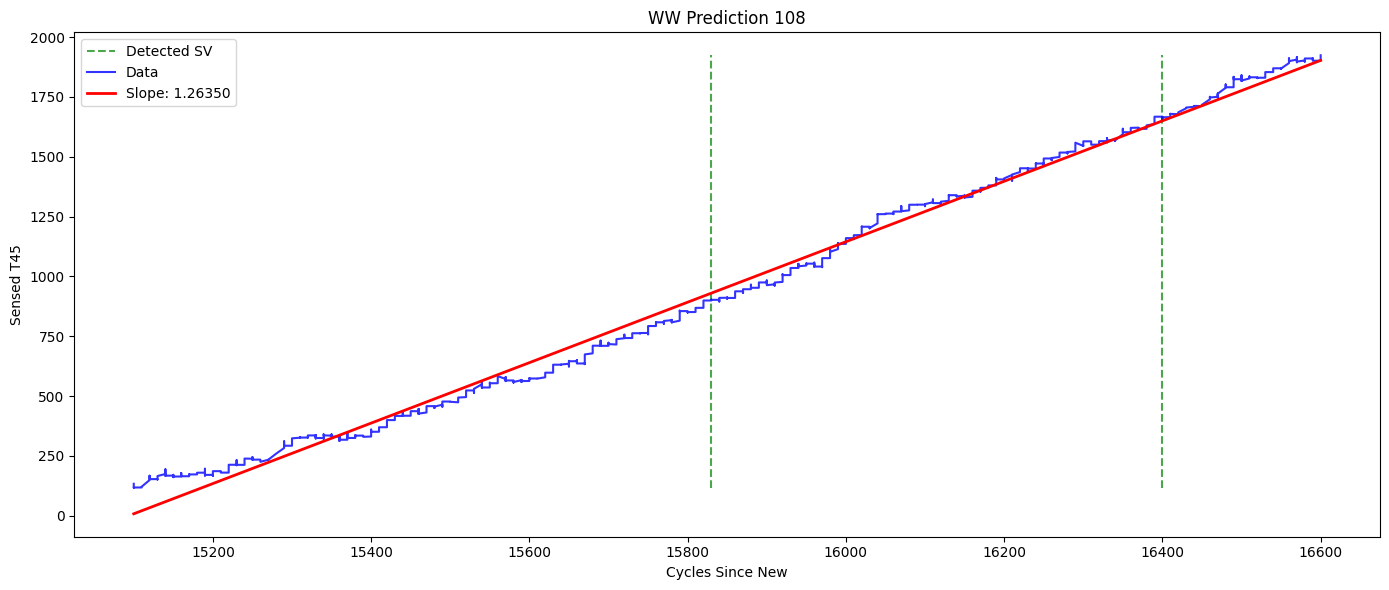

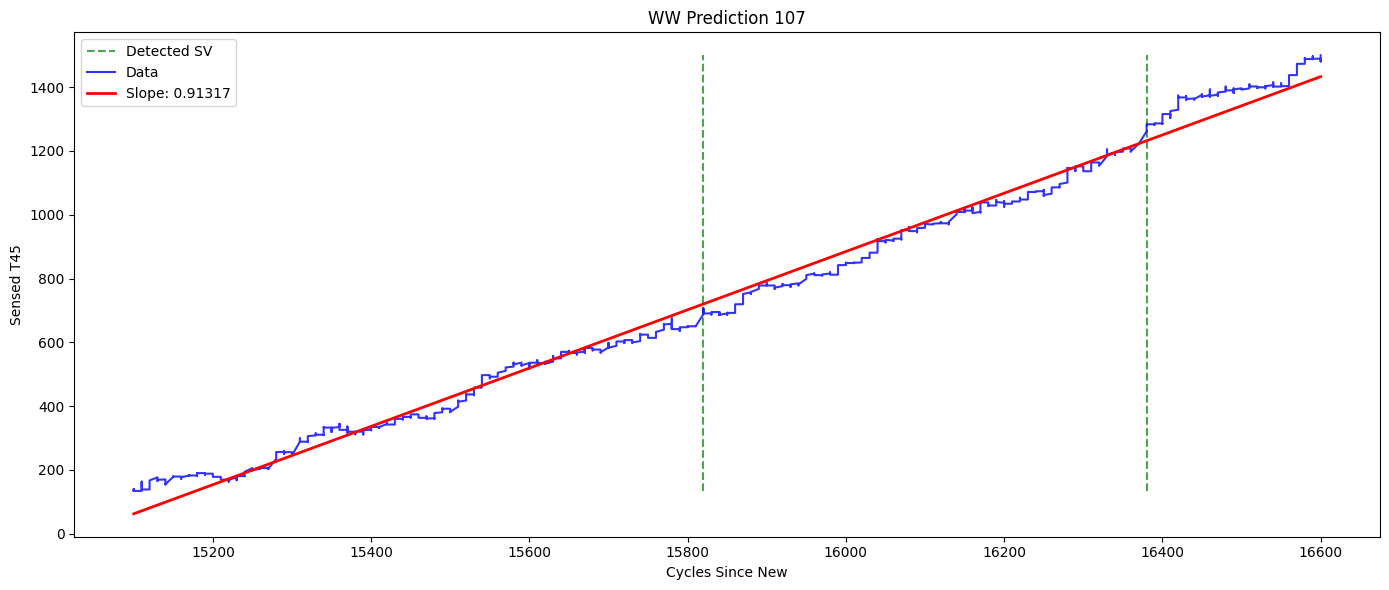

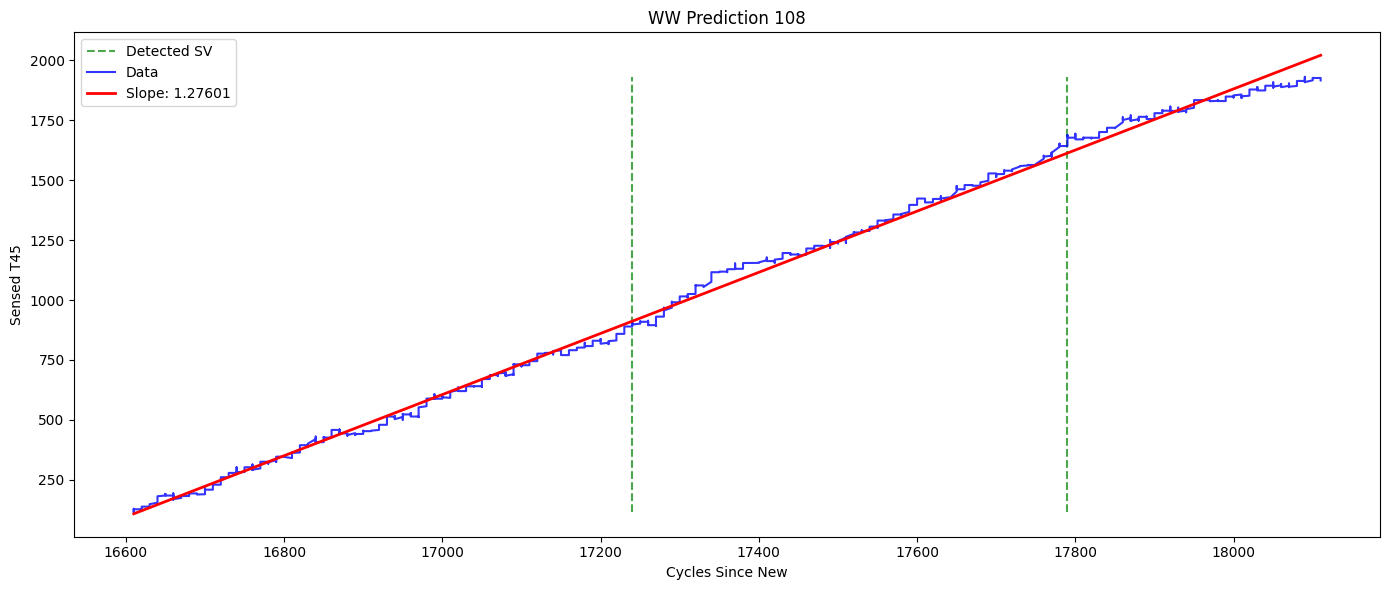

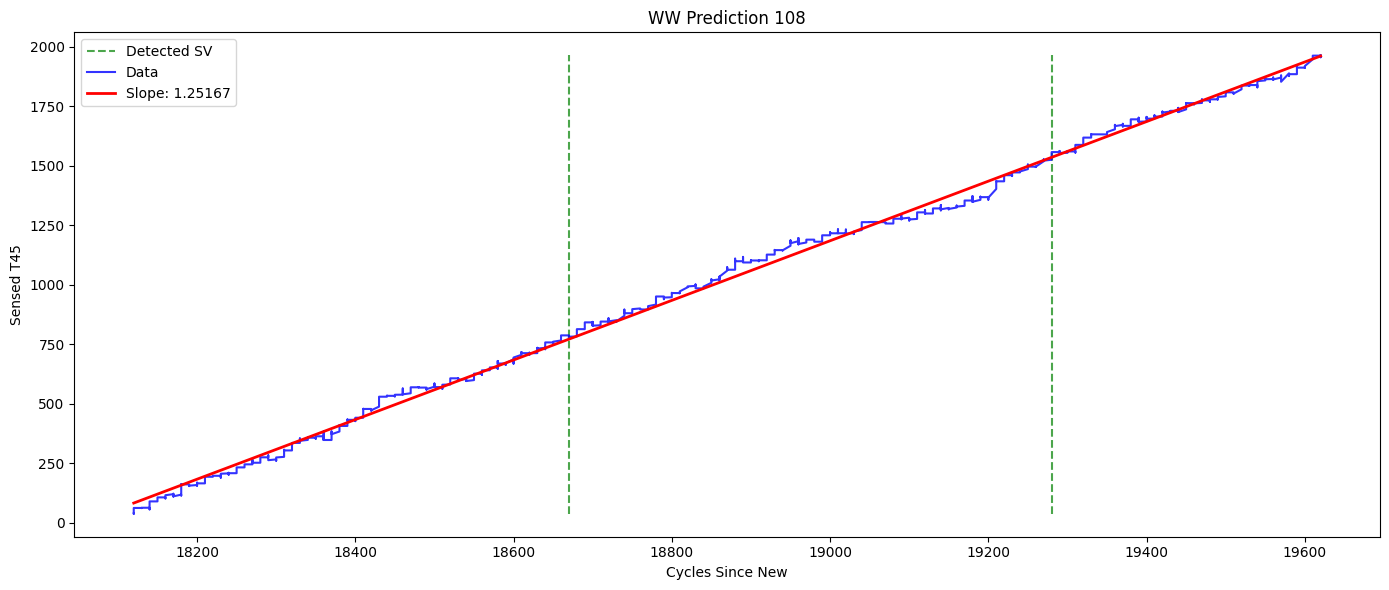

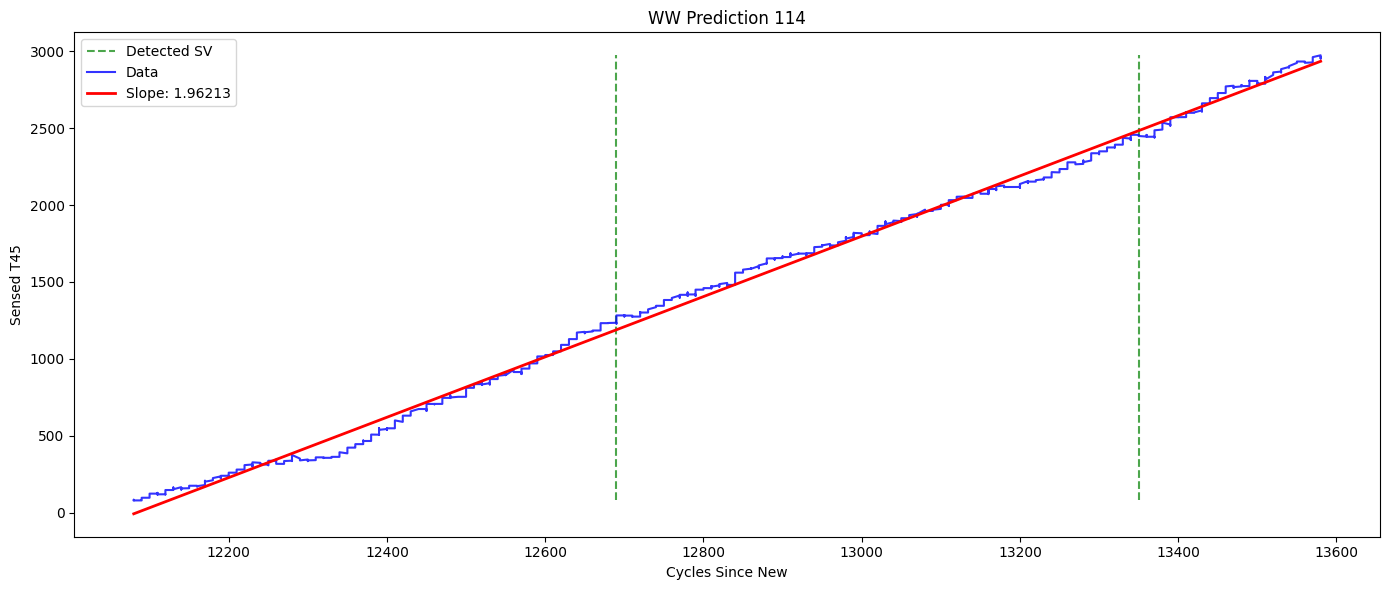

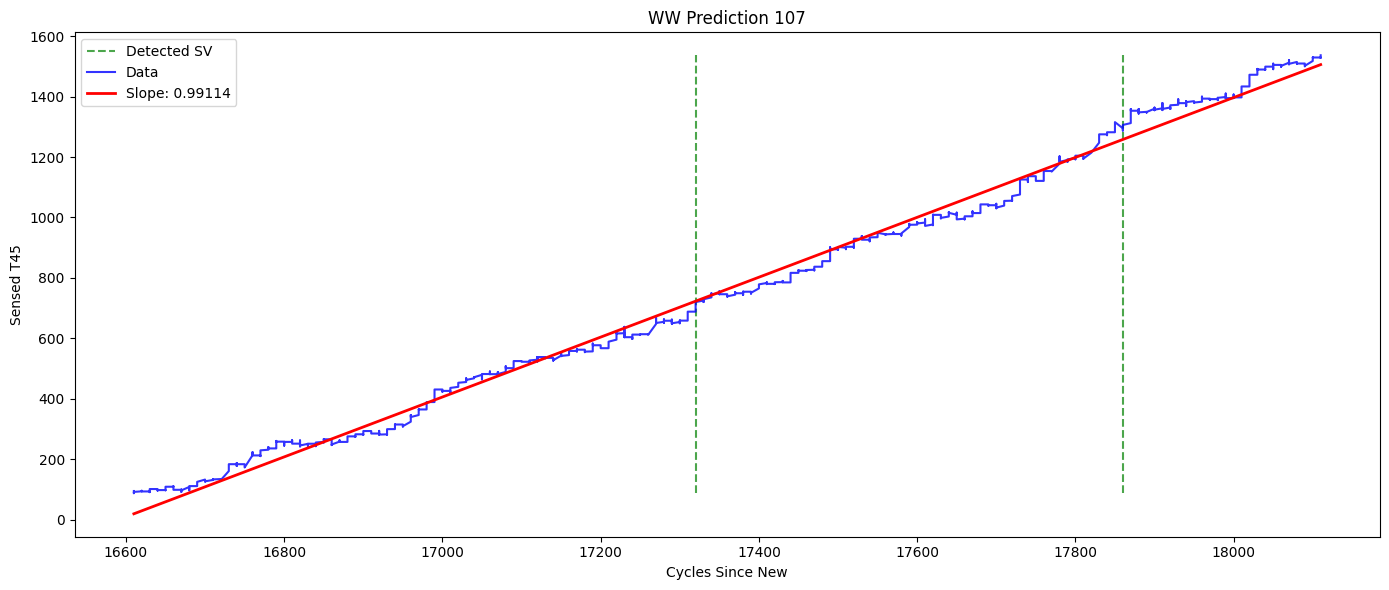

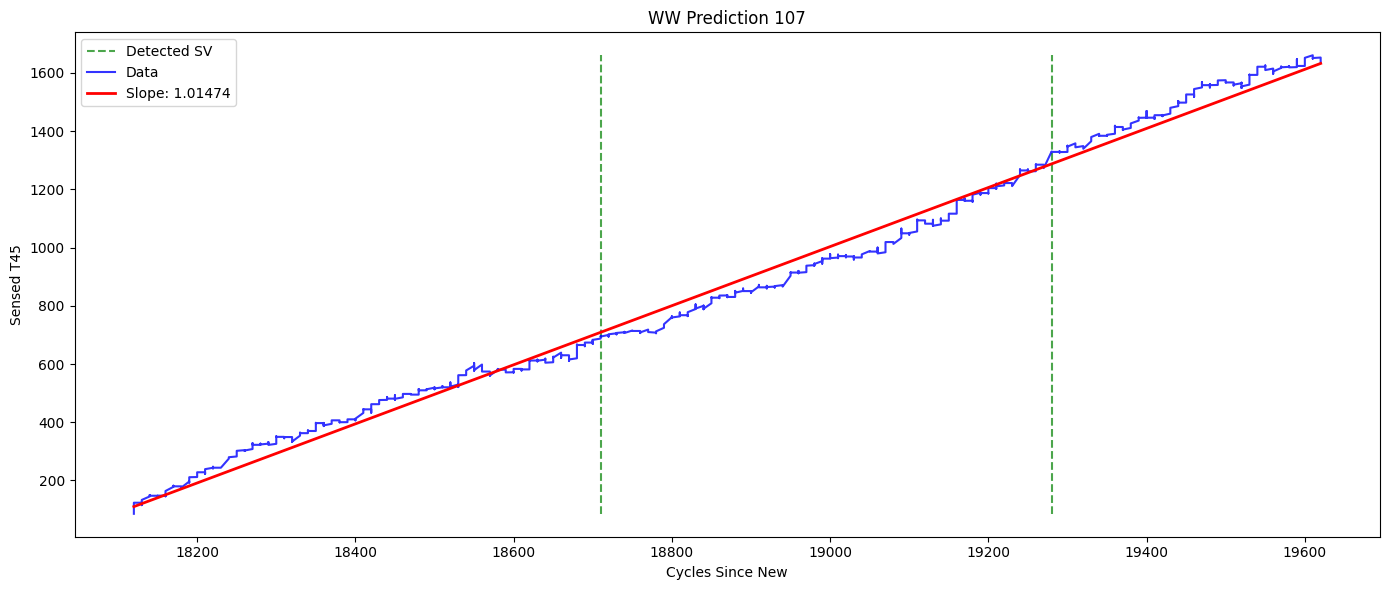

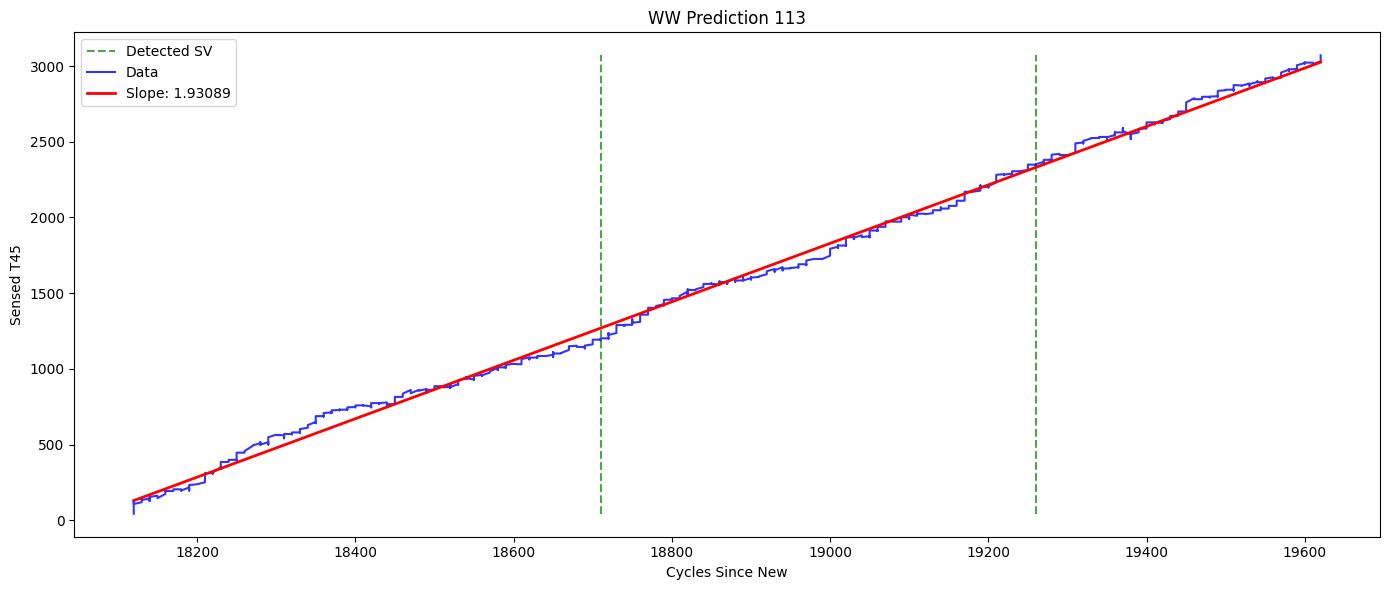

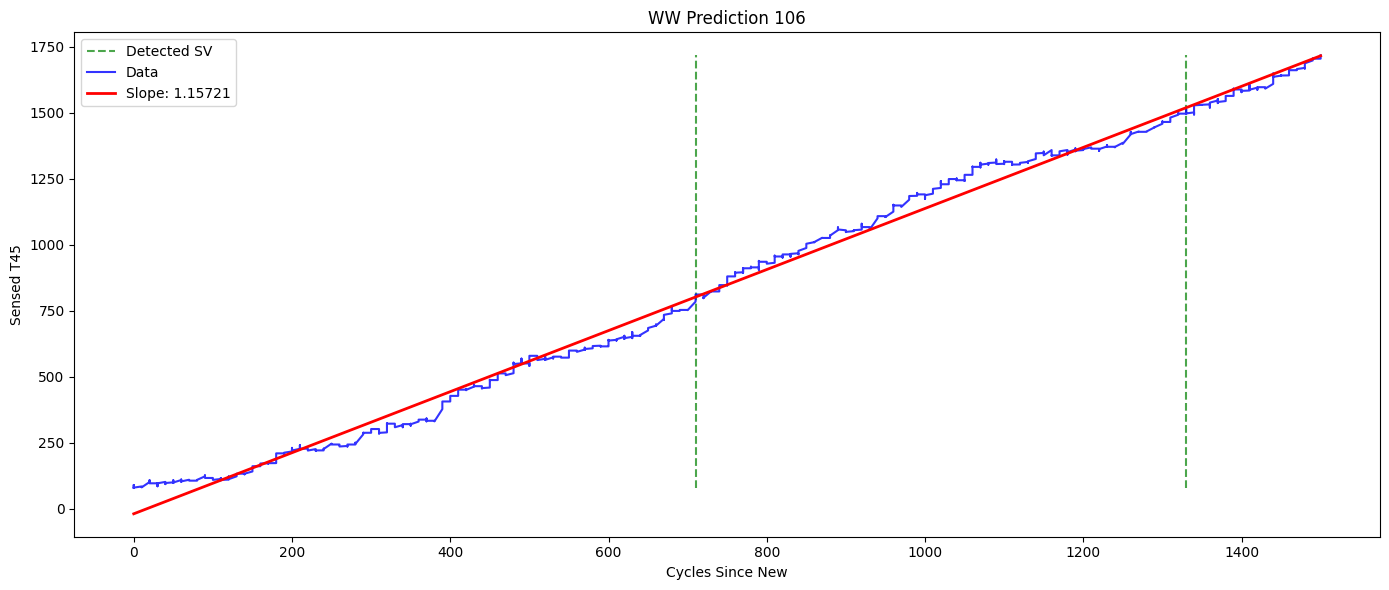

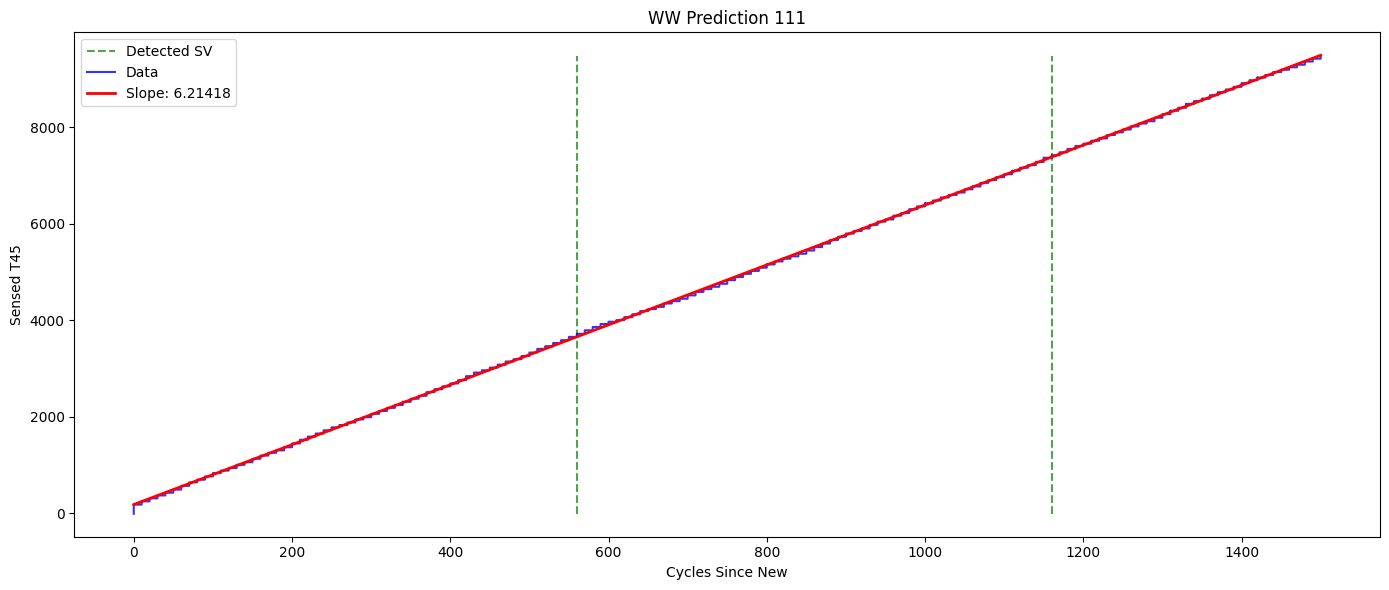

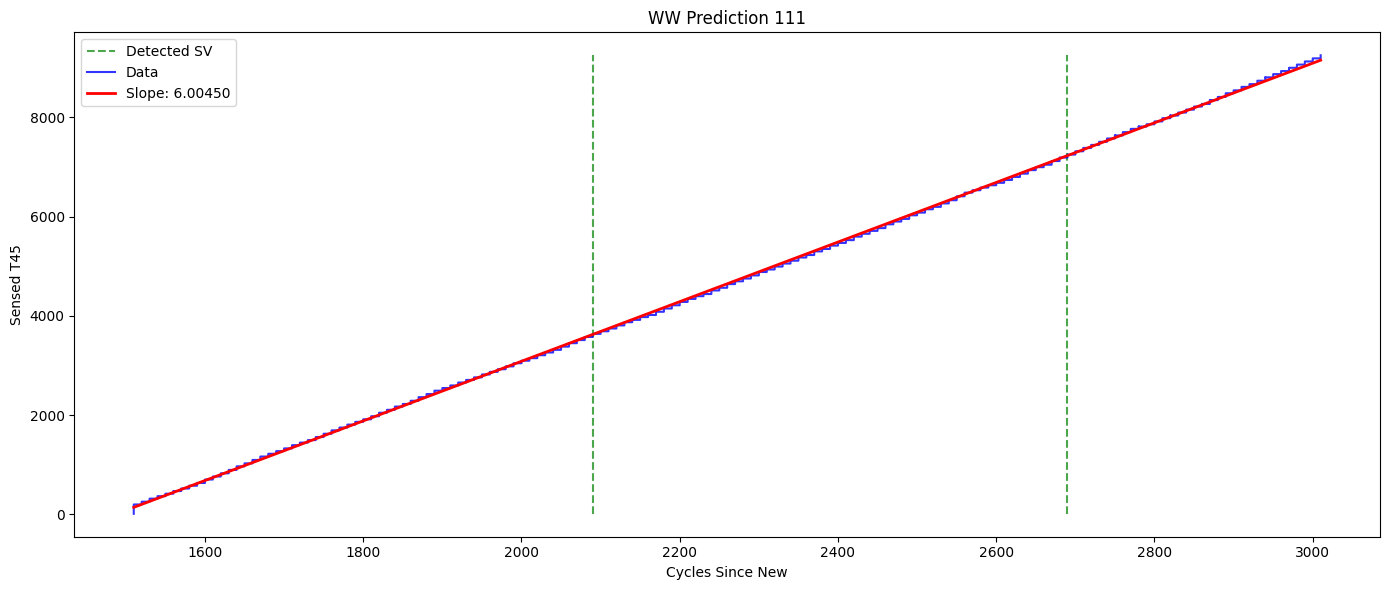

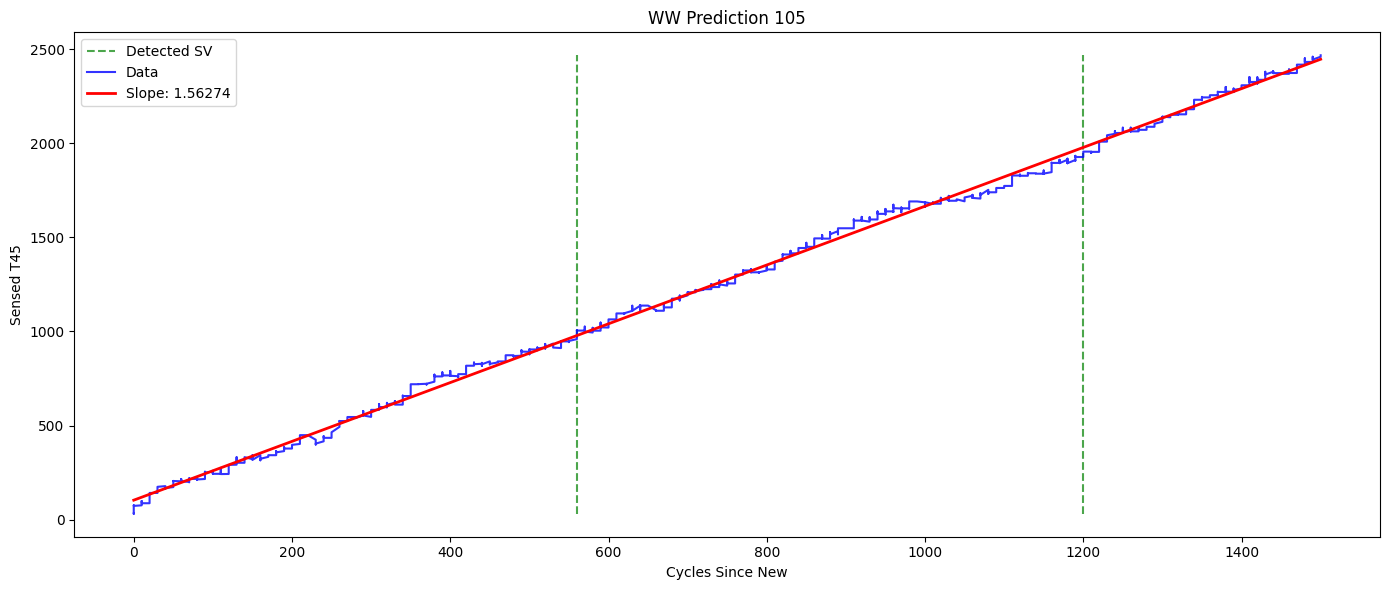

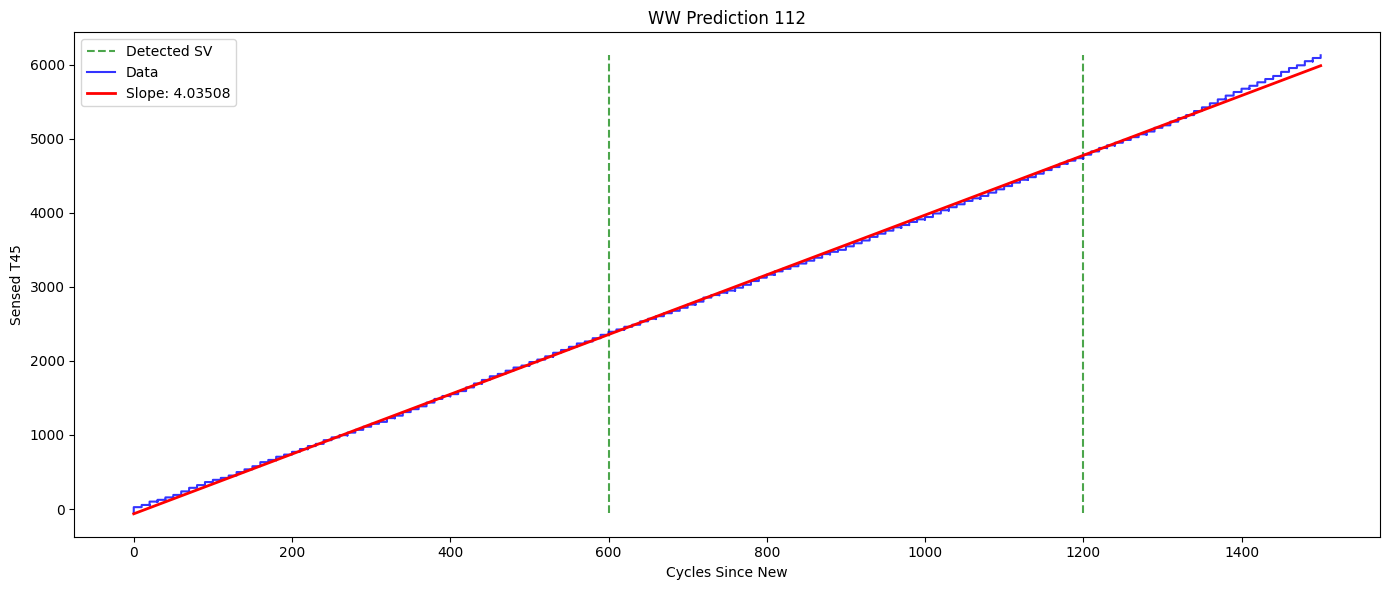

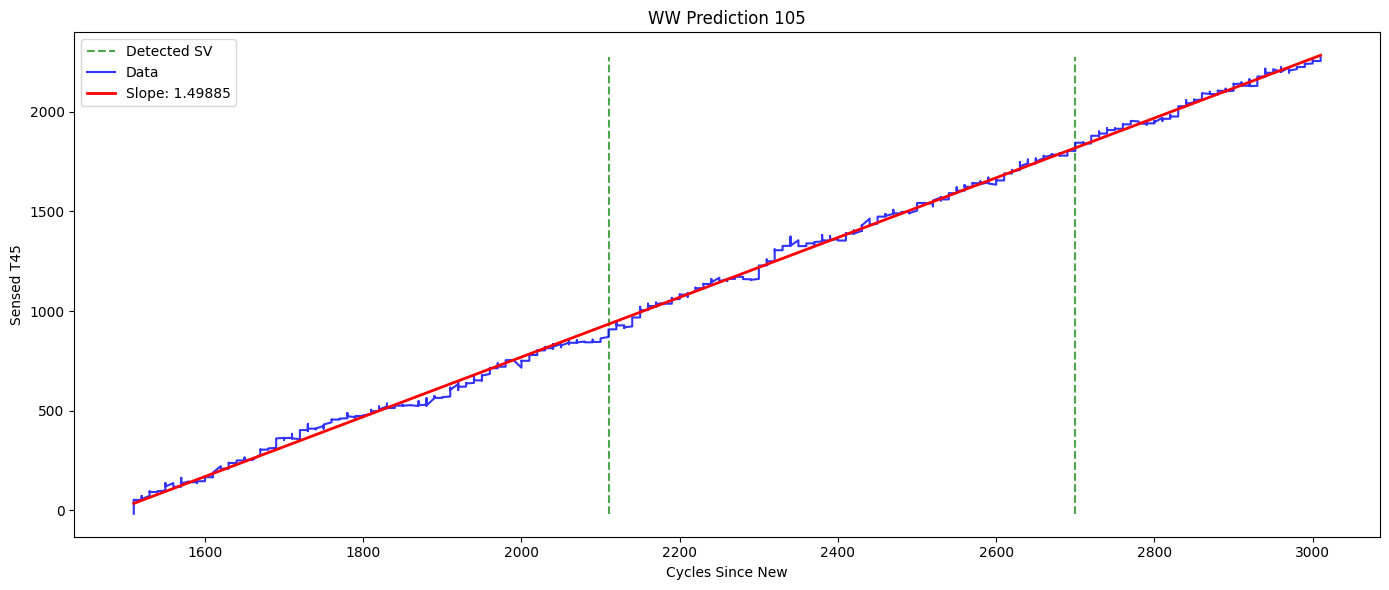

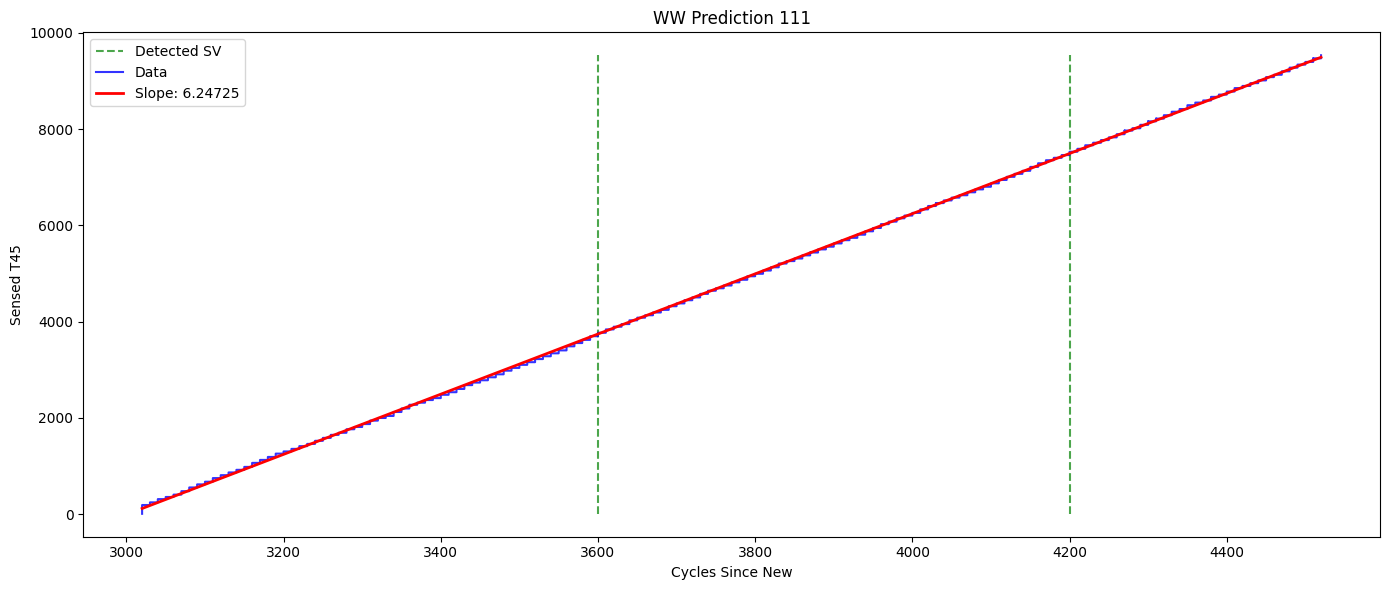

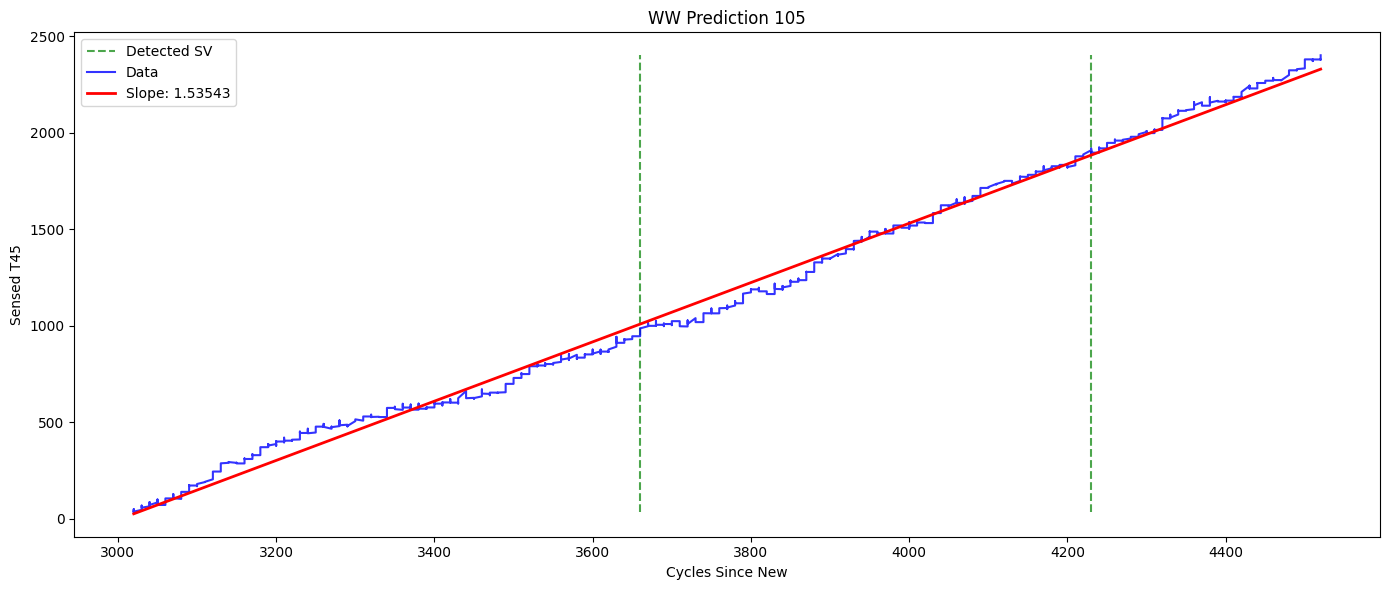

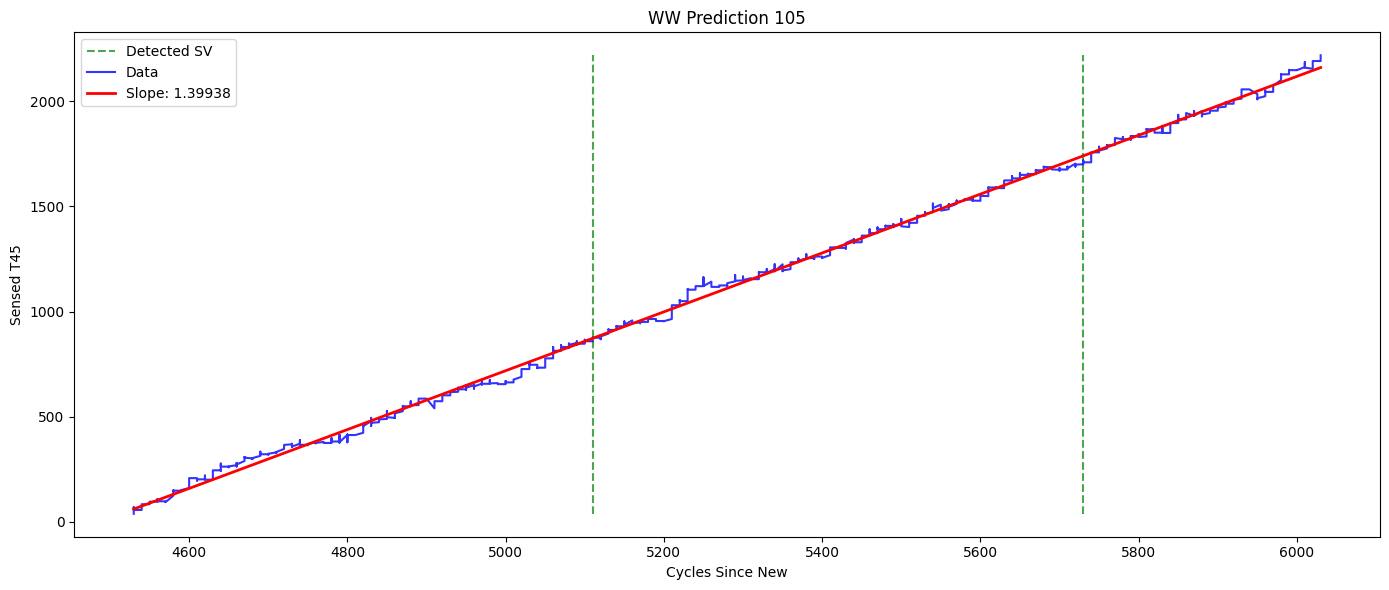

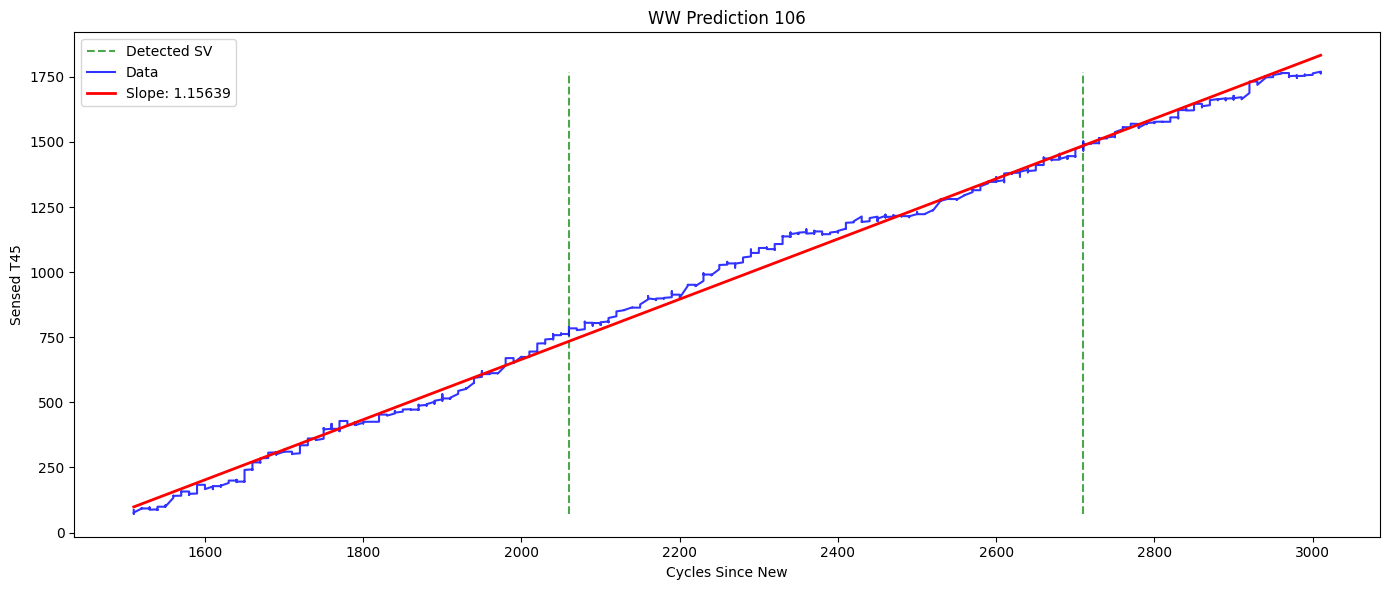

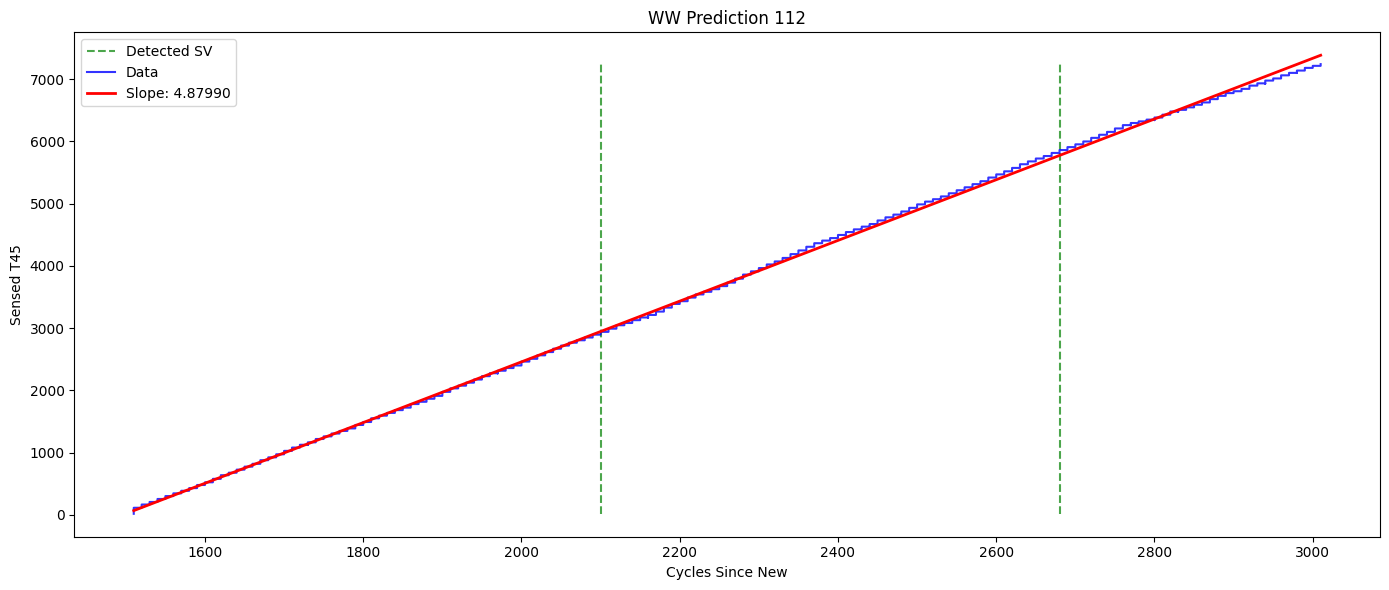

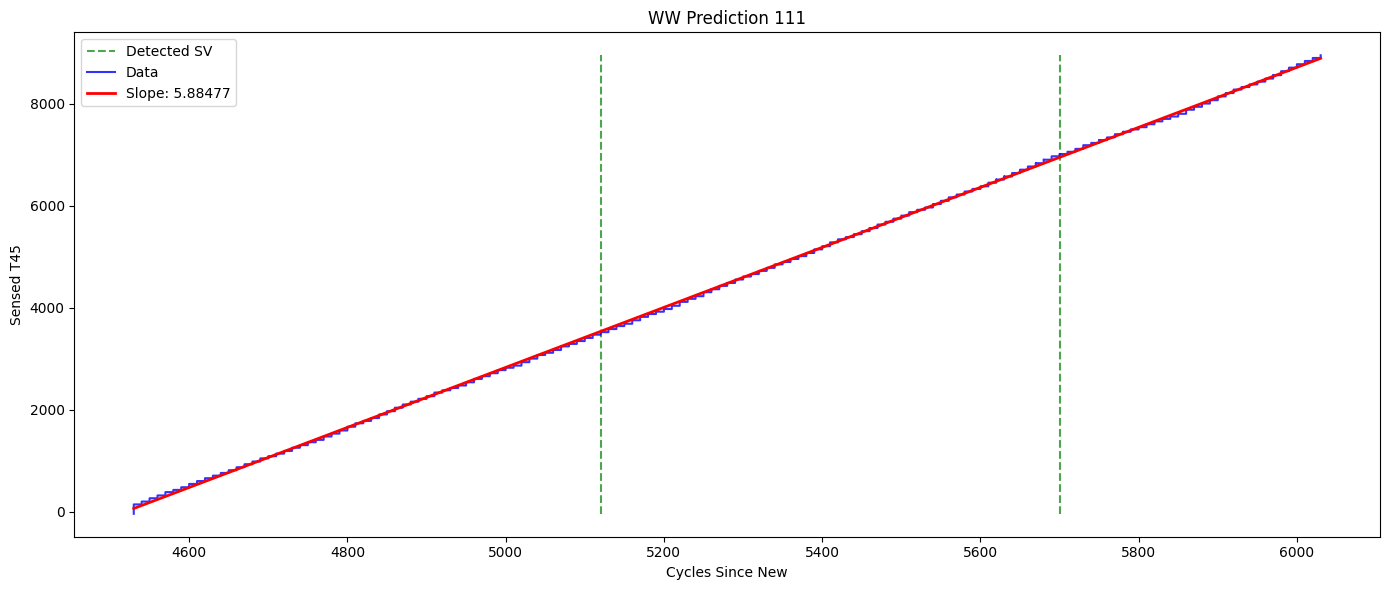

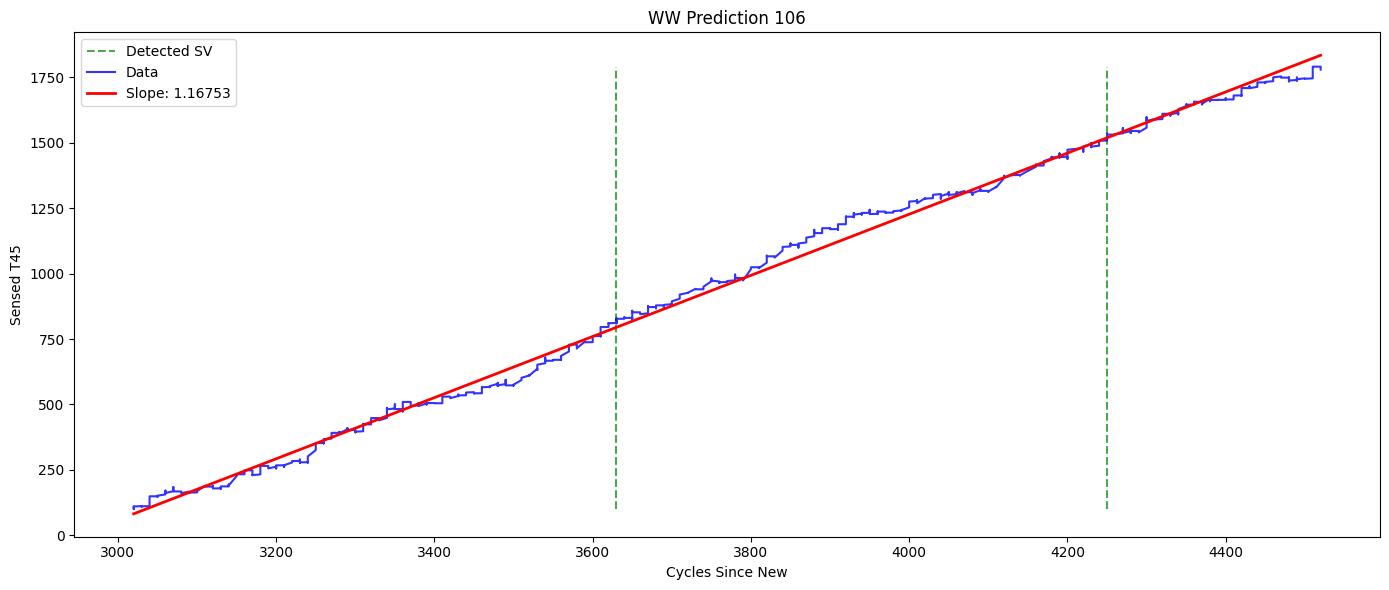

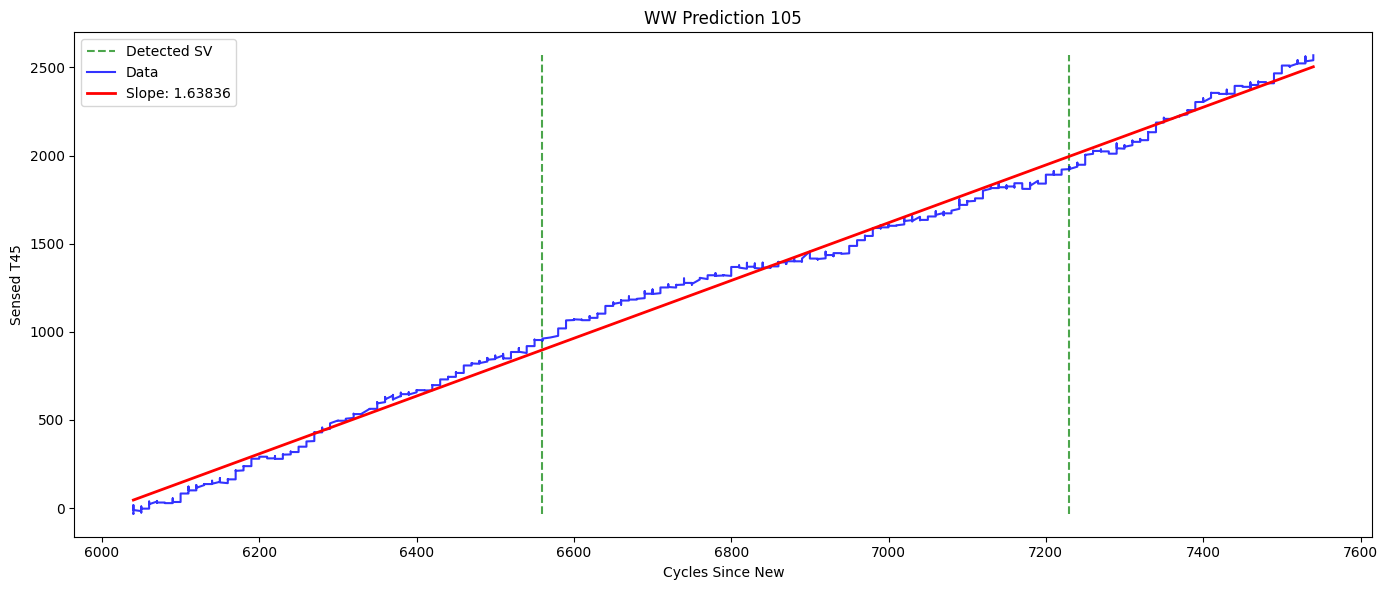

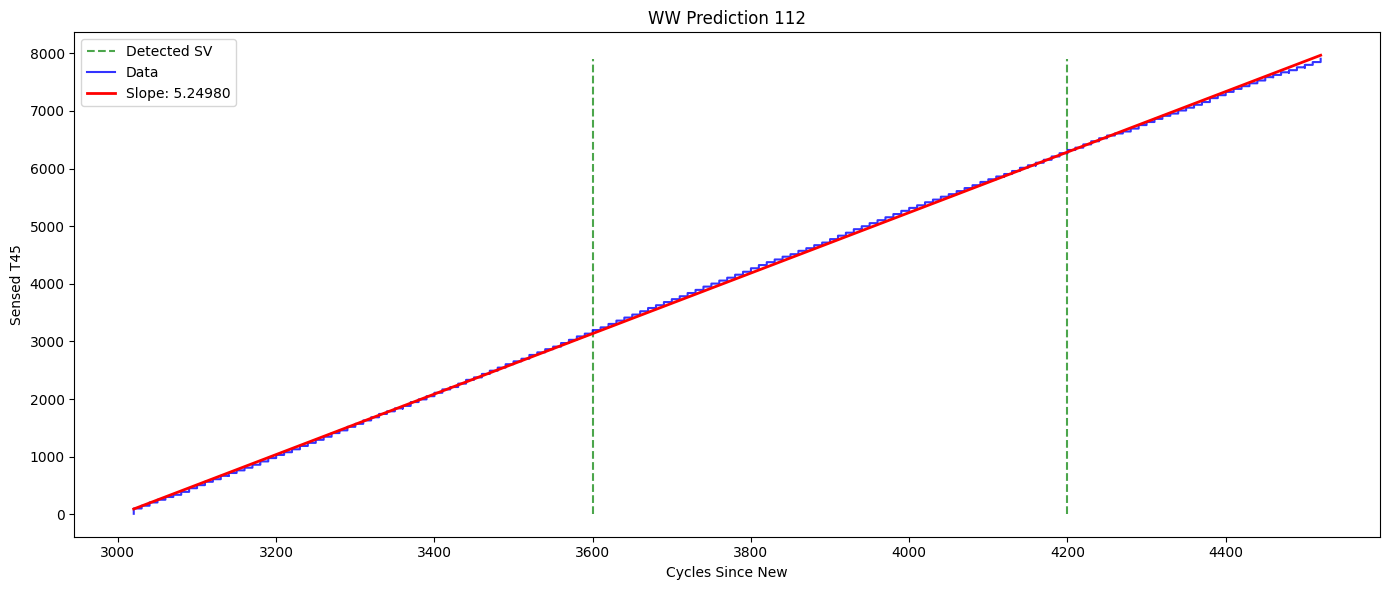

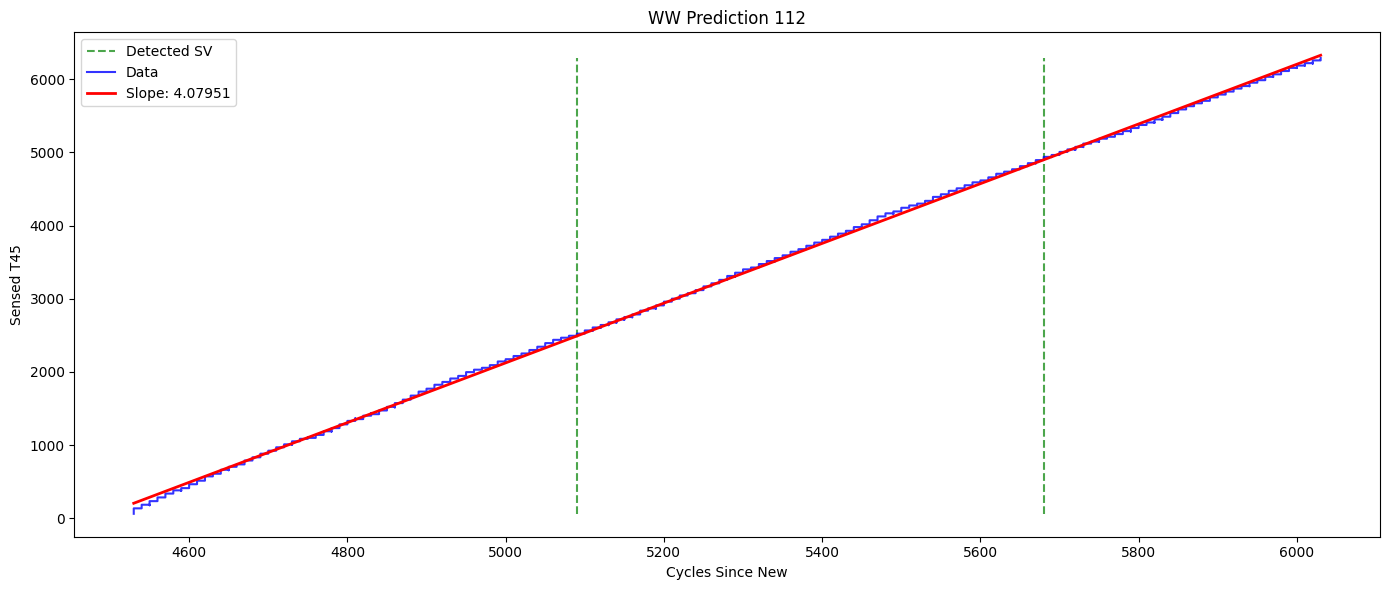

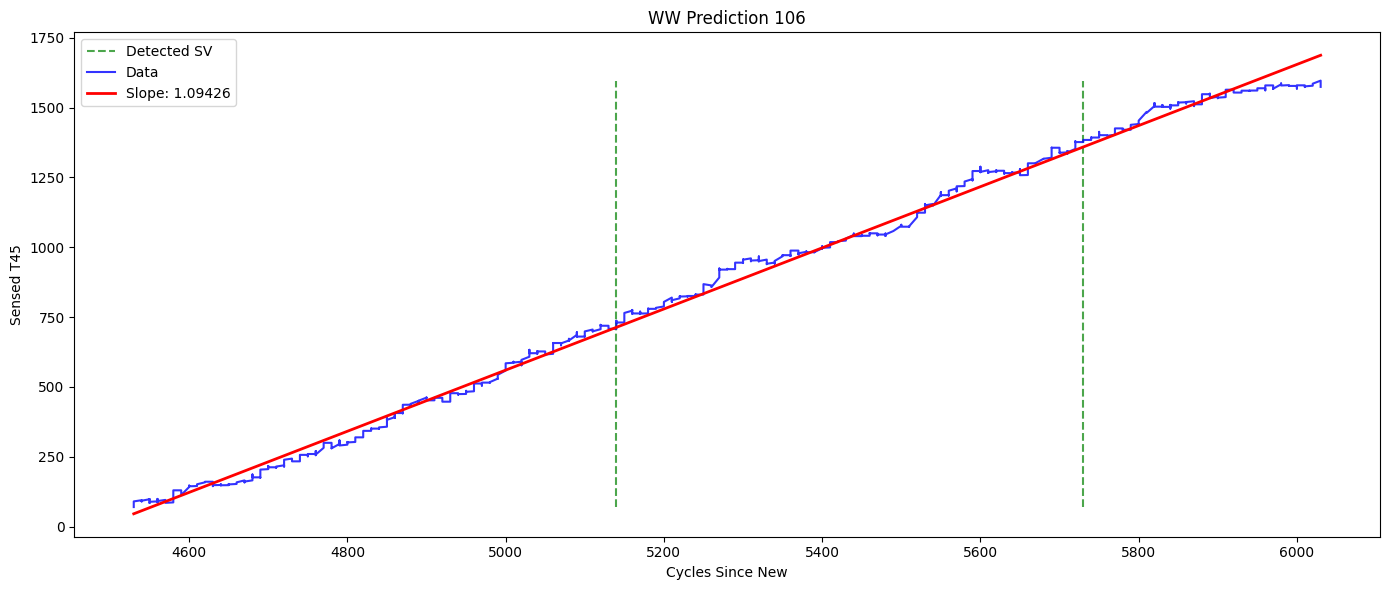

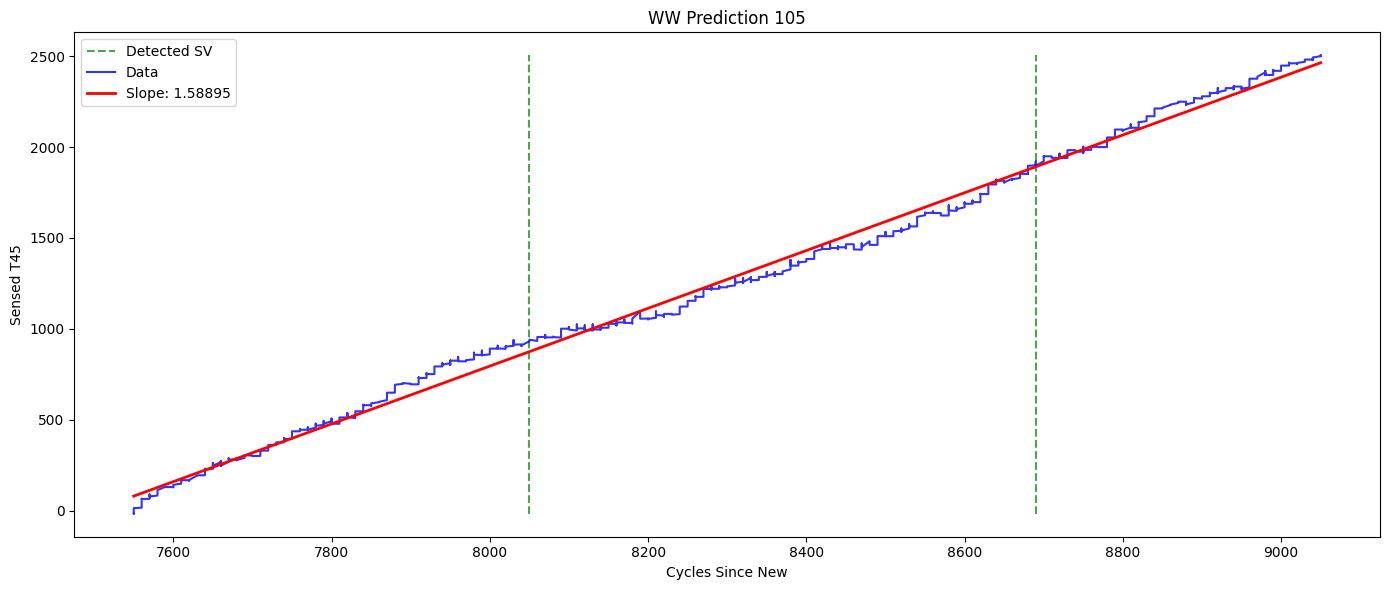

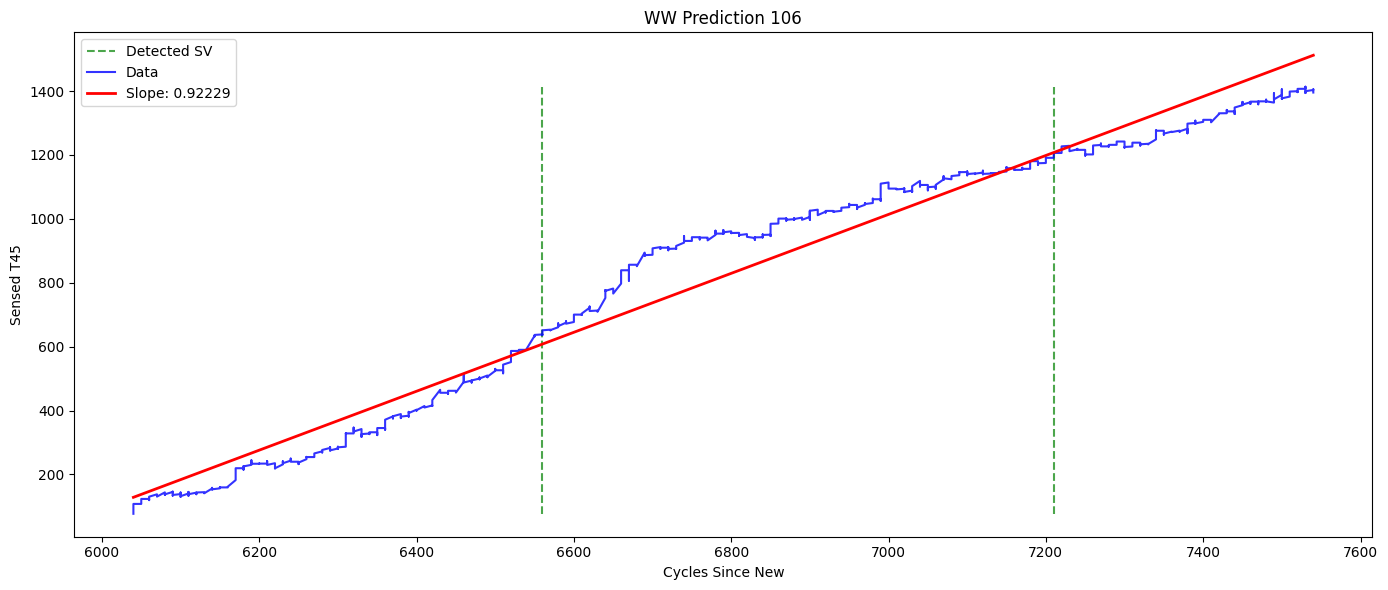

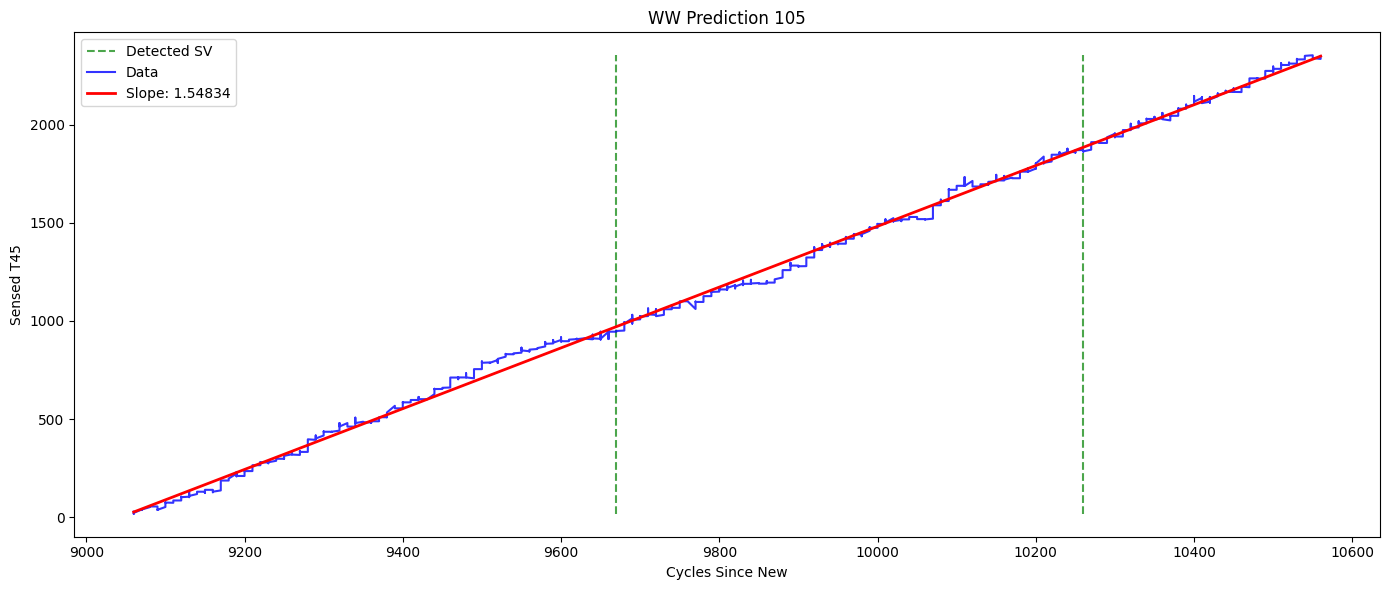

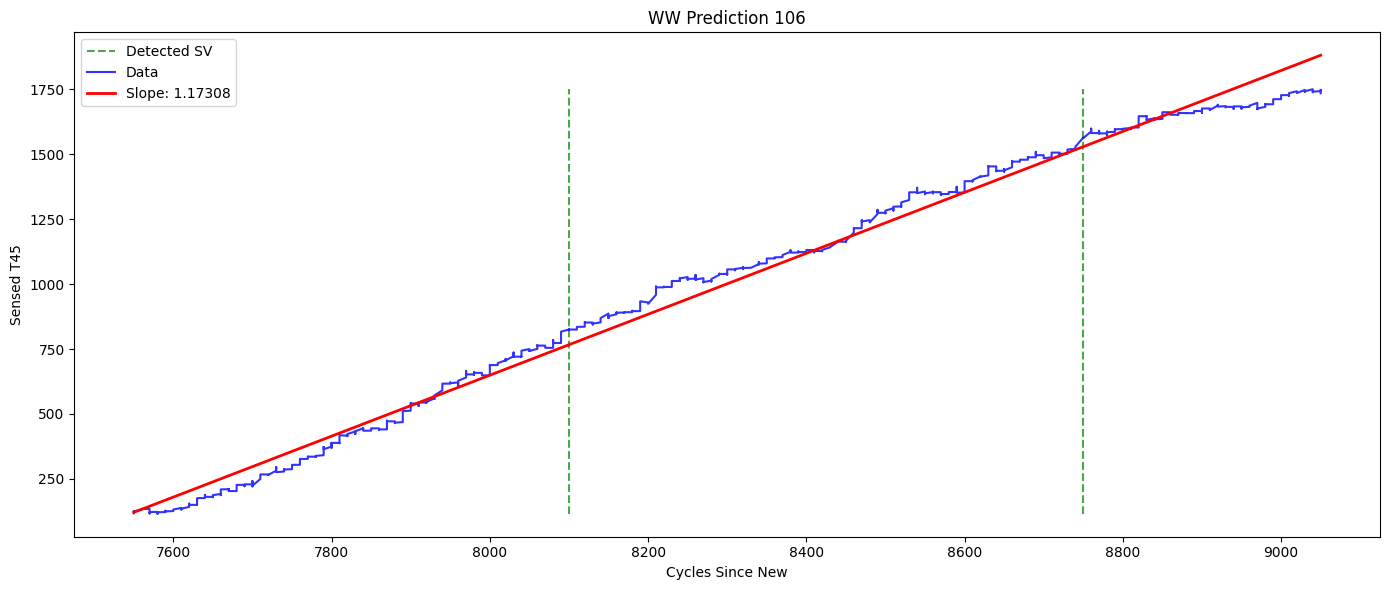

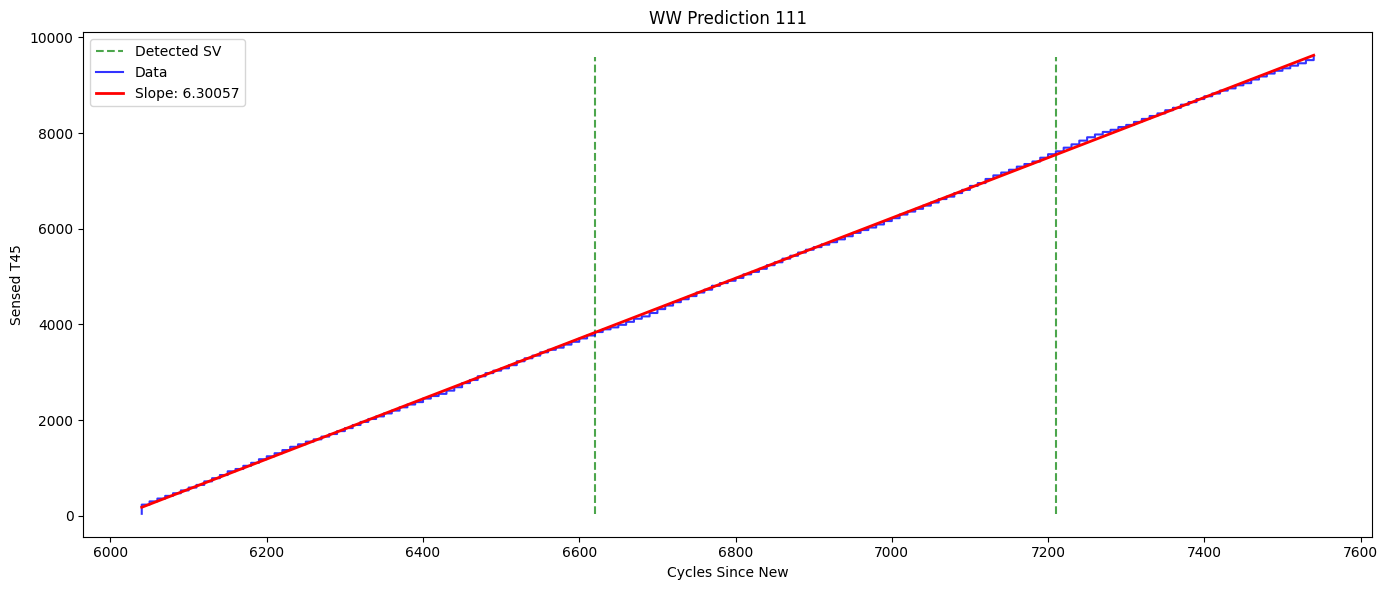

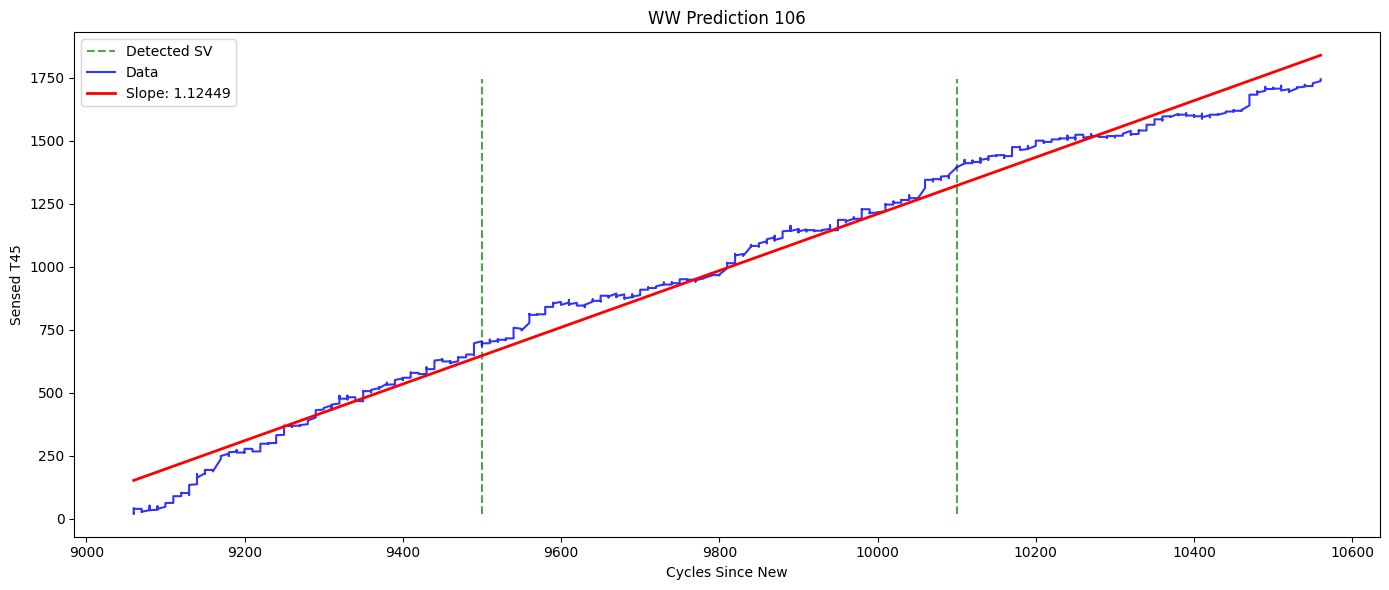

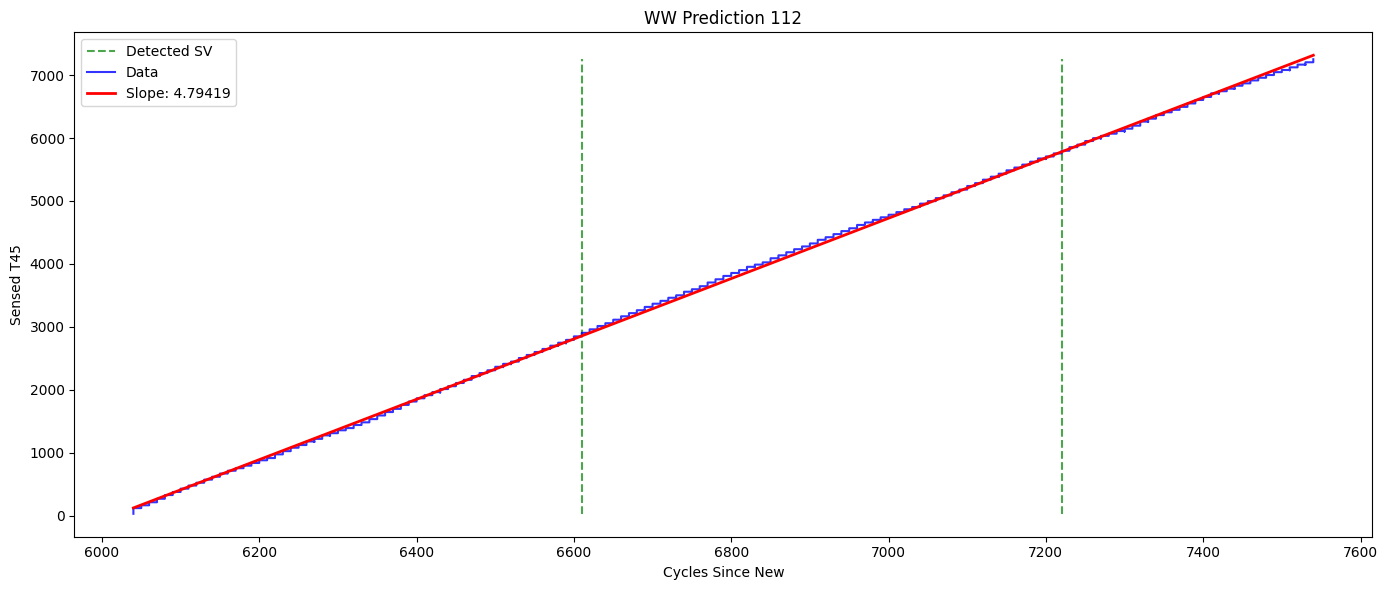

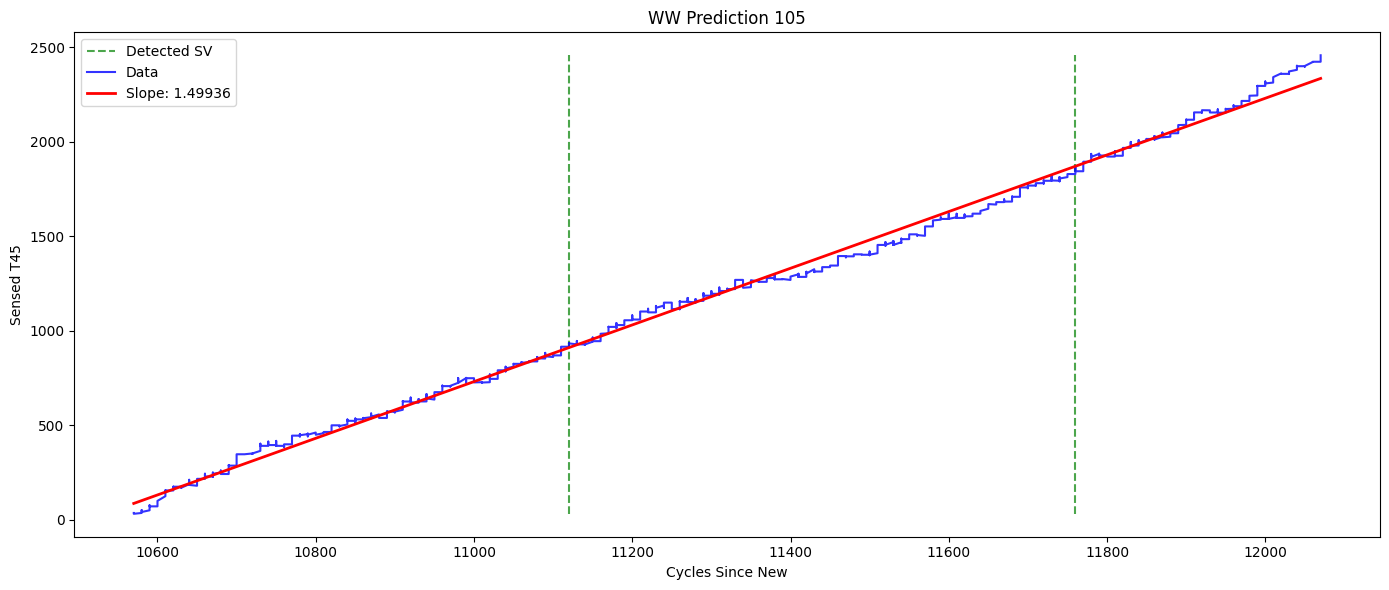

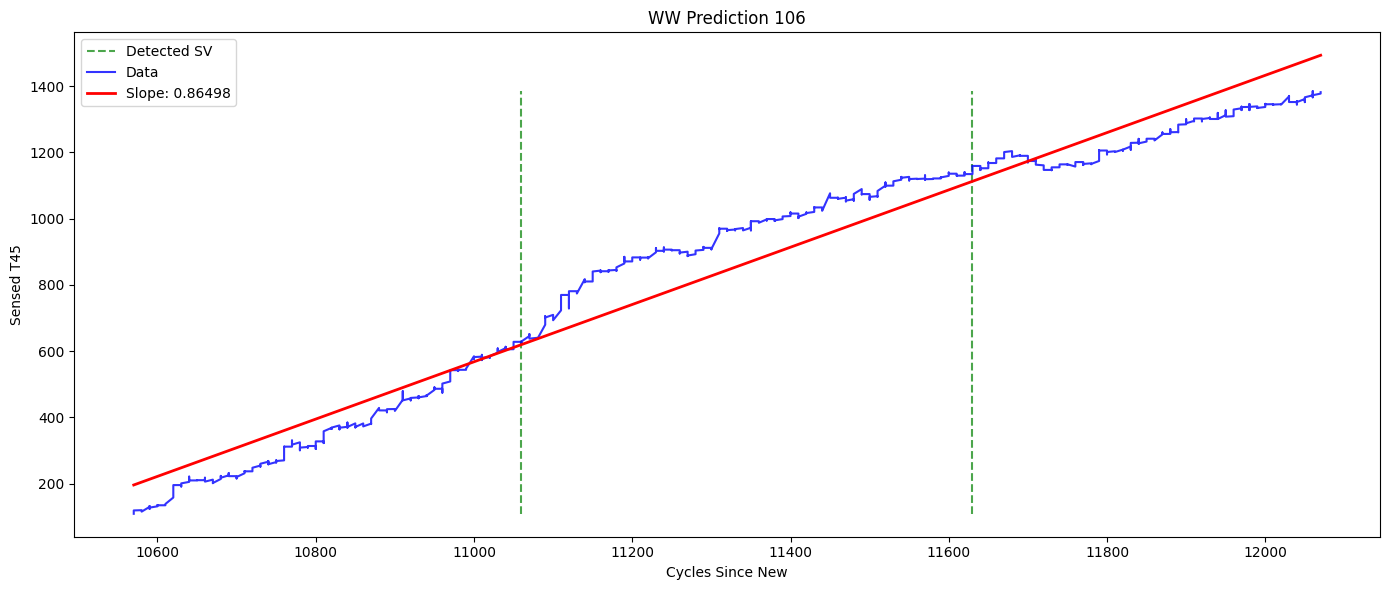

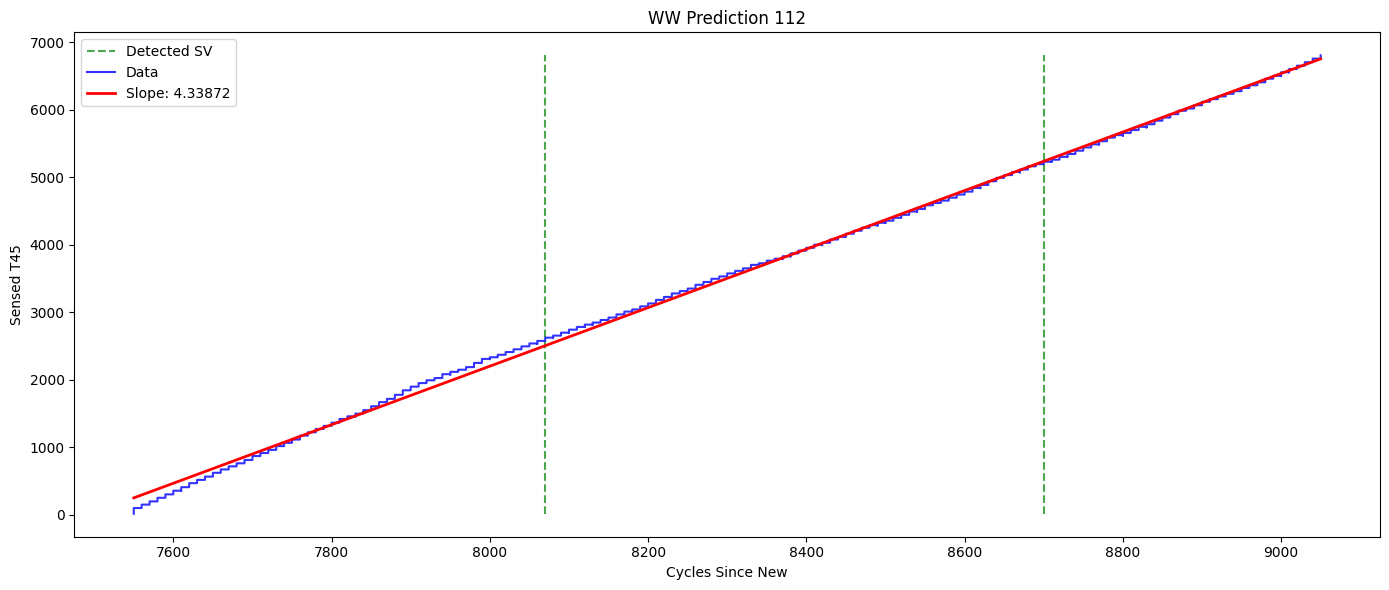

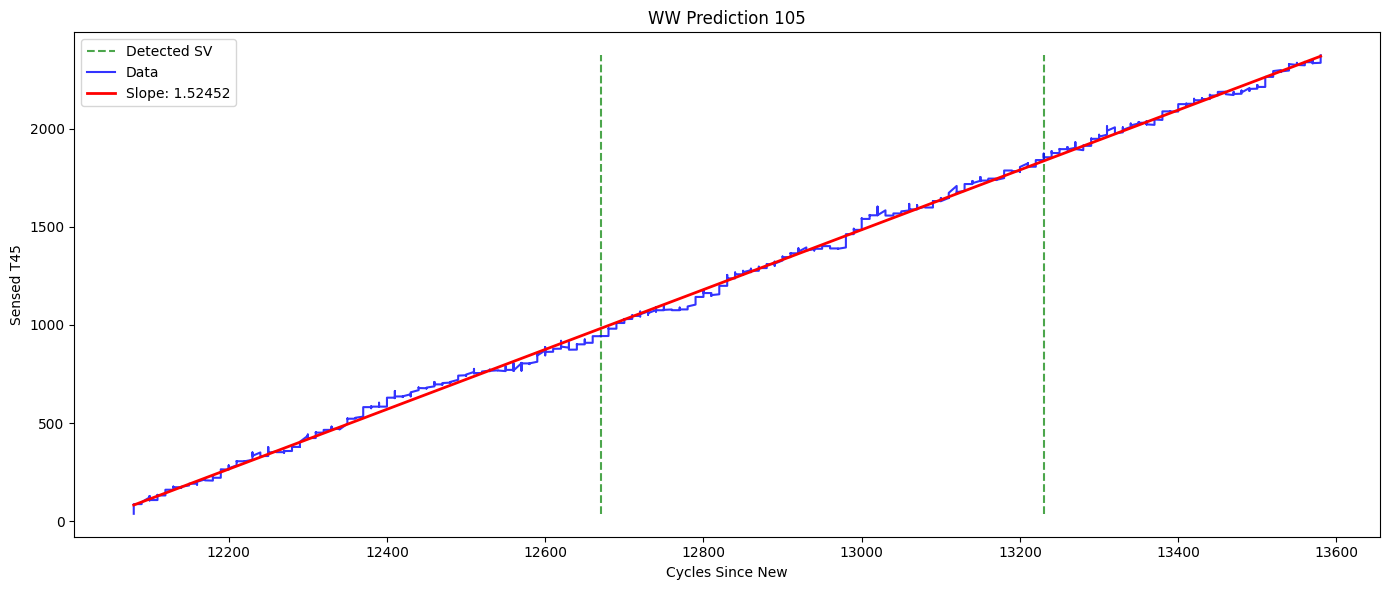

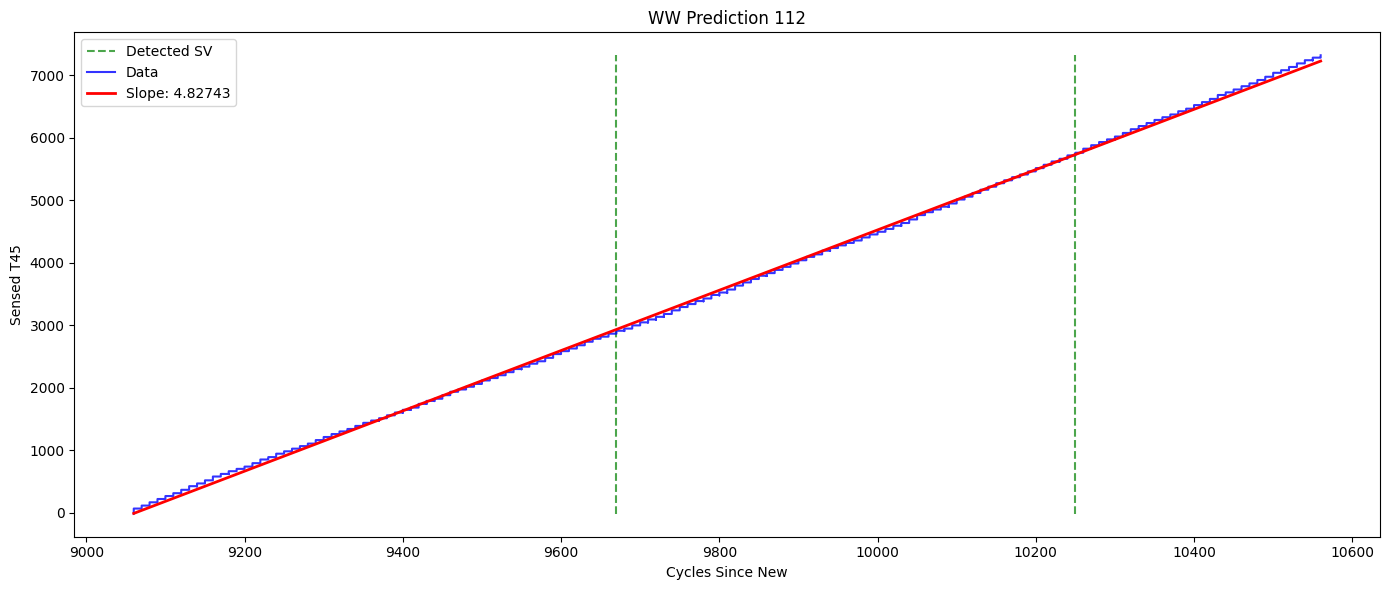

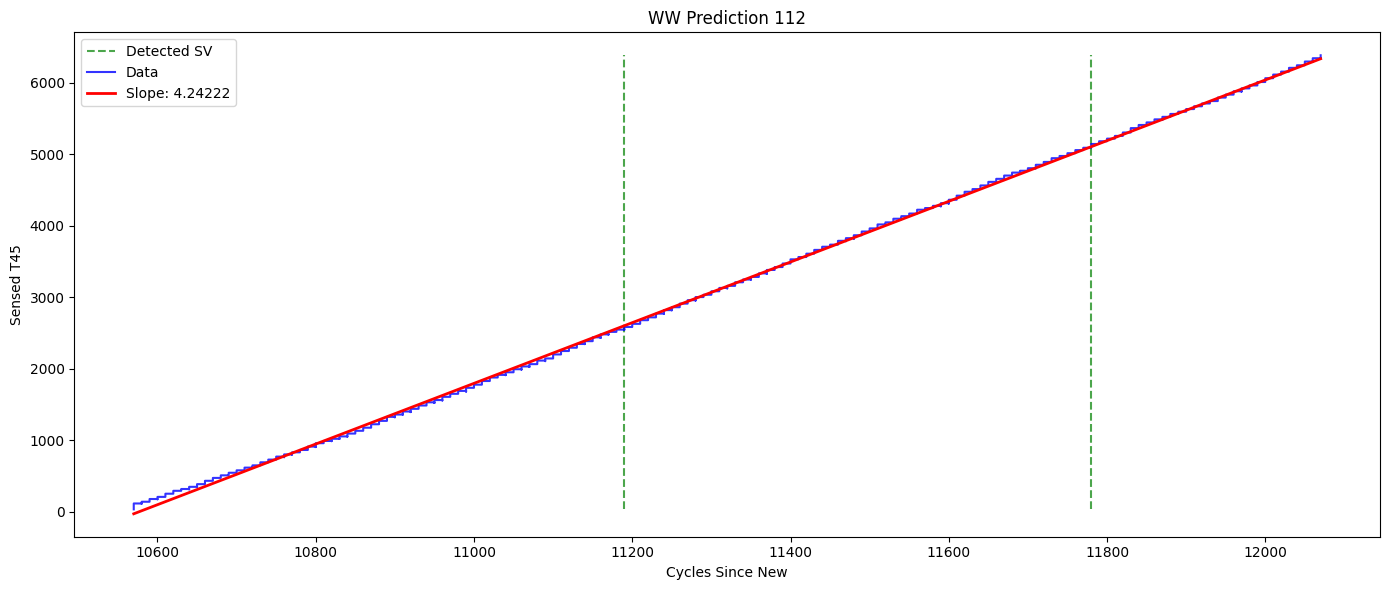

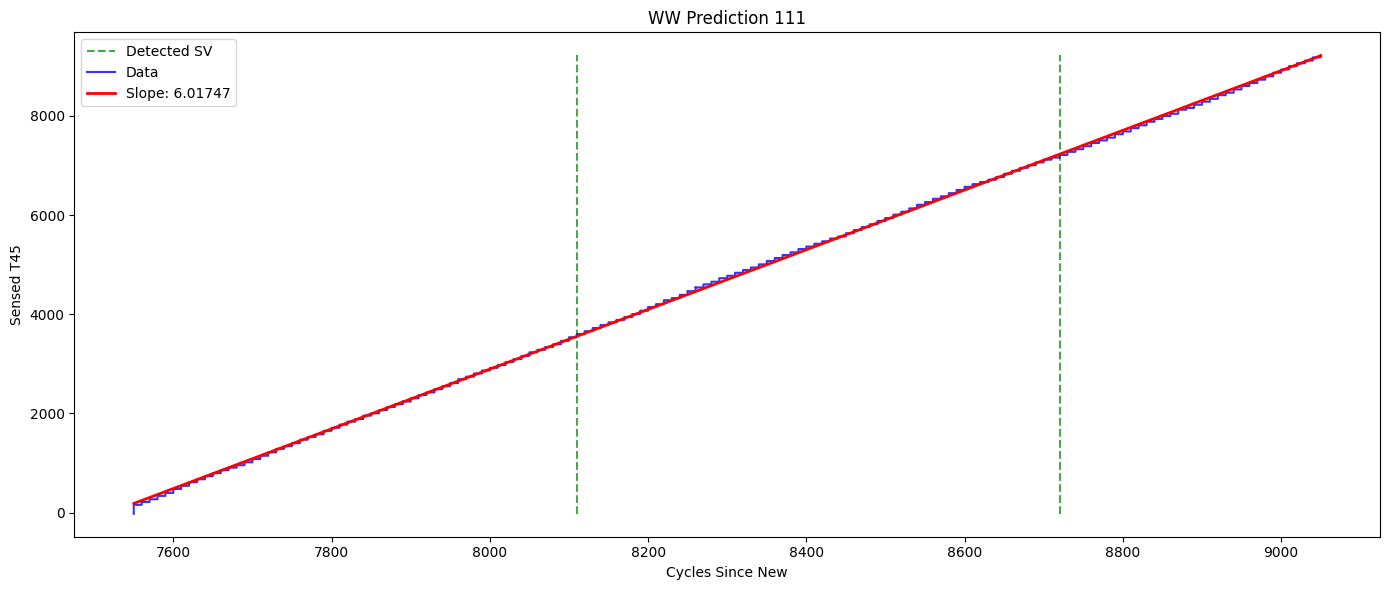

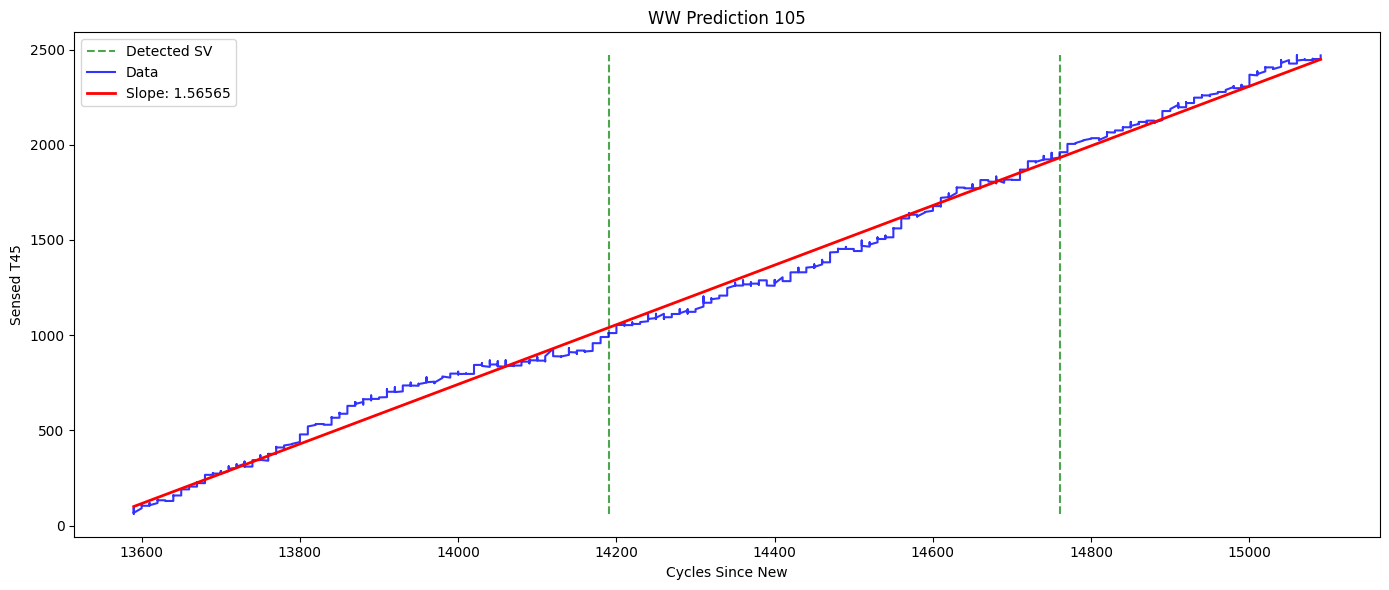

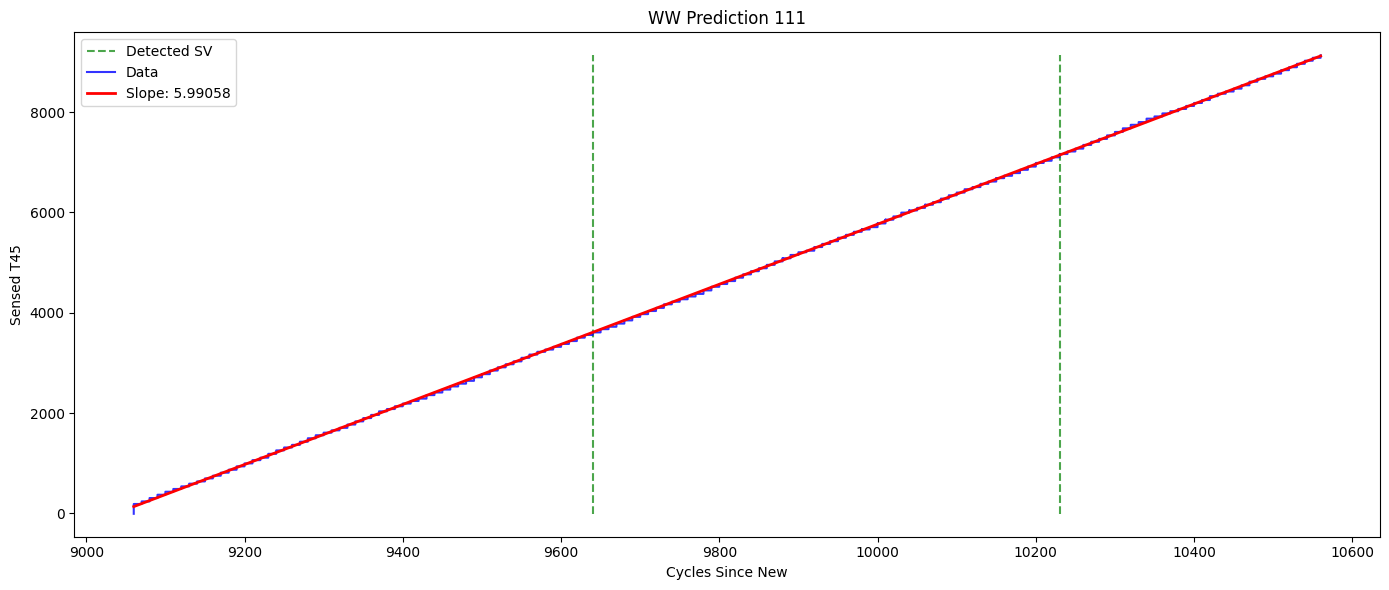

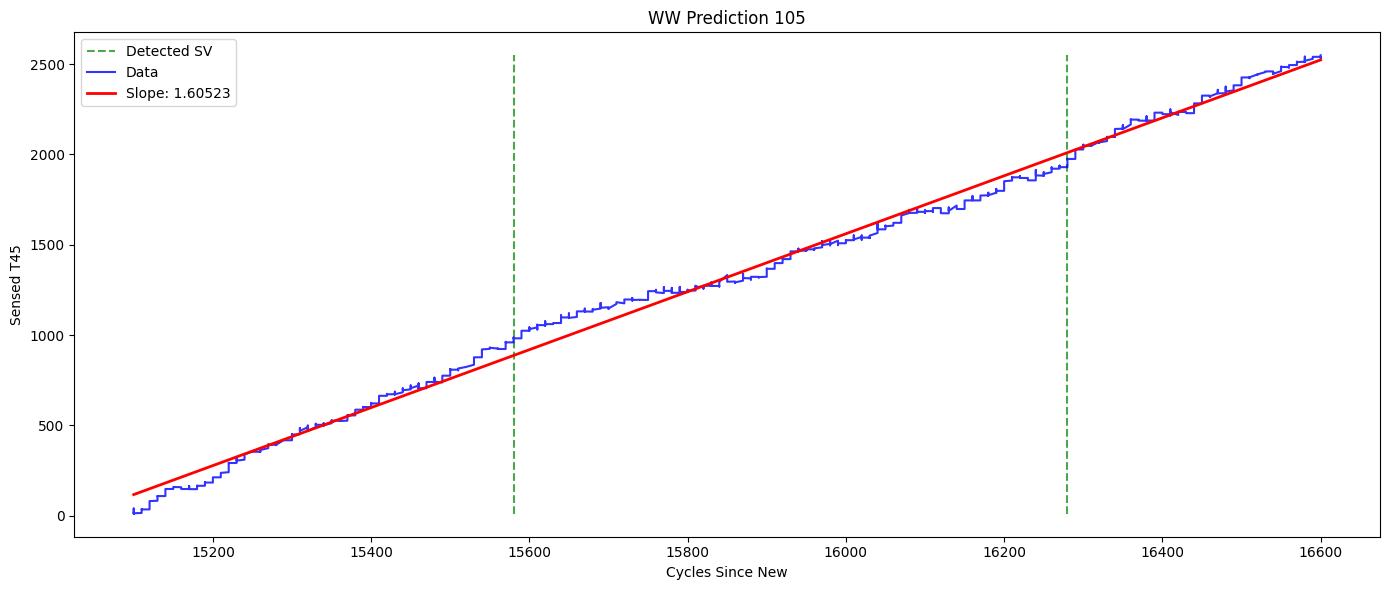

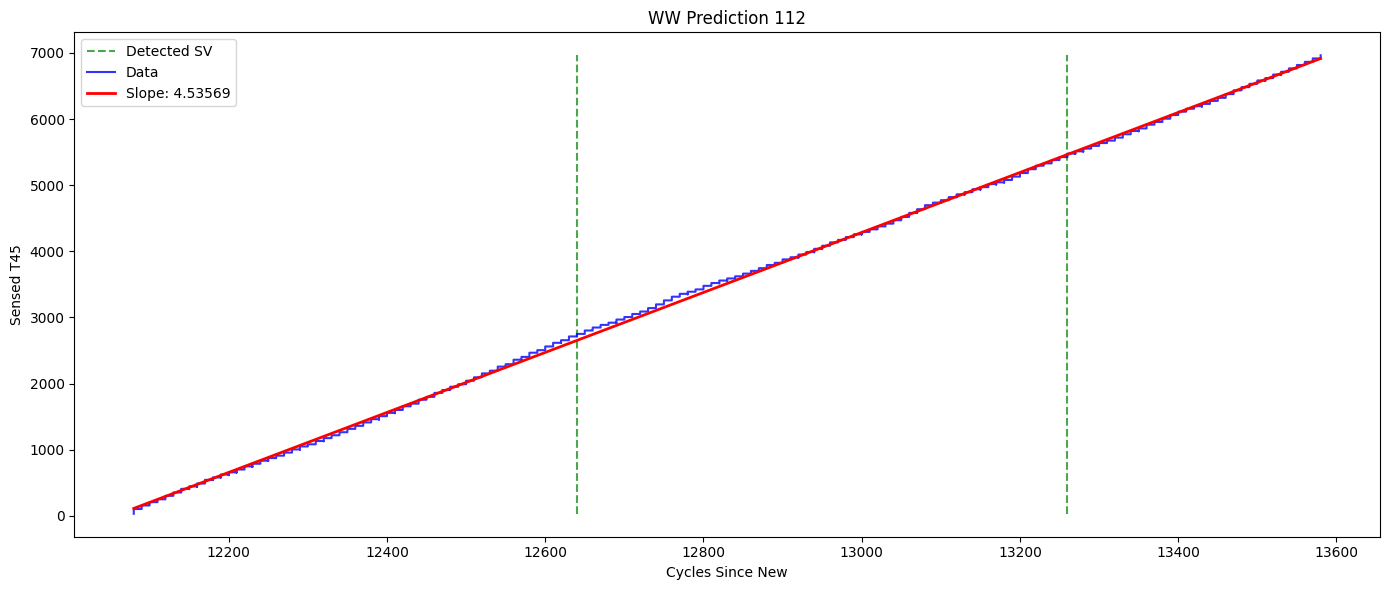

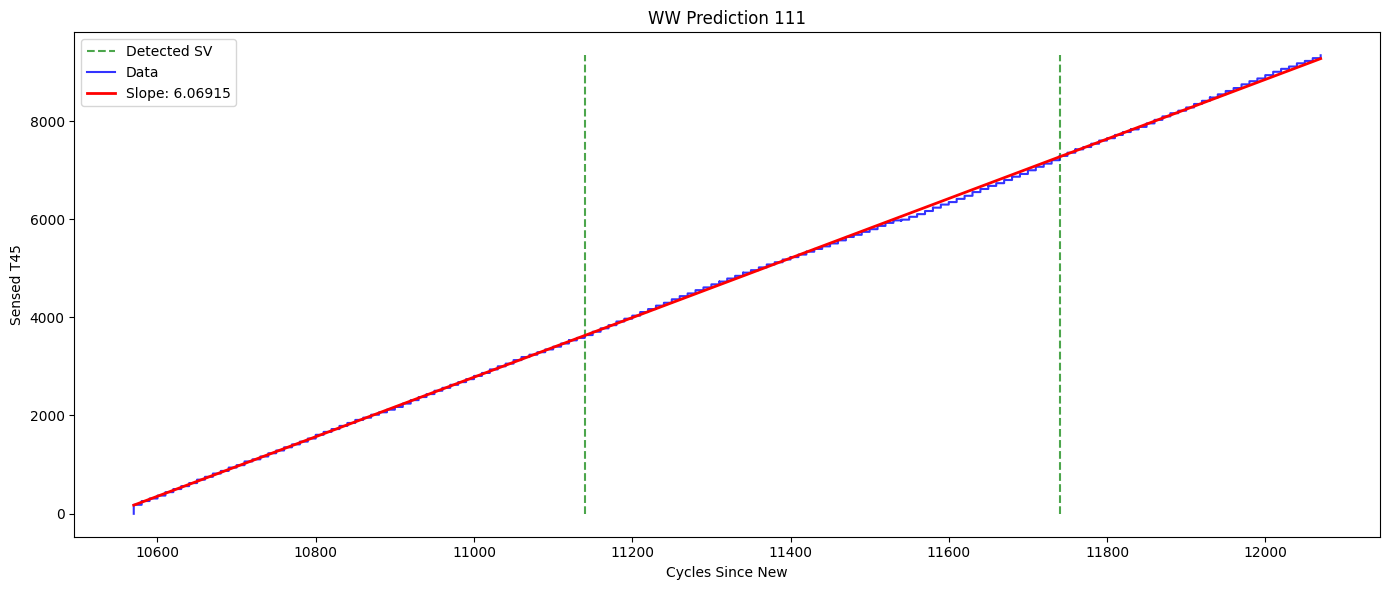

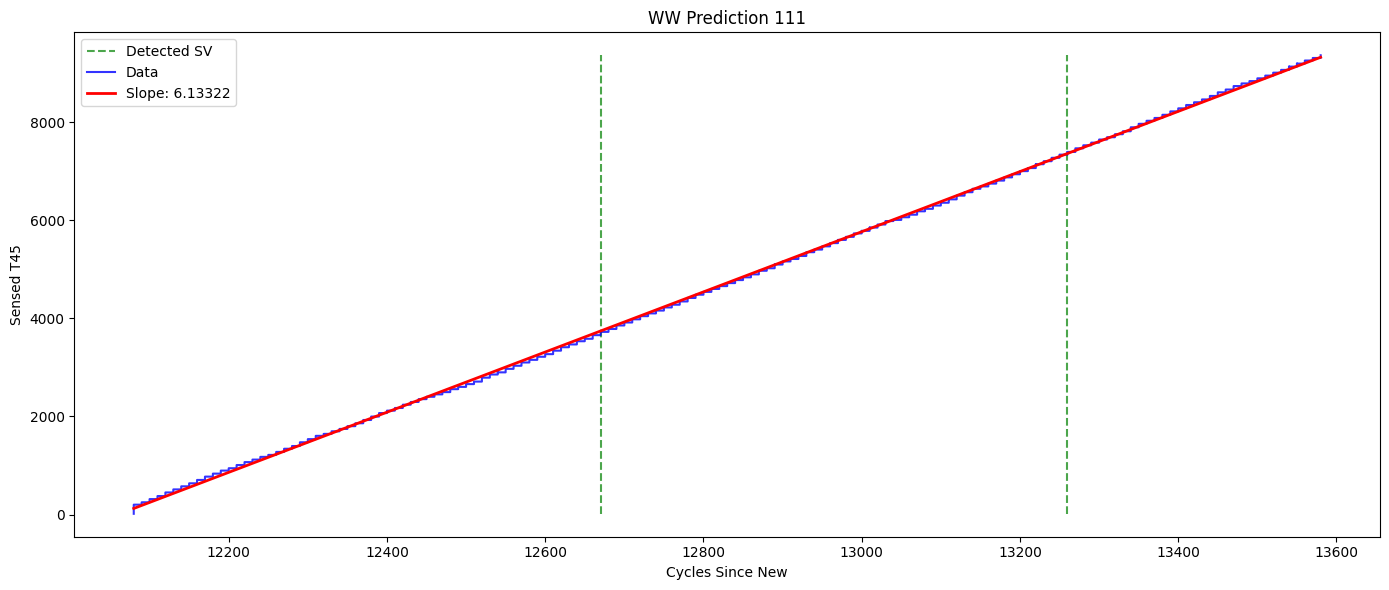

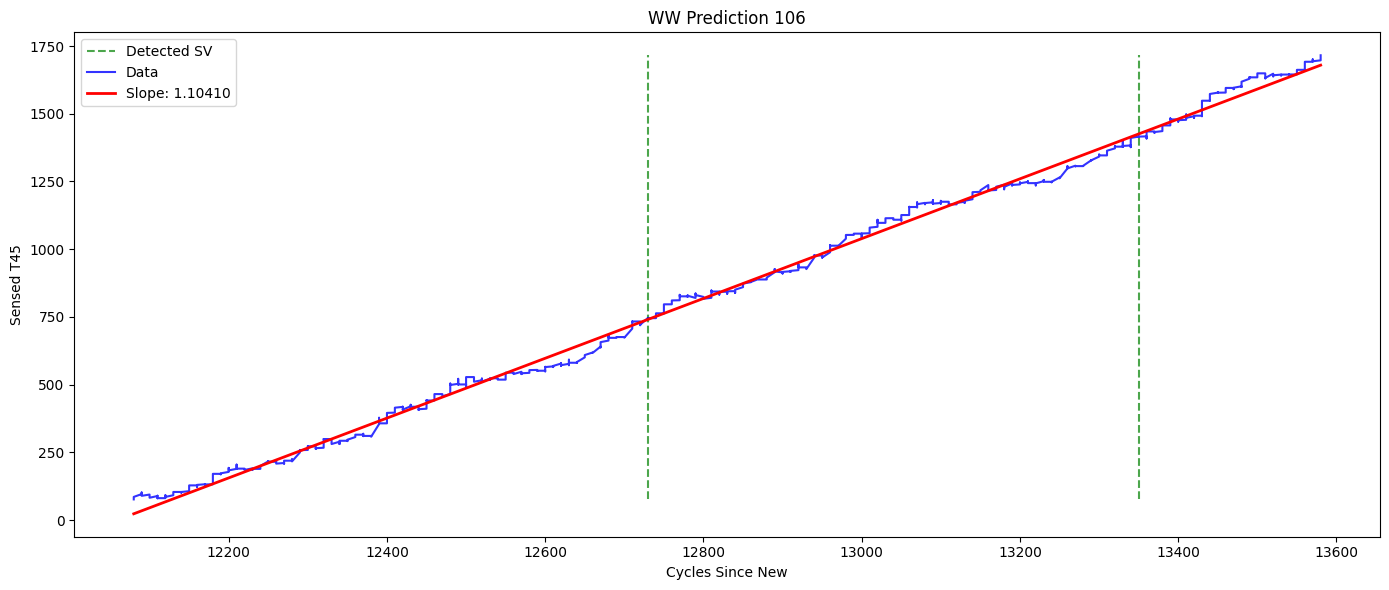

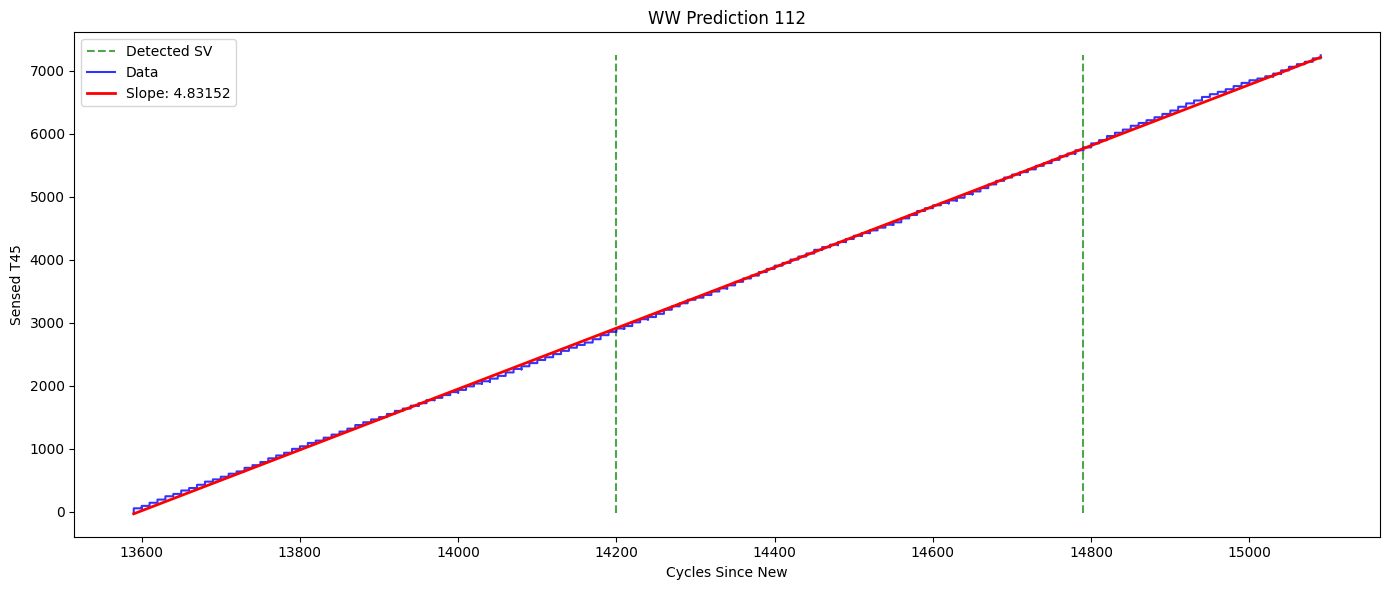

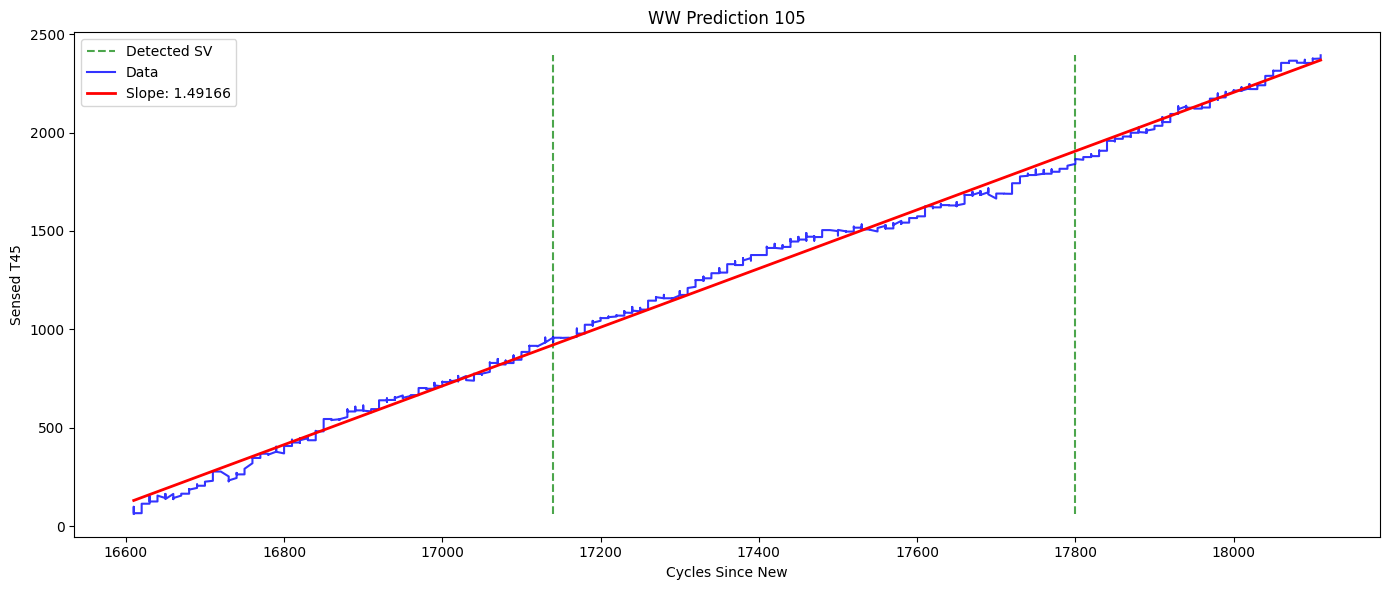

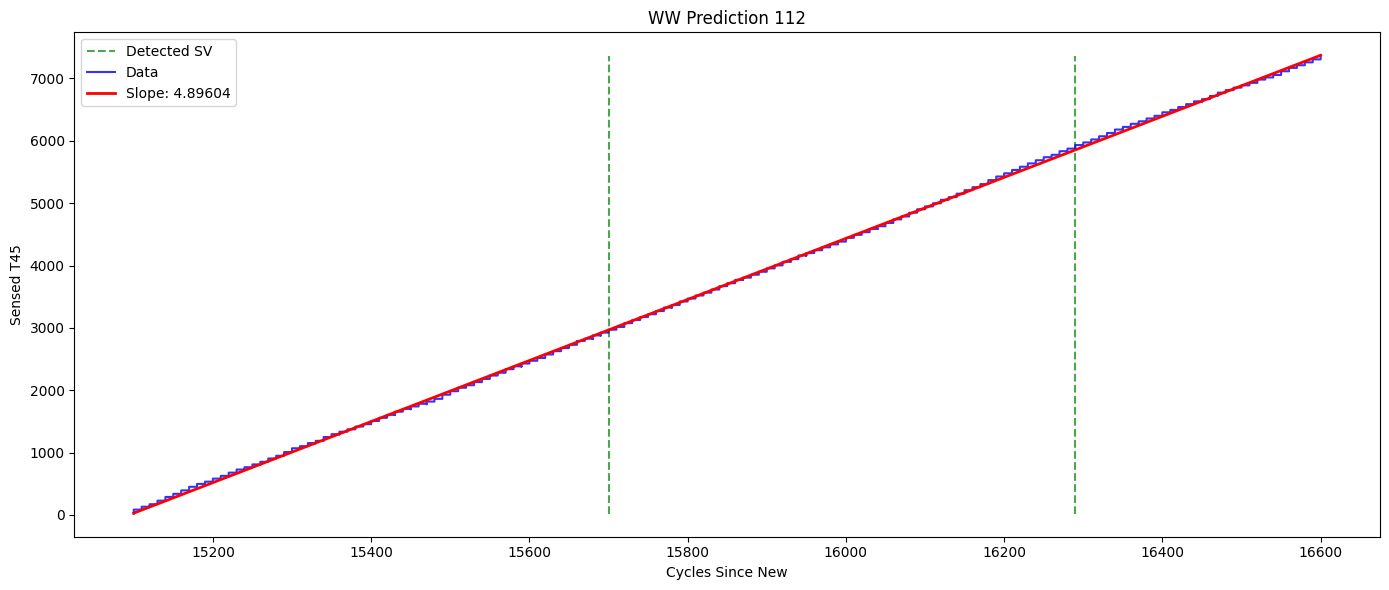

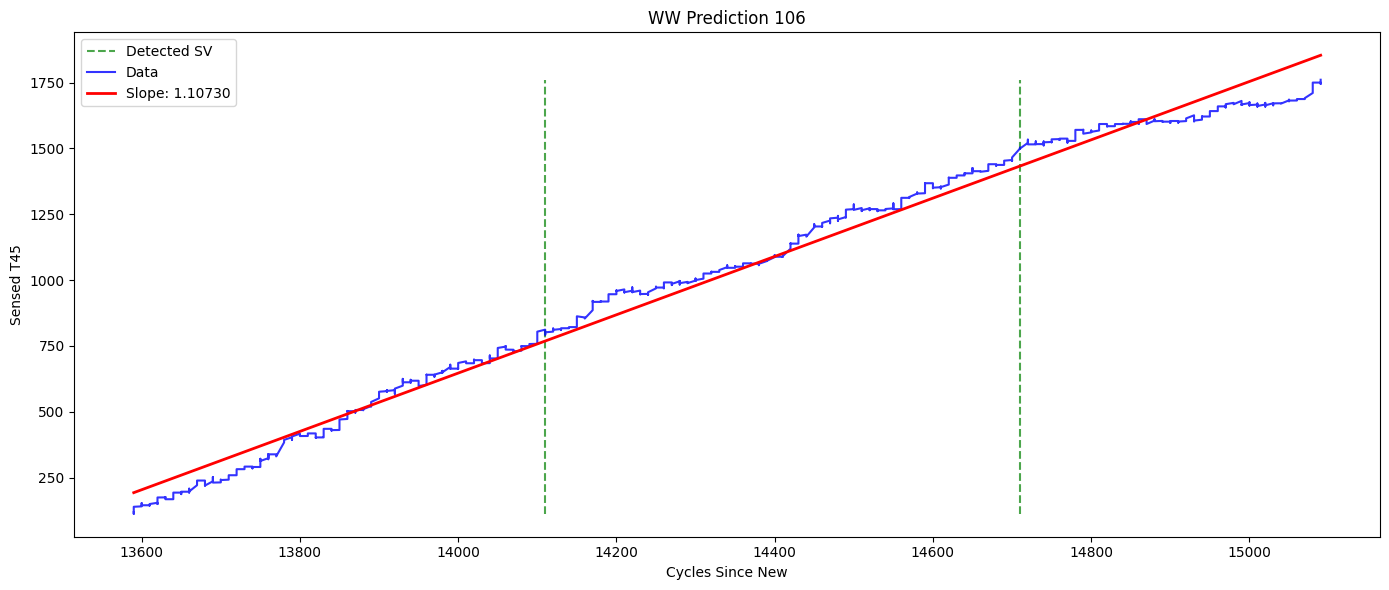

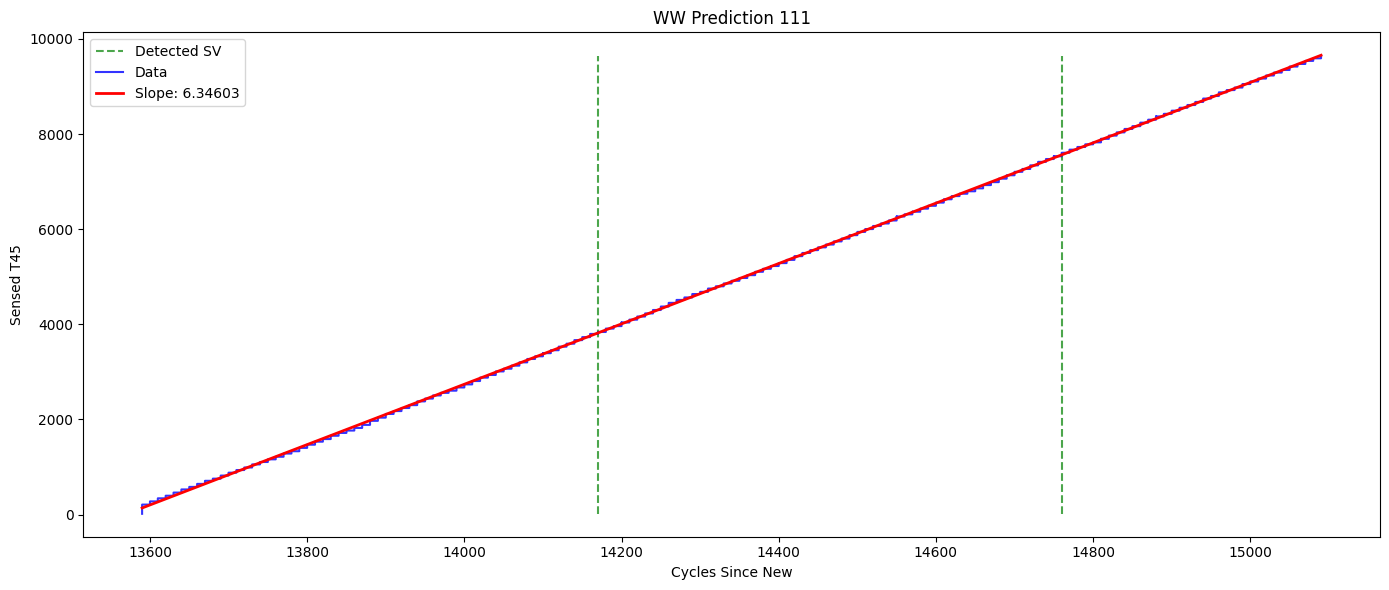

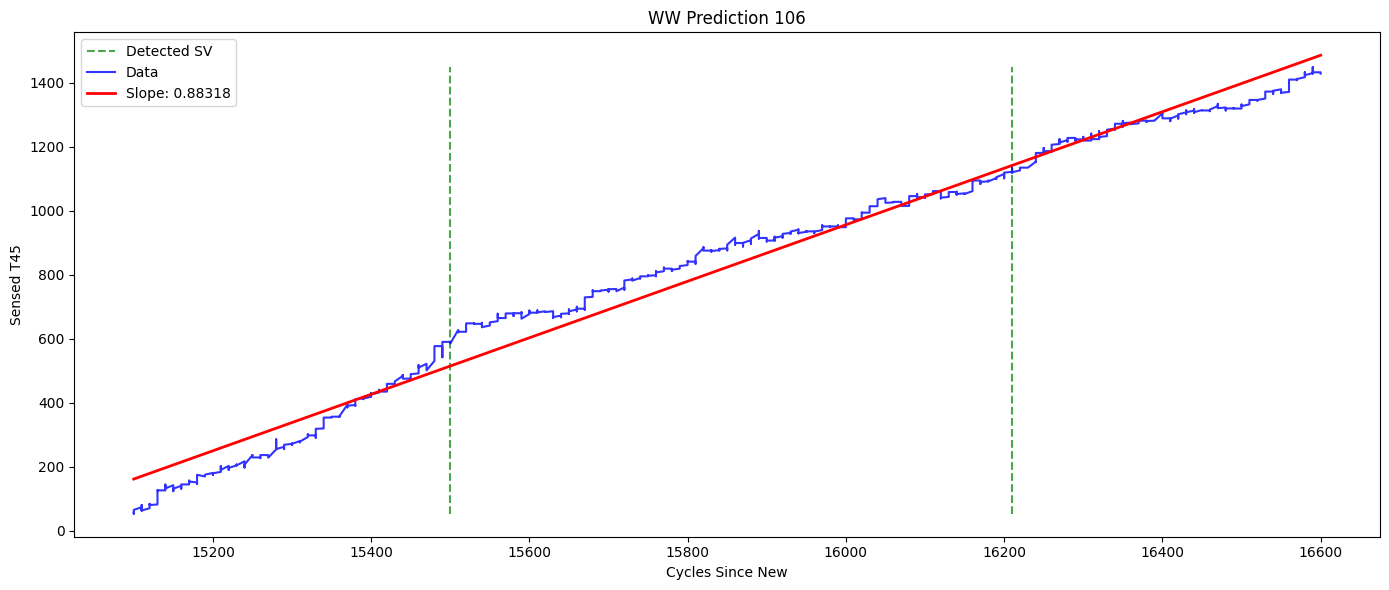

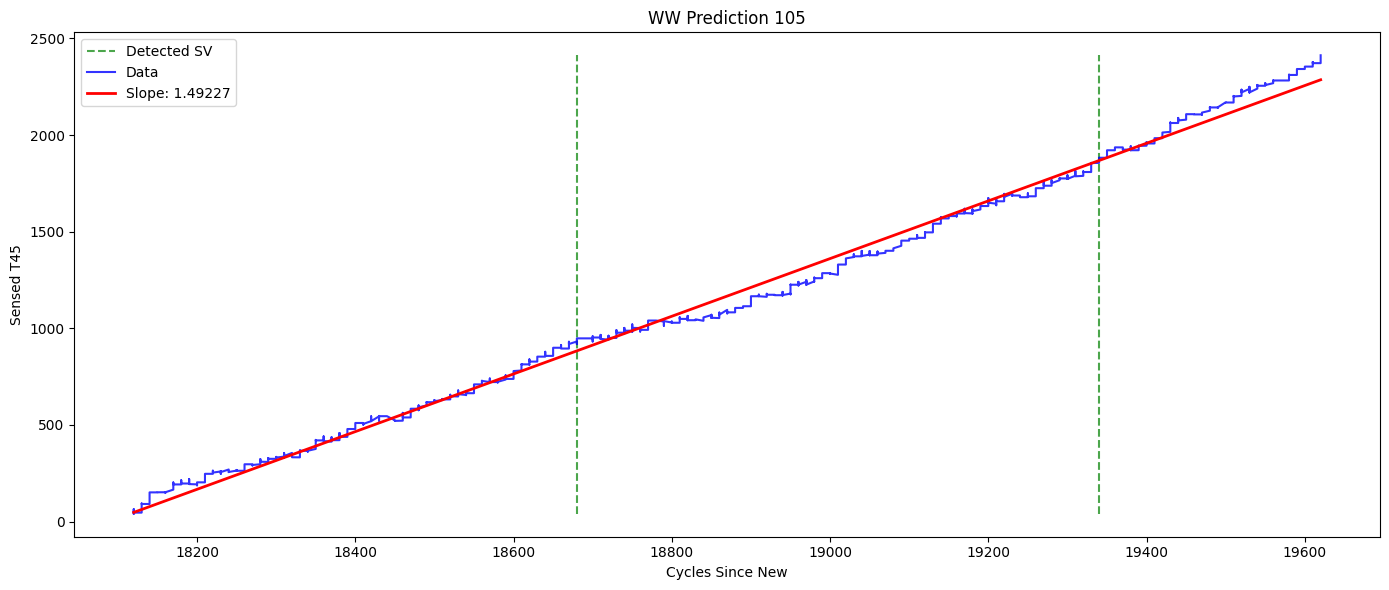

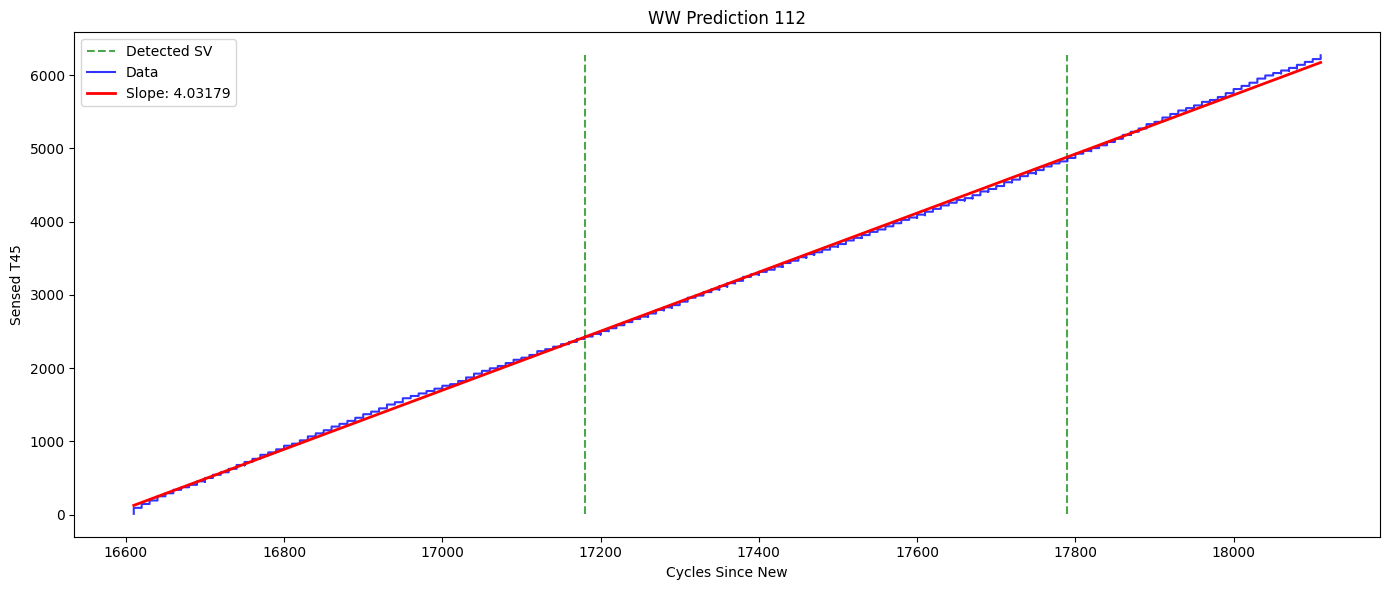

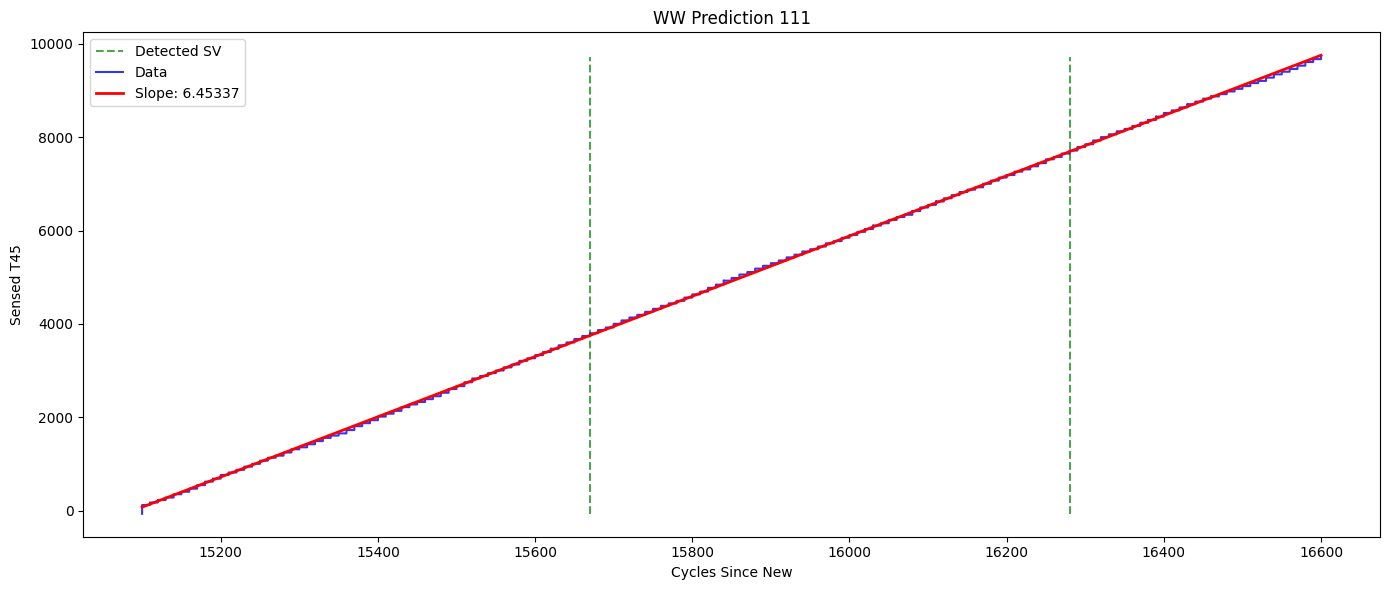

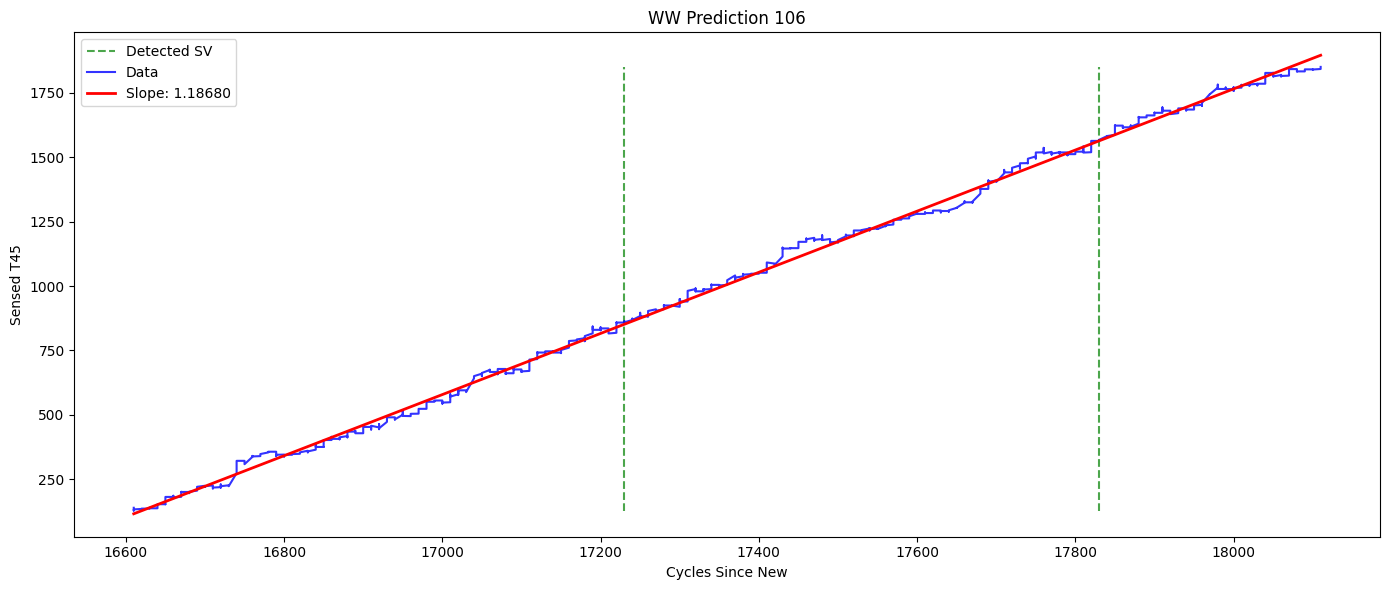

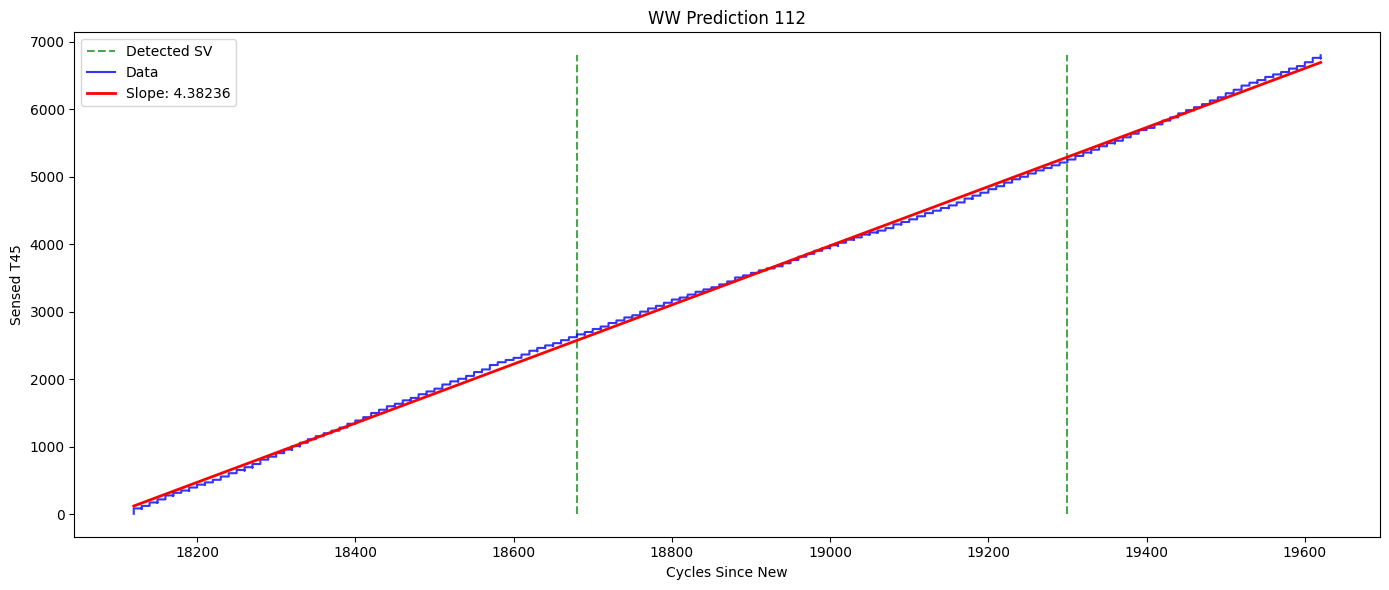

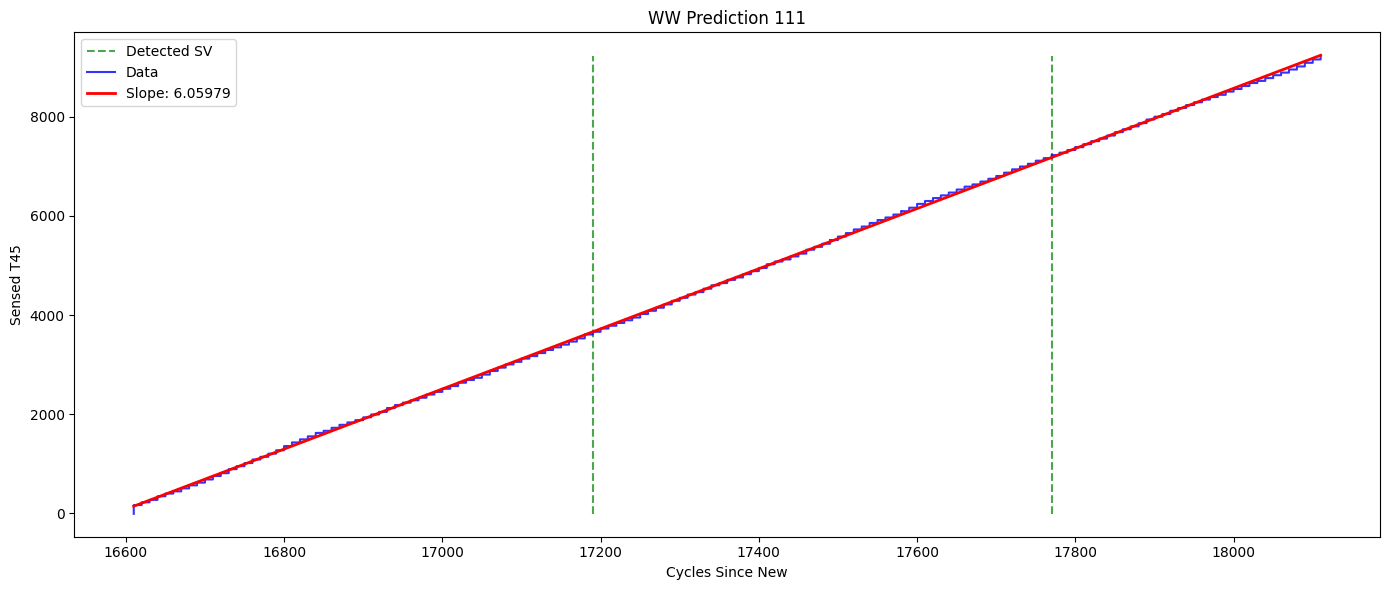

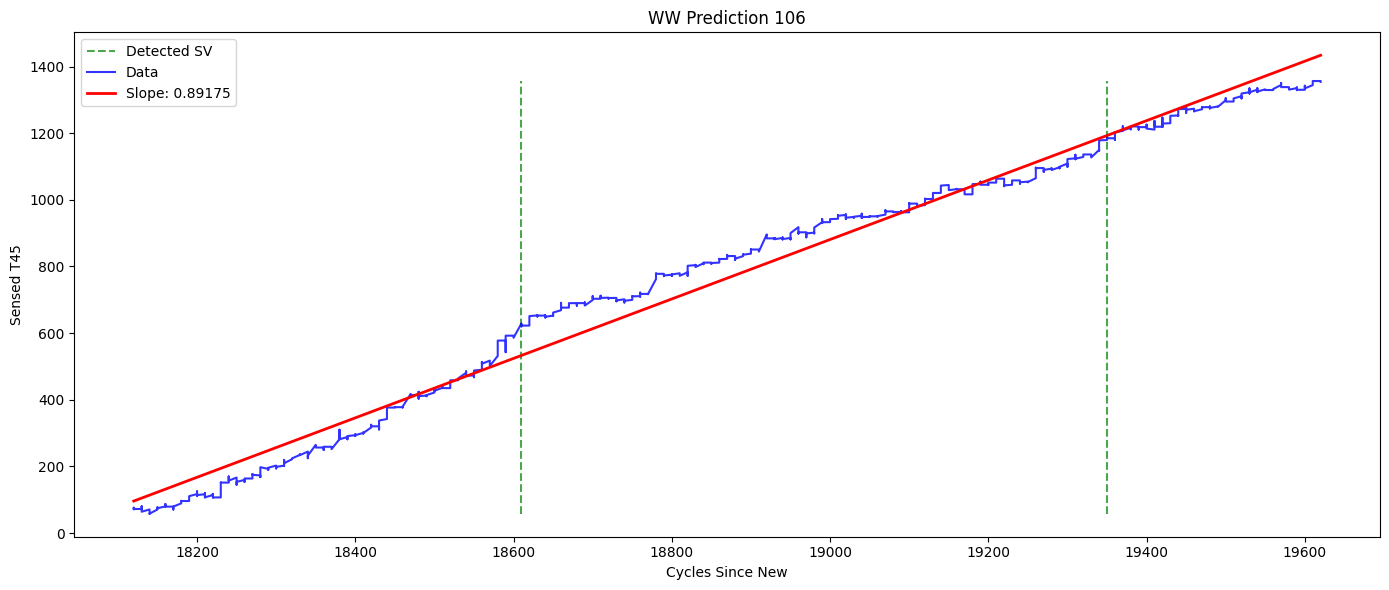

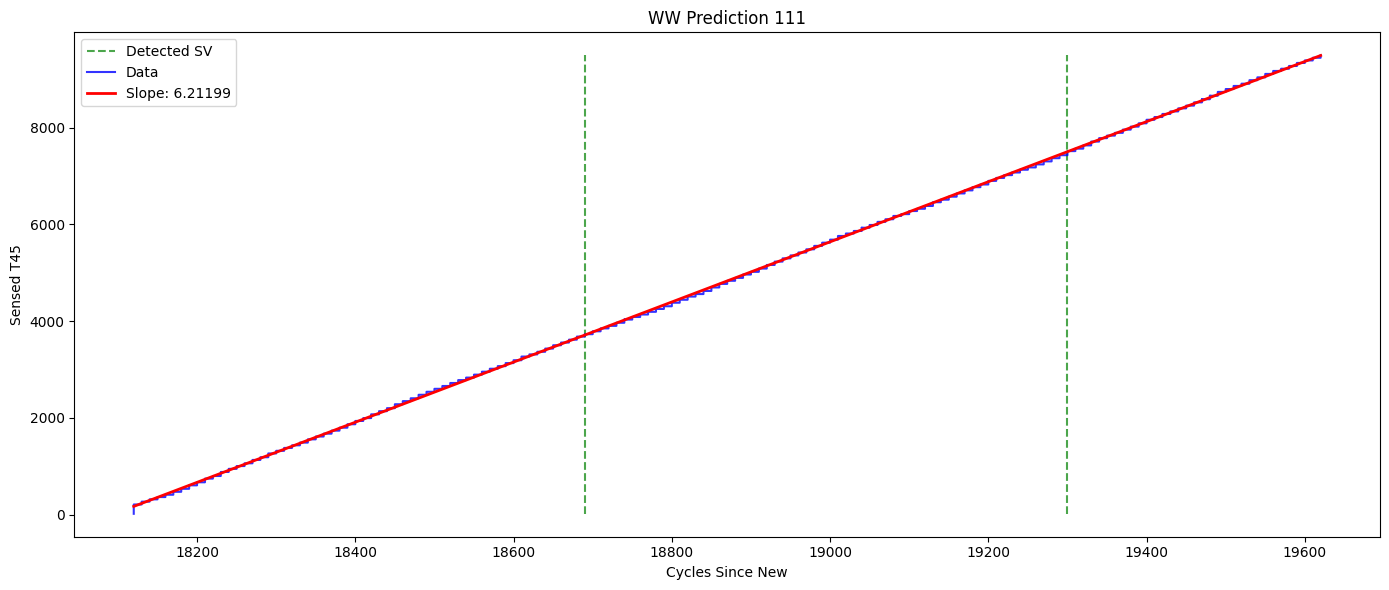

In [190]:

for v in dfv:
    for esn in v["ESN"].unique():
        plot_ww_slope(v[v["ESN"] == esn], residuals(v[v["ESN"] == esn]))

for f in dft:
    for esn in f["ESN"].unique():
        plot_ww_slope(f[f["ESN"] == esn], residuals(f[f["ESN"] == esn]))
